# CanSat Data Analysis - GRASP, VAMOS & ScamSat

Spectral and atmospheric time-series analysis of the GRASP–VAMOS–ScamSat CanSat mission (Dübendorf CH, 2026-02-05).

---
## 1. Introduction

### 1.1 Mission overview

Three CanSat probes (GRASP, VAMOS, ScamSat) were released from an aircraft at ~665 m AGL above Dübendorf, Switzerland (448 m ASL) on 2026-02-05.  Each probe descended on a parachute at ~3-4 m s⁻¹, sampling atmospheric variables during the fall.

Key platform characteristics that motivate the analysis strategy:

| Source of disturbance | Description | Affected sensors |
|----------------------|-------------|-----------------|
| **Pendulum oscillation** | CanSat swings below parachute (~0.1-1 Hz for 0.3-3 m line) | Wind, acceleration |
| **Axial spin** | Payload rotates around vertical axis | Wind direction |
| **Sensor warm-up** | NDIR CO₂ and pressure sensors produce spurious values at power-on | CO₂, pressure |
| **Thermal lag** | Temperature sensor equilibrates slowly after launch | Temperature |
| **Timestamp resets** | Microcontroller restarts create repeated time axes | VAMOS science, VAMOS wind |

### 1.2 Research question

> *How do temperature, pressure, particulate matter (PM₂.₅/PM₁₀), CO₂, and wind vary with altitude and time during the CanSat descent, and how can spectral analysis help distinguish atmospheric structure from sensor noise and oscillatory descent dynamics?*

### 1.3 Methods overview

The notebook follows a staged workflow, moving from raw telemetry checks to descent-window signal processing and finally to atmospheric interpretation.

1. **Data loading and cleaning** (§2): all payloads are loaded through the shared utilities, then inspected in near-raw form. Mandatory corrections are limited to known acquisition artefacts: GRASP row-0 pressure spike removal, VAMOS timestamp-reset handling, VAMOS CO₂ warm-up exclusion, and ignoring the stuck VAMOS tumbling flag in favour of acceleration and wind-direction diagnostics.

2. **Dataset suitability assessment** (§2): each dataset is evaluated for duration, sampling density, channel completeness, and physical plausibility. VAMOS science, VAMOS wind and ScamSat provide the spectral analysis windows; GRASP is retained for short descent/profile context, while OBAMA is retained only as a sparse independent CanSat cross-check.

3. **Alignment and descent detection** (§3): the VAMOS descent window is detected from the pressure-derived altitude profile, from apogee to return near ground level. ScamSat uses its own altitude trace. These windows define the intervals used for spectral analysis and final descent-only profile plots.

4. **Spectral analysis** (§4): spectra are computed only for descent windows long and dense enough to support them, mainly VAMOS science, VAMOS wind and ScamSat.

| Stage | Operation | Purpose |
|-------|-----------|---------|
| 1 | Descent-window selection | Restrict spectra to apogee-to-landing dynamics |
| 2 | Uniform resampling | Put each signal on a constant sampling grid |
| 3 | Linear detrending | Remove the dominant atmospheric/descent trend |
| 4 | Hann FFT and Welch PSD | Estimate dominant resolved frequencies |
| 5 | STFT spectrogram | Check whether spectral content is persistent or transient |

The frequency-domain analysis uses raw resampled residuals after linear detrending. Low-pass filtering is reserved for atmospheric/profile visualisation; it is not applied before peak detection because a low cut-off could erase the parachute pendulum band being tested.

5. **Final signal products** (§4.4 and §6): retained channels are converted into cleaned descent profiles versus altitude or pressure. This includes temperature, pressure, PM₂.₅, PM₁₀, CO₂, wind speed/direction, acceleration and available auxiliary channels, with pressure used as the common vertical coordinate where possible.

6. **Atmospheric interpretation and external comparison** (§5-§7): the cleaned CanSat profiles are interpreted against ISA expectations, WHO particulate-matter guideline levels and CO₂ background values, then placed alongside MeteoSwiss station/tower data, ERA5 reanalysis and the Payerne radiosonde where comparable variables are available. Wind is additionally represented through speed-altitude/pressure plots, compass-rose style diagnostics and hodographs.

### 1.4 Expected results

| Variable | Expected observation | Physical reasoning |
|----------|---------------------|-------------------|
| Temperature lapse rate | Sub-standard (less negative than -6.5 K km⁻¹), possibly inverted | Stable winter boundary layer over a continental site |
| PM near ground | Elevated PM₂.₅/PM₁₀, possibly above WHO limits | Aerosol accumulation in the stable boundary layer |
| CO₂ | Above global background (420 ppm) | Local anthropogenic emissions (traffic, combustion) |

---


In [52]:
# ── 0. Environment setup ─────────────────────────────────────────────────────
import sys
from pathlib import Path

_IN_COLAB = 'google.colab' in sys.modules
if _IN_COLAB and not Path('utils.py').exists():
    import urllib.request
    _URL = ('https://raw.githubusercontent.com/demartinomattia/Space_Data_2/main/utils.py')
    urllib.request.urlretrieve(_URL, 'utils.py')

import importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram as _scipy_spectrogram
warnings.filterwarnings('ignore')

import utils; importlib.reload(utils)
from utils import (
    apply_plot_style, save_figure,
    isa_alt, isa_temp_c, isa_press, baro_altitude_agl,
    load_grasp, load_vamos_science, load_vamos_wind,
    load_obama, load_uwyo_sounding, load_scamsat_bundle,
    resample_uniform, butter_lowpass, detrend_linear, compute_welch_psd,
    met_to_uv, apparent_yaw_from_wind_direction,
    detect_vamos_drop, print_dataset_summary,
    P0, T0_K, L, G, RD,
    WHO_PM25_24H, WHO_PM10_24H, CO2_BACKGROUND_PPM,
    FIG_DIR, DATA_DIR,
)
apply_plot_style()
print(f'utils {utils.__version__}')


utils 2.4.1


In [53]:
# ── Data loading ─────────────────────────────────────────────────────────────
grasp_raw = load_grasp()
vamos     = load_vamos_science()
wind      = load_vamos_wind()
obama     = load_obama()
uwyo      = load_uwyo_sounding()
scamsat   = load_scamsat_bundle()

scam_alt   = scamsat['altitude']
scam_press = scamsat['pressure']
scam_temp  = scamsat['temperature']
scam_pm25  = scamsat['pm25']
scam_pm10  = scamsat['pm10']
scam_accel = scamsat['acceleration']
scam_fft   = scamsat['fft']
print('All datasets loaded.')


All datasets loaded.


In [54]:
# ── Post-load derivations ────────────────────────────────────────────────────
grasp_clean = grasp_raw.iloc[1:].copy().reset_index(drop=True)
grasp_clean['alt_baro'] = isa_alt(grasp_clean['press_Pa'].values)

vamos_co2  = vamos[vamos['co2_ppm'] > 0].copy()
vamos_drop = detect_vamos_drop(vamos)
drop_mask  = vamos_drop['drop_mask']

wind['wind_dir_unwrapped'], wind['yaw_rate_deg_s'] = apparent_yaw_from_wind_direction(
    wind['t_rel'].values, wind['wind_dir'].values, smooth_window=5
)
wind['spin_rate_hz'] = wind['yaw_rate_deg_s'] / 360.0

# Window around the flight: airborne interval ± 10 min
_h_agl    = vamos_drop['h_agl']
_airborne = np.where(_h_agl > 30)[0]
if len(_airborne):
    _t_win0 = max(vamos['t_s'].values[_airborne[0]]  - 600, vamos['t_s'].iat[0])
    _t_win1 = min(vamos['t_s'].values[_airborne[-1]] + 600, vamos['t_s'].iat[-1])
else:
    _t_win0, _t_win1 = vamos['t_s'].iat[0], vamos['t_s'].iat[-1]

vamos_conc = vamos[vamos['t_s'].between(_t_win0 - 30, _t_win1 + 30)].copy()

FS_G = float(round(1000.0 / np.median(np.diff(grasp_raw['t_ms'].values))))
FS_V_NATIVE = 1.0 / np.median(np.diff(vamos['t_rel'].values))
FS_W_NATIVE = 1.0 / np.median(np.diff(wind['t_rel'].values))
FS_V = float(max(1, round(FS_V_NATIVE)))   # VAMOS science ≈ 1 Hz
FS_W = float(max(1, round(FS_W_NATIVE)))   # VAMOS wind   ≈ 1 Hz

print_dataset_summary(grasp_raw, vamos, wind, obama, uwyo, vamos_drop, vamos_conc, scamsat=scamsat)
print(f'Resampling targets: GRASP={FS_G:.0f} Hz | VAMOS science={FS_V:.0f} Hz | VAMOS wind={FS_W:.0f} Hz')


─── Dataset summary ────────────────────────────────────────────────────────
  GRASP          :   1716 rows | 176.4 s | fs ≈ 38.46 Hz
  VAMOS-science  :   5945 rows | 101.3 min | fs ≈ 0.97 Hz
  VAMOS-wind     :   5940 rows | 101.2 min | fs ≈ 0.97 Hz
  OBAMA (ext.)   :     28 rows | time up to 900 s
  UWYO 06610     :   3105 levels | sounding 2026-02-05 12:00 UTC (Payerne, CH)
  ScamSat        :   3550 altitude rows |  17514 temperature rows
  VAMOS ∩ GRASP  :   2768 rows concurrent with the GRASP flight
  Drop phase     : apogee at 3314 s → landing at 3513 s | peak ≈ 681 m AGL | duration 199 s
────────────────────────────────────────────────────────────────────────────
Resampling targets: GRASP=38 Hz | VAMOS science=1 Hz | VAMOS wind=1 Hz


---
## 2. Raw Data Overview

All datasets are first inspected as close to the recorded signal as possible after mandatory loader-level fixes for repeated headers and timestamp resets. This raw overview serves two purposes:
1. **Sanity check** - physically plausible values, correct loading.
2. **Suitability assessment** - which datasets are long/dense enough for spectral analysis?

The known data-quality issues are discussed after the raw plots, so the artefacts can be read directly from the measurements before their handling is summarised.


### 2.1 GRASP - Raw channels

**Duration: ~176 s | fs ≈ 38 Hz .**  
 
The signal stop after just 3 minutes, which makes GRASP unsuitable for spectral analysis.

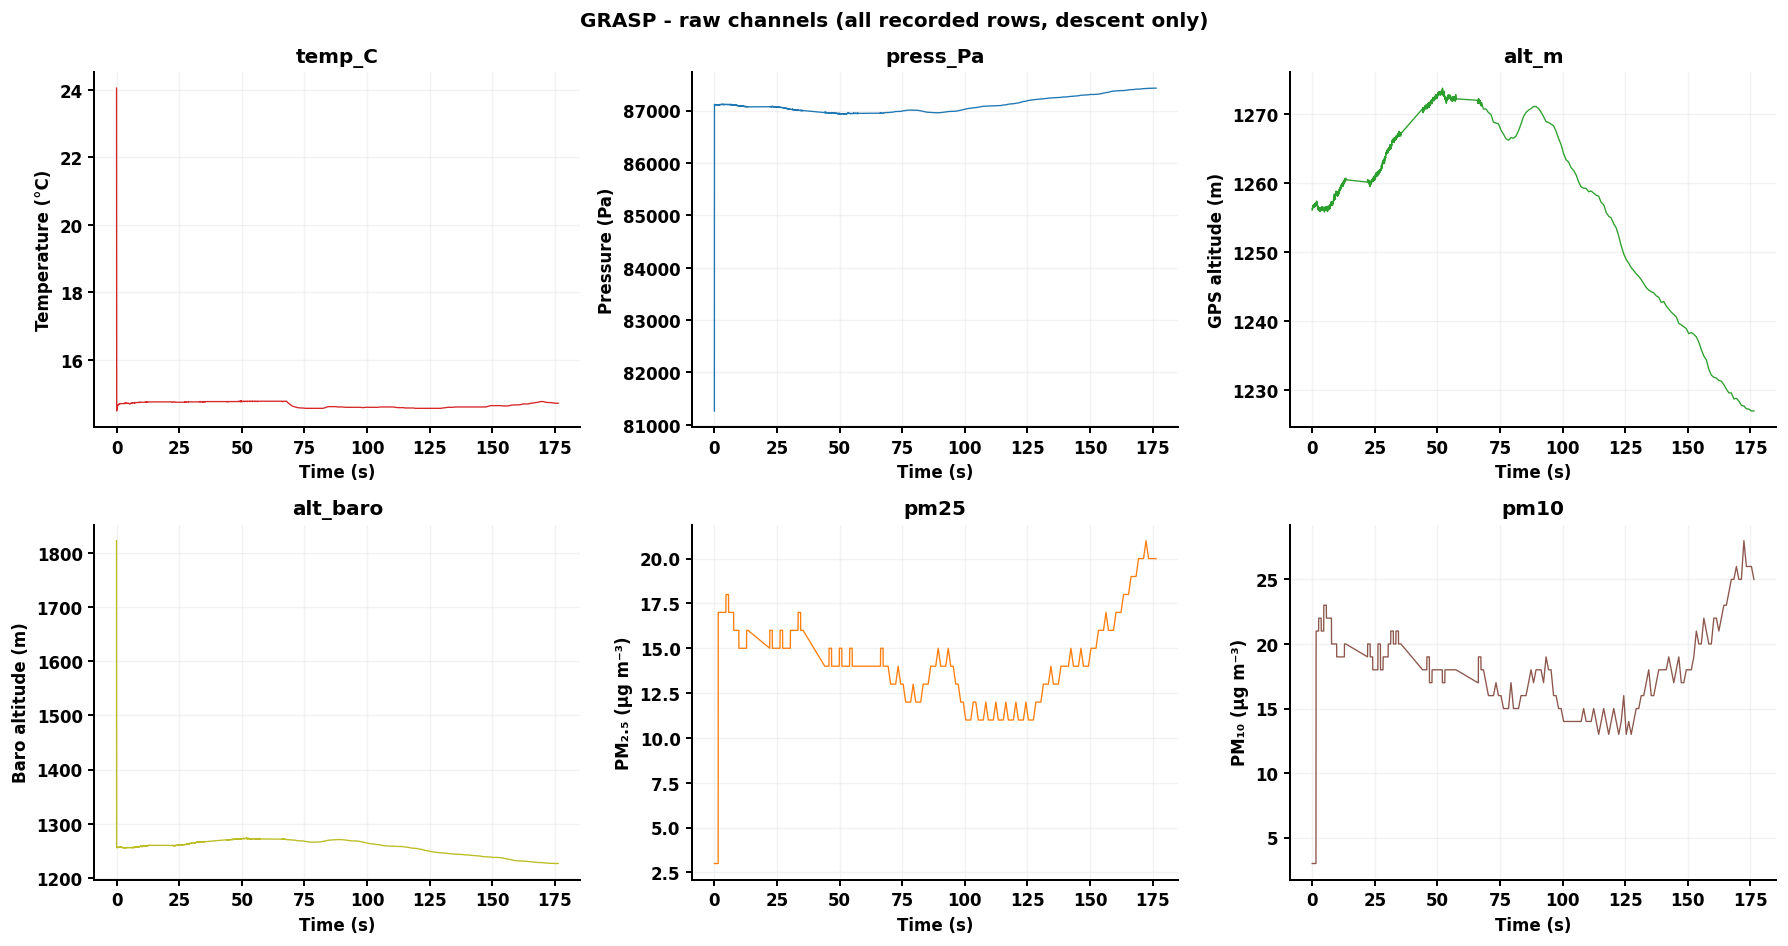

GRASP: 1716 rows | 176 s | fs ≈ 38.0 Hz


In [55]:
# ── 2.1 GRASP raw ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('GRASP - raw channels (all recorded rows, descent only)', fontweight='bold')
_grasp_plot = grasp_raw.copy()
_grasp_plot['alt_baro'] = isa_alt(_grasp_plot['press_Pa'].values)
specs = [
    ('temp_C',   'Temperature (°C)',  'tab:red'),
    ('press_Pa', 'Pressure (Pa)',      'tab:blue'),
    ('alt_m',    'GPS altitude (m)',   'tab:green'),
    ('alt_baro', 'Baro altitude (m)',  'tab:olive'),
    ('pm25',     'PM₂.₅ (µg m⁻³)',   'tab:orange'),
    ('pm10',     'PM₁₀ (µg m⁻³)',    'tab:brown'),
]
for ax, (col, ylabel, color) in zip(axes.flat, specs):
    ax.plot(_grasp_plot['t_rel'], _grasp_plot[col], color=color, lw=0.8)
    ax.set(xlabel='Time (s)', ylabel=ylabel, title=col)
plt.tight_layout()
save_figure(fig, 'plot_raw/grasp_overview.png', strip_text=False)
plt.show()
print(f'GRASP: {len(grasp_raw)} rows | {grasp_raw["t_rel"].iat[-1]:.0f} s | fs ≈ {FS_G} Hz')


### 2.2 VAMOS - Science payload

**Duration: ~100 min | fs ≈ 1 Hz.** Long continuous recording suitable for low-frequency spectral analysis. Gold band = drop phase.


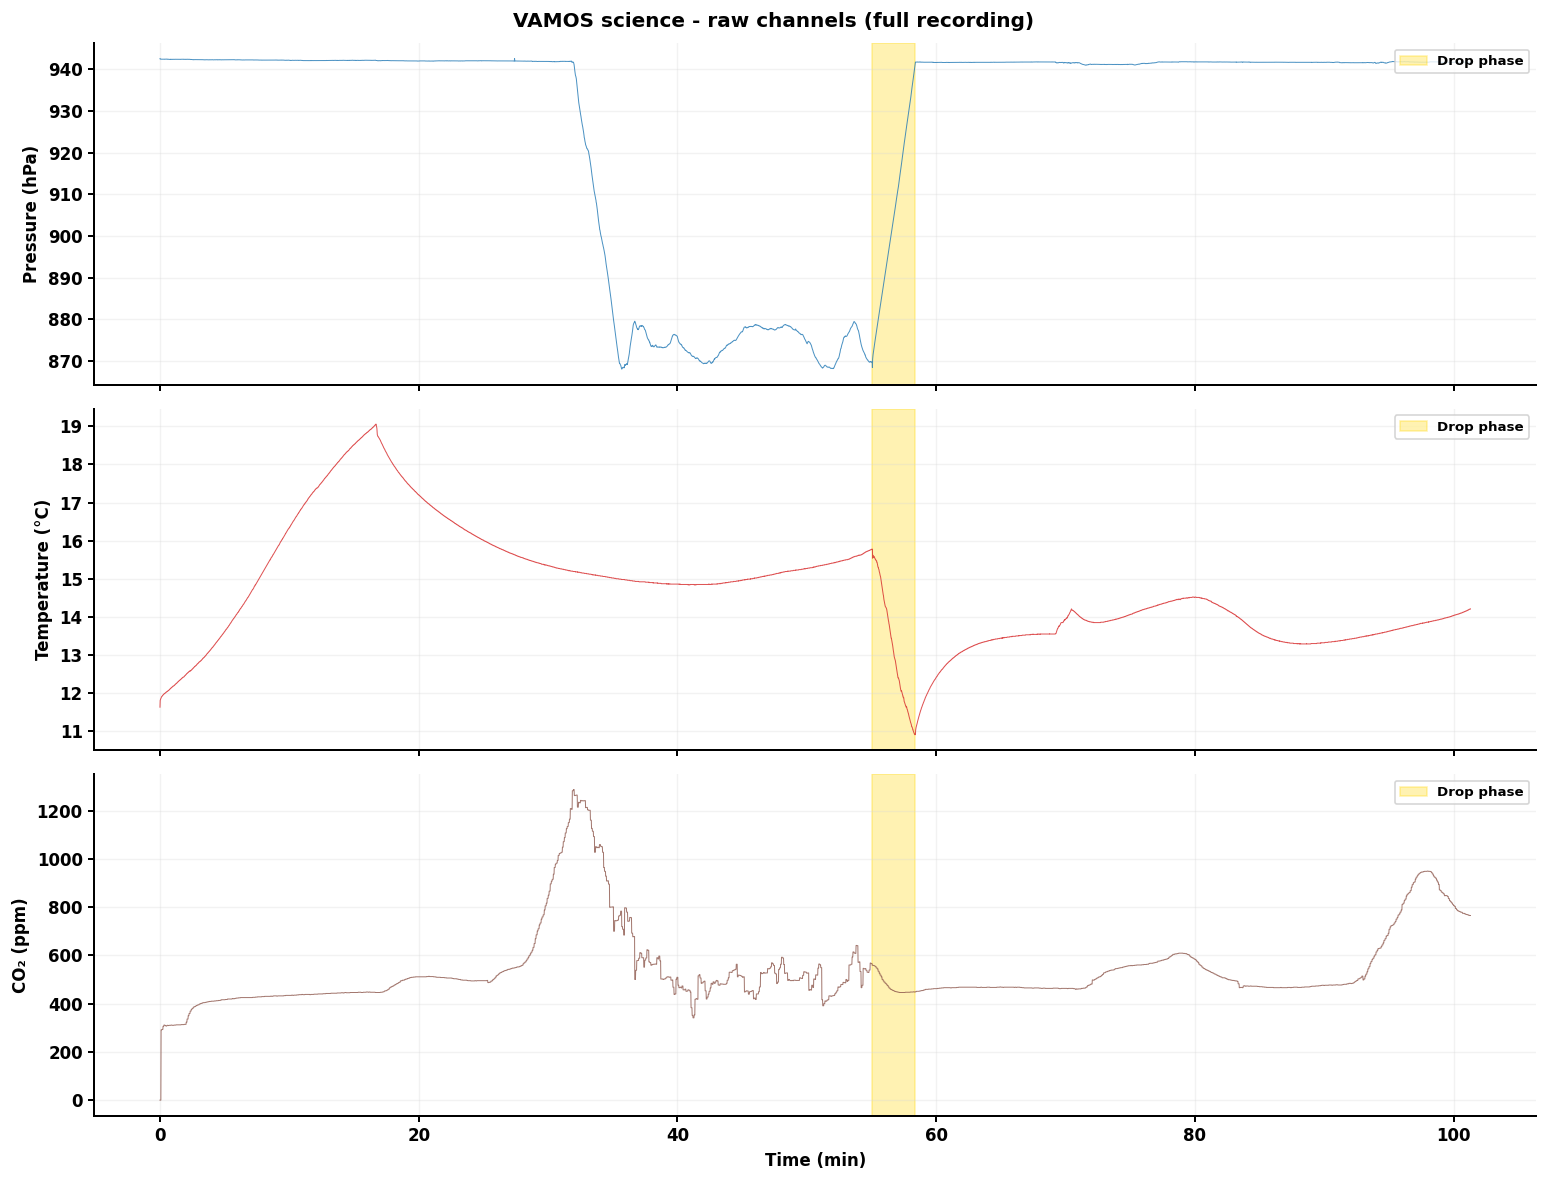

In [56]:
# ── 2.2 VAMOS science raw ────────────────────────────────────────────────────
_apo_m  = (vamos_drop['t_apogee_s']  - vamos['t_s'].iat[0]) / 60
_land_m = (vamos_drop['t_landing_s'] - vamos['t_s'].iat[0]) / 60

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle('VAMOS science - raw channels (full recording)', fontweight='bold')
for ax, (col, ylabel, color) in zip(axes, [
    ('press_hPa', 'Pressure (hPa)',  'tab:blue'),
    ('temp_C',    'Temperature (°C)','tab:red'),
    ('co2_ppm',   'CO₂ (ppm)',       'tab:brown'),
]):
    ax.plot(vamos['t_rel'] / 60, vamos[col], lw=0.6, color=color, alpha=0.8)
    ax.axvspan(_apo_m, _land_m, color='gold', alpha=0.3, label='Drop phase')
    ax.set(ylabel=ylabel)
    ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time (min)')
plt.tight_layout()
save_figure(fig, 'plot_raw/vamos_science_raw.png', strip_text=False)
plt.show()


### 2.3 VAMOS - Wind payload

**Duration: ~100 min | fs ≈ 1 Hz after.** Gold band = drop phase. Frequencies above ~0.5 Hz are not directly resolved.


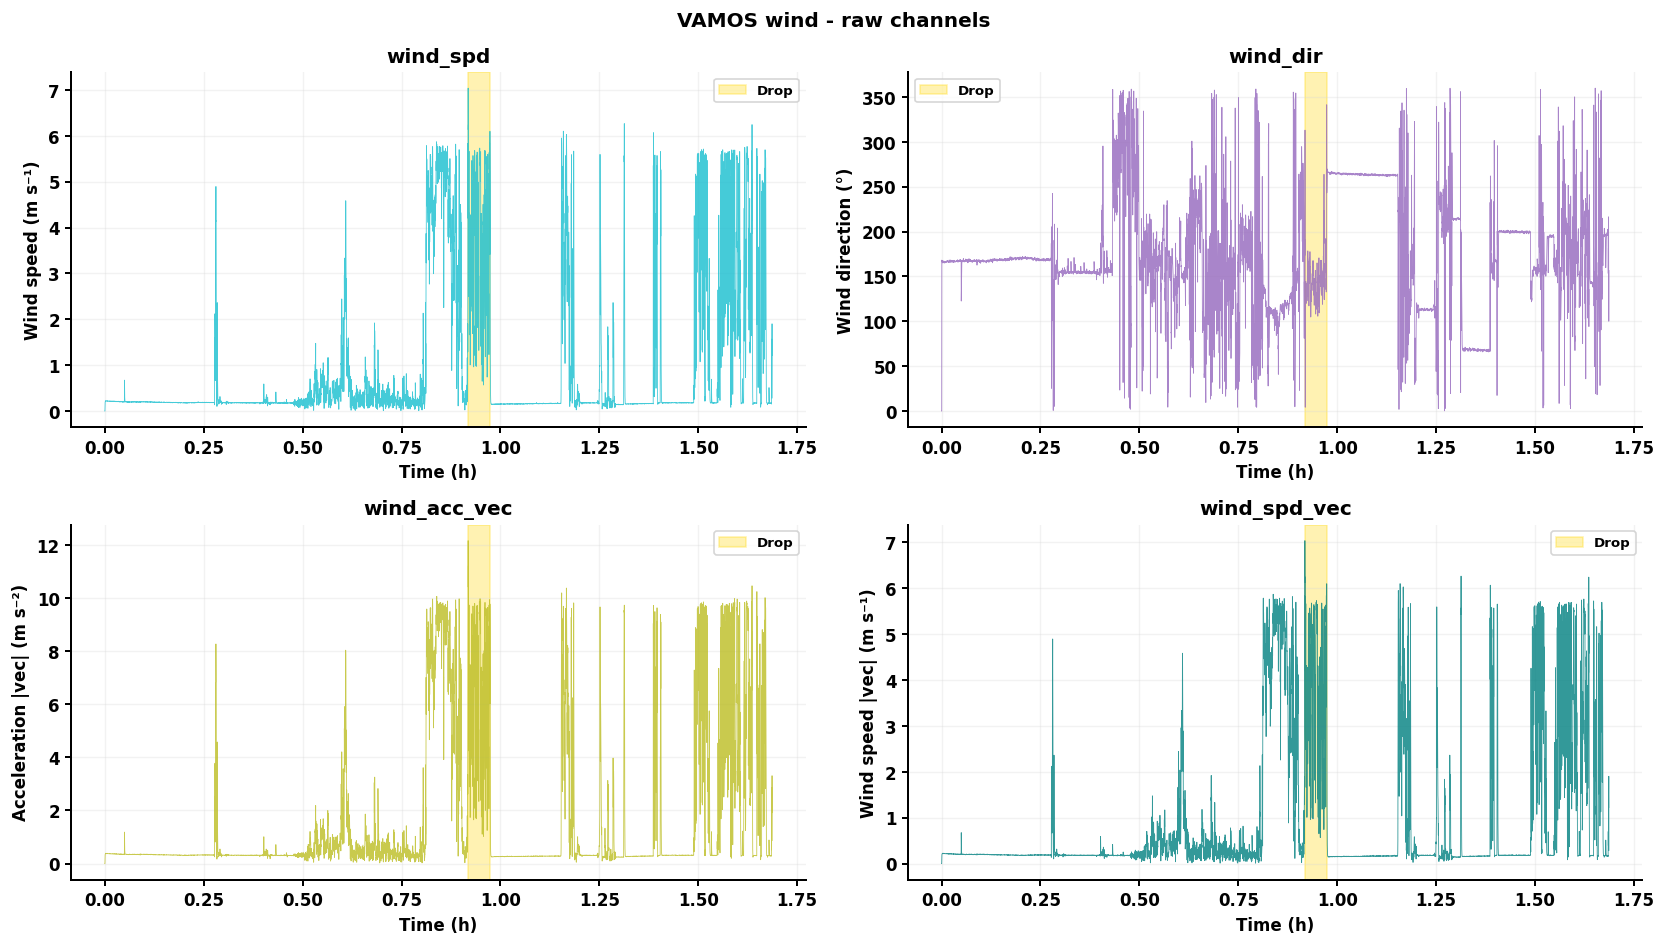

In [57]:
# ── 2.3 VAMOS wind raw ───────────────────────────────────────────────────────
_d0h = (vamos_drop['t_apogee_s']  - wind['t_s'].iat[0]) / 3600
_d1h = (vamos_drop['t_landing_s'] - wind['t_s'].iat[0]) / 3600
_twh = wind['t_rel'].values / 3600

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('VAMOS wind - raw channels', fontweight='bold')
for ax, (col, ylabel, color) in zip(axes.flat, [
    ('wind_spd',     'Wind speed (m s⁻¹)',       'tab:cyan'),
    ('wind_dir',     'Wind direction (°)',        'tab:purple'),
    ('wind_acc_vec', 'Acceleration |vec| (m s⁻²)','tab:olive'),
    ('wind_spd_vec', 'Wind speed |vec| (m s⁻¹)', 'teal'),
]):
    ax.plot(_twh, wind[col], lw=0.5, color=color, alpha=0.8)
    ax.axvspan(_d0h, _d1h, color='gold', alpha=0.3, label='Drop')
    ax.set(xlabel='Time (h)', ylabel=ylabel, title=col)
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'plot_raw/vamos_wind_raw.png', strip_text=False)
plt.show()


### 2.4 OBAMA - External CanSat

**Only 31 rows - insufficient for spectral analysis.** 

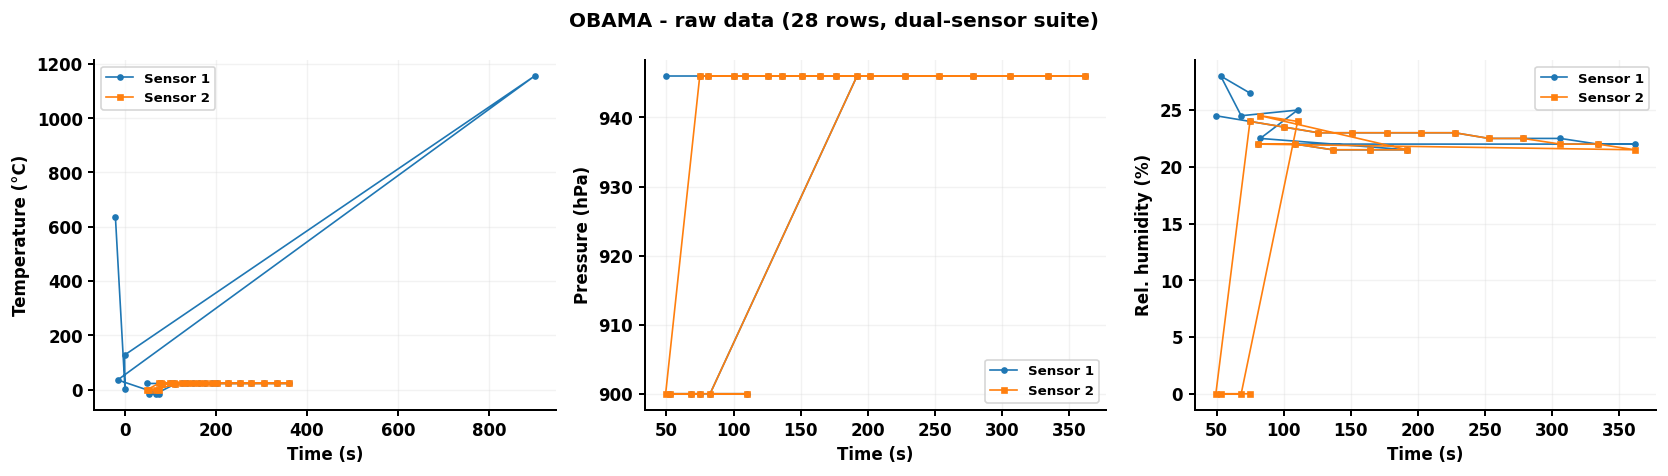

OBAMA: 28 rows - not used for spectral analysis.


In [58]:
# ── 2.4 OBAMA raw ────────────────────────────────────────────────────────────
_ob = obama.dropna(subset=['Time_s'])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'OBAMA - raw data ({len(_ob)} rows, dual-sensor suite)', fontweight='bold')
for ax, (c1, c2, ylabel) in zip(axes, [
    ('first_temp_avg_C',    'second_temp_avg_C',    'Temperature (°C)'),
    ('first_pstat_avg_hPa', 'second_pstat_avg_hPa', 'Pressure (hPa)'),
    ('first_hum_avg_pct',   'second_hum_avg_pct',   'Rel. humidity (%)'),
]):
    ax.plot(_ob['Time_s'], _ob[c1], 'o-', ms=3, lw=1, color='tab:blue',  label='Sensor 1')
    ax.plot(_ob['Time_s'], _ob[c2], 's-', ms=3, lw=1, color='tab:orange',label='Sensor 2')
    ax.set(xlabel='Time (s)', ylabel=ylabel)
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'plot_raw/obama_raw.png', strip_text=False)
plt.show()
print(f'OBAMA: {len(_ob)} rows - not used for spectral analysis.')


### 2.5 ScamSat - Raw channels

**Duration: ~1 h | variable fs.** Long continuous recording, acceleration channel directly measures mechanical oscillations. 

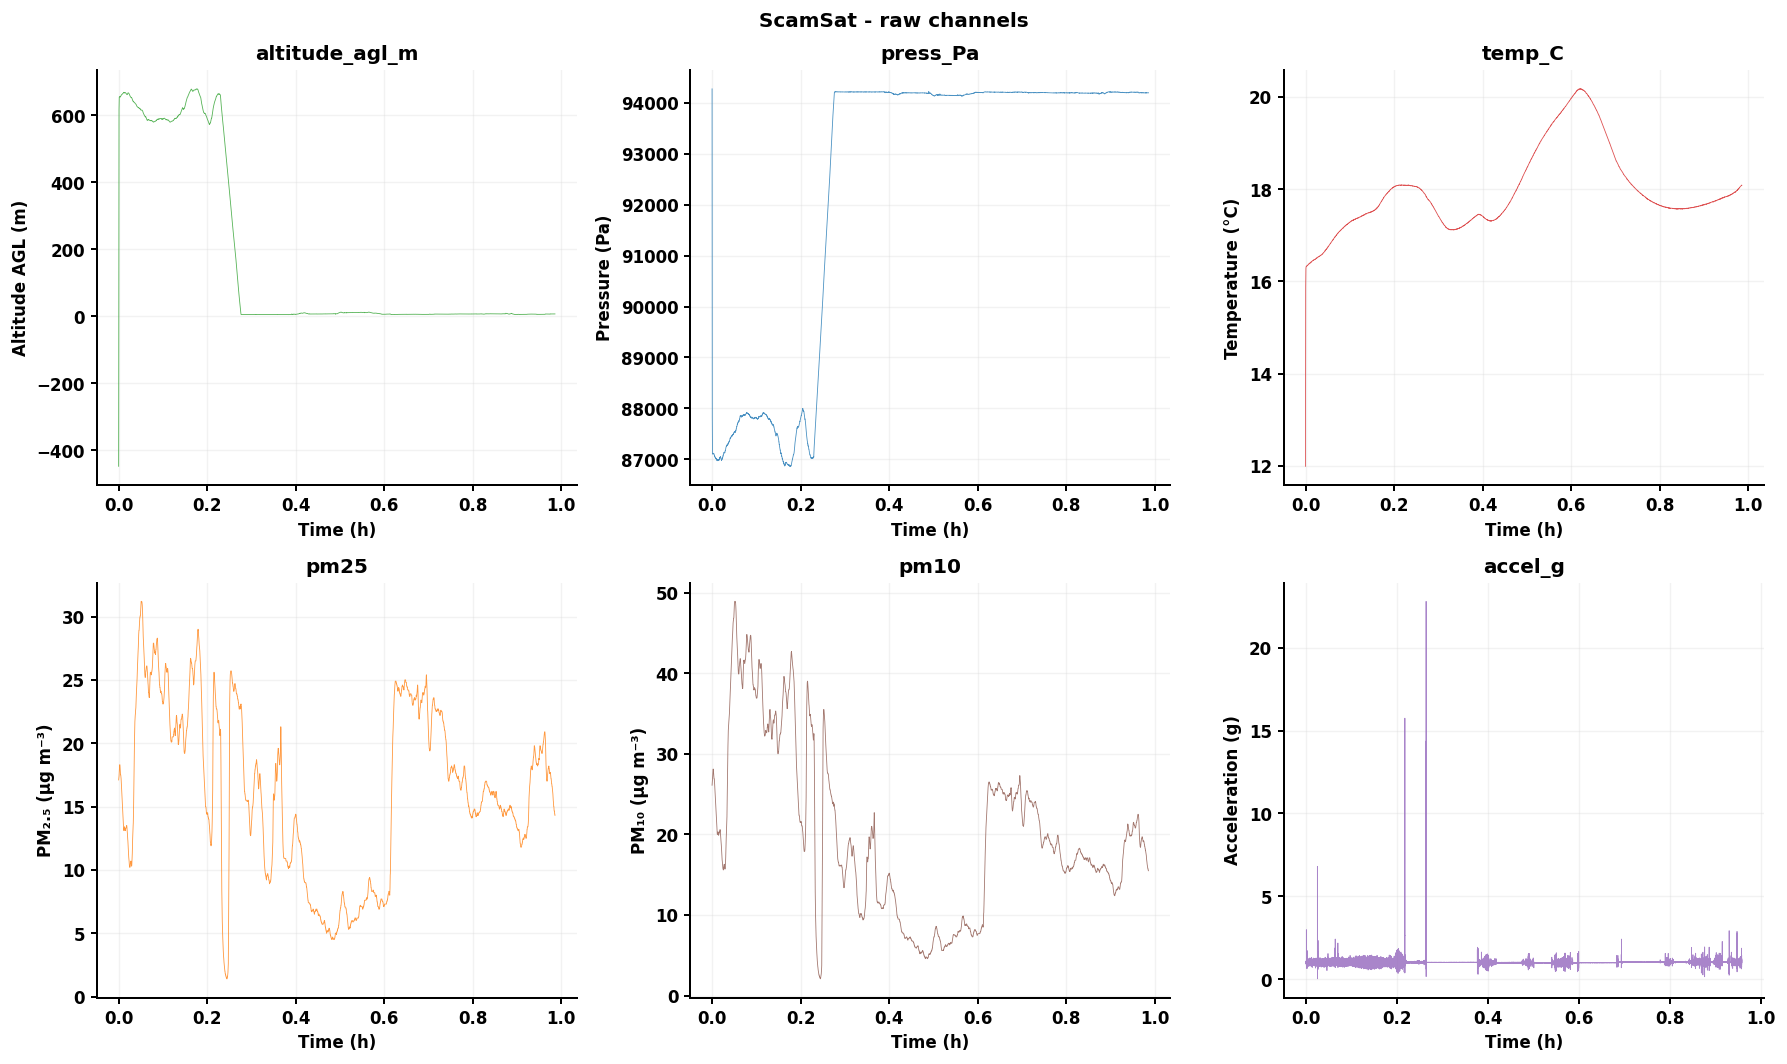

In [59]:
# ── 2.5 ScamSat raw ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('ScamSat - raw channels', fontweight='bold')
for ax, (df, col, ylabel, color) in zip(axes.flat, [
    (scam_alt,   'altitude_agl_m', 'Altitude AGL (m)',      'tab:green'),
    (scam_press, 'press_Pa',       'Pressure (Pa)',          'tab:blue'),
    (scam_temp,  'temp_C',         'Temperature (°C)',       'tab:red'),
    (scam_pm25,  'pm25',           'PM₂.₅ (µg m⁻³)',       'tab:orange'),
    (scam_pm10,  'pm10',           'PM₁₀ (µg m⁻³)',        'tab:brown'),
    (scam_accel, 'accel_g',        'Acceleration (g)',       'tab:purple'),
]):
    ax.plot(df['t_rel'] / 3600, df[col], lw=0.5, color=color, alpha=0.8)
    ax.set(xlabel='Time (h)', ylabel=ylabel, title=col)
plt.tight_layout()
save_figure(fig, 'plot_raw/scamsat_overview.png', strip_text=False)
plt.show()


### 2.6 Known data quality issues in retained datasets

After inspecting the raw channels, the main acquisition artefacts in the datasets retained for analysis are summarised below. The table therefore does not list every possible issue in discarded or unused records; it focuses on problems that directly affect the GRASP, VAMOS and ScamSat signals carried forward in the notebook.

| # | Sensor | Artefact | Cause | Handling |
|---|--------|----------|-------|---------|
| 1 | GRASP | Row-0 pressure spike (81 261 Pa ≡ ~1 820 m) | Sensor initialisation | Drop row 0 in `load_grasp()` caller |
| 2 | VAMOS science | First CO₂ readings = 0 ppm | NDIR thermal warm-up | Exclude `co2_ppm <= 0` |
| 3 | VAMOS science | Multiple timestamp resets before final run | µC reboot / logging restart | `load_vamos_science()` keeps the final continuous segment |
| 4 | VAMOS wind | `tumbling` flag stuck at 0 | Firmware bug | Ignore; use `wind_acc_vec` instead |
| 5 | VAMOS wind | Timestamp reset mid-recording | µC reboot | `load_vamos_wind()` keeps the final continuous segment |
| 6 | VAMOS wind | Possible axial spin/yaw contamination | Payload rotation around vertical axis | Analyse unwrapped `wind_dir` and apparent yaw-rate proxy |


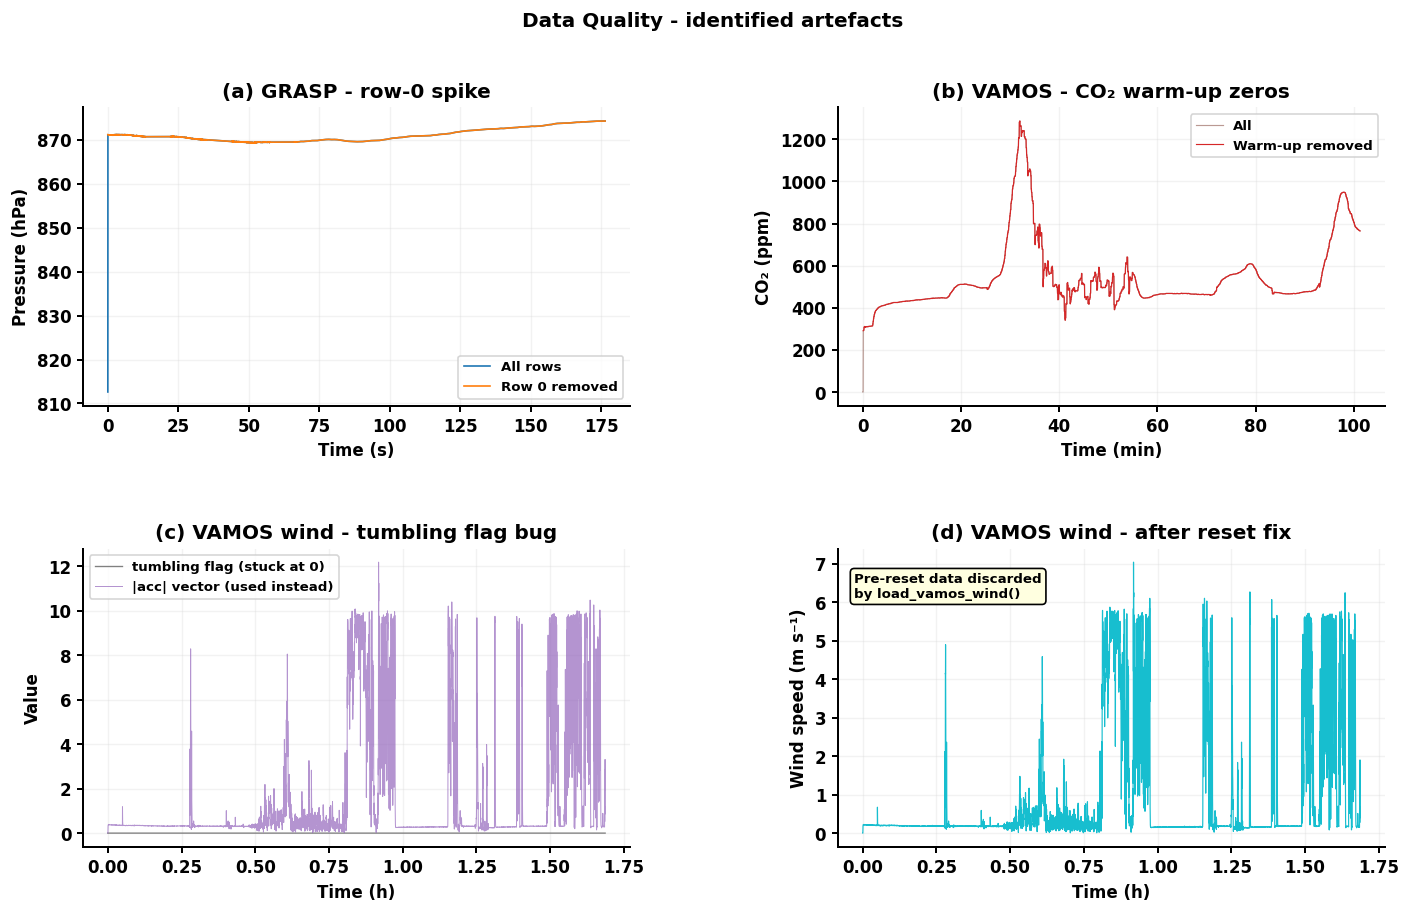

In [60]:
# ── 2.6 Data quality - artefact figure ───────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle('Data Quality - identified artefacts', fontsize=12, fontweight='bold')

# (a) GRASP row-0 pressure spike
ax = fig.add_subplot(gs[0, 0])
ax.plot(grasp_raw['t_rel'], grasp_raw['press_Pa'] / 100, lw=1, color='tab:blue', label='All rows')
ax.plot(grasp_clean['t_rel'], grasp_clean['press_Pa'] / 100, lw=1, color='tab:orange', label='Row 0 removed')
ax.set(xlabel='Time (s)', ylabel='Pressure (hPa)', title='(a) GRASP - row-0 spike')
ax.legend(fontsize=8)

# (b) VAMOS CO₂ warm-up
ax = fig.add_subplot(gs[0, 1])
ax.plot(vamos['t_rel'] / 60, vamos['co2_ppm'], lw=0.7, color='tab:brown', alpha=0.6, label='All')
ax.plot(vamos_co2['t_rel'] / 60, vamos_co2['co2_ppm'], lw=0.7, color='tab:red', label='Warm-up removed')
ax.set(xlabel='Time (min)', ylabel='CO₂ (ppm)', title='(b) VAMOS - CO₂ warm-up zeros')
ax.legend(fontsize=8)

# (c) VAMOS wind - tumbling flag
ax = fig.add_subplot(gs[1, 0])
ax.plot(wind['t_rel'] / 3600, wind['tumbling'],     lw=0.8, color='gray',        label='tumbling flag (stuck at 0)')
ax.plot(wind['t_rel'] / 3600, wind['wind_acc_vec'], lw=0.6, color='tab:purple', alpha=0.7, label='|acc| vector (used instead)')
ax.set(xlabel='Time (h)', ylabel='Value', title='(c) VAMOS wind - tumbling flag bug')
ax.legend(fontsize=8)

# (d) VAMOS wind - clean continuous segment
ax = fig.add_subplot(gs[1, 1])
ax.plot(wind['t_rel'] / 3600, wind['wind_spd'], lw=0.7, color='tab:cyan')
ax.text(0.03, 0.92, 'Pre-reset data discarded\nby load_vamos_wind()',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
ax.set(xlabel='Time (h)', ylabel='Wind speed (m s⁻¹)', title='(d) VAMOS wind - after reset fix')

plt.tight_layout()
save_figure(fig, 'data_quality/fig_artefacts.png', strip_text=False)
plt.show()


### 2.7 Dataset suitability summary

| Dataset | Length | fs (Hz) | Spectral analysis? | Exclusion reason |
|---------|--------|---------|-------------------|------------------|
| GRASP | ~176 s | ≈38 | **No** | Window too short |
| VAMOS science | ~199 s descent from ~6 000 s log | ≈1 | **Yes, limited** | - |
| VAMOS wind | ~199 s descent from ~6 074 s log | ≈1 | **Yes, limited** | - |
| OBAMA | 31 rows | - | **No** | Insufficient sample count |
| ScamSat | detected descent from ~1 h log | ≈28 accel | **Yes** | - |

The spectral pipeline is applied to the **detected descent window only** for VAMOS (science + wind) and ScamSat in §4. ScamSat acceleration resolves the full 0.3-1.0 Hz pendulum band; for the ~1 Hz VAMOS streams, any motion above Nyquist (~0.5 Hz) would alias and is therefore treated cautiously.


---
## 3. Dataset Alignment and Descent Phase Detection

Each sensor uses its own millisecond clock from power-on, so datasets are not globally time-synchronised. The VAMOS science and wind logs are internally aligned after their final timestamp reset.

The key operation in this section is to identify the drop and to **cut away all non-descent samples** before the spectral and profile analyses. Pre-release, aircraft/handling, ground and post-landing intervals can contain dynamics unrelated to the parachute descent; keeping them would dilute or bias the spectra and vertical profiles.



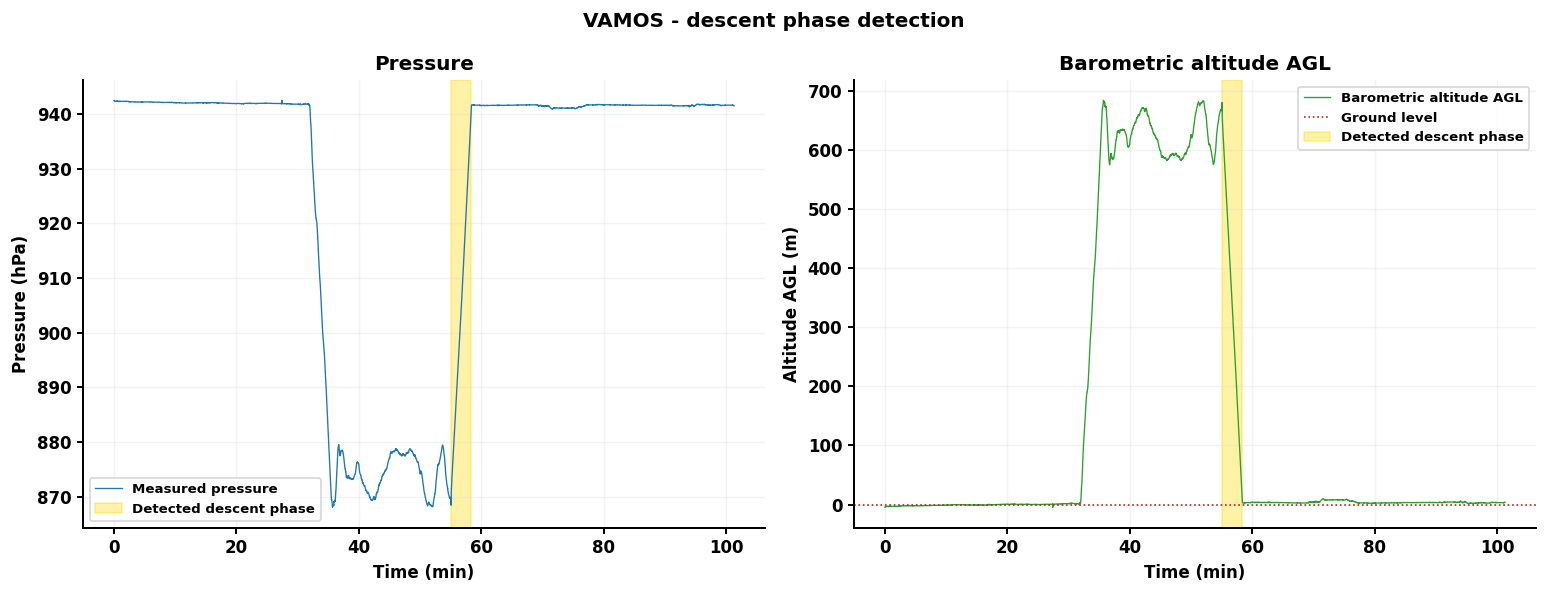

Peak altitude: 681 m AGL
Drop duration: 199 s | Mean descent rate: 3.40 m/s


In [61]:
# ── 3.1 Descent detection ────────────────────────────────────────────────────
_t_min    = vamos['t_rel'].values / 60
_apo_min  = (vamos_drop['t_apogee_s']  - vamos['t_s'].iat[0]) / 60
_land_min = (vamos_drop['t_landing_s'] - vamos['t_s'].iat[0]) / 60

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('VAMOS - descent phase detection', fontweight='bold')

# --- Pressure plot
ax = axes[0]
ax.plot(_t_min, vamos['press_hPa'], color='tab:blue', lw=0.8, label='Measured pressure')
ax.axvspan(_apo_min, _land_min, color='gold', alpha=0.35, label='Detected descent phase')
ax.set(xlabel='Time (min)', ylabel='Pressure (hPa)', title='Pressure')
ax.legend(fontsize=8)

# --- Altitude plot
ax = axes[1]
ax.plot(_t_min, vamos_drop['h_agl'], color='tab:green', lw=0.8, label='Barometric altitude AGL')
ax.axhline(0, color='brown', lw=1, ls=':', label='Ground level')
ax.axvspan(_apo_min, _land_min, color='gold', alpha=0.35, label='Detected descent phase')
ax.set(xlabel='Time (min)', ylabel='Altitude AGL (m)', title='Barometric altitude AGL')
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'flight_dynamics/fig_descent_detection_new.png', strip_text=False)
plt.show()

print(f'Peak altitude: {vamos_drop["h_peak_m"]:.0f} m AGL')
print(
    f'Drop duration: {vamos_drop["drop_duration_s"]:.0f} s | '
    f'Mean descent rate: {vamos_drop["descent_rate_mps"]:.2f} m/s'
)

### 3.2 Descent-window cutouts

The detected/selected windows are materialised as new dataframes (`vamos_spec`, `wind_spec`, `scam_*_spec`). For VAMOS the window is pressure-detected; for ScamSat the automatic max-altitude window is checked but replaced by the shorter sustained-fall interval visible in the altitude trace. From this point onward, spectral operations use these cutouts rather than the full mission records.


In [62]:
# ── 3.2 Build descent-only subsets used downstream ────────────────
PENDULUM_BAND = (0.3, 1.0)
DESCENT_GROUND_THRESHOLD_M = 30.0


def _slice_time(df, start_s, end_s, *, time_col='t_s'):
    """Return the rows inside an inclusive time window."""
    return df.loc[df[time_col].between(start_s, end_s)].copy()


def _detect_altitude_descent(alt_df, *, time_col='t_s', altitude_col='altitude_agl_m', ground_threshold_m=30.0):
    """Detect descent as max altitude AGL -> first later sample back near ground."""
    prof = alt_df[[time_col, altitude_col]].dropna().sort_values(time_col).reset_index(drop=True)
    if len(prof) < 3:
        raise ValueError('Need at least three altitude samples to detect a descent window.')

    apogee_idx = int(prof[altitude_col].idxmax())
    post = prof.loc[apogee_idx:]
    landed = post[post[altitude_col] <= ground_threshold_m]
    landing_idx = int(landed.index[0]) if len(landed) else int(post.index[-1])

    return {
        't_apogee_s': float(prof.loc[apogee_idx, time_col]),
        't_landing_s': float(prof.loc[landing_idx, time_col]),
        'h_peak_m': float(prof.loc[apogee_idx, altitude_col]),
        'h_landing_m': float(prof.loc[landing_idx, altitude_col]),
        'duration_s': float(prof.loc[landing_idx, time_col] - prof.loc[apogee_idx, time_col]),
        'apogee_idx': apogee_idx,
        'landing_idx': landing_idx,
    }


def _window_summary_row(dataset, signal, frame, start_s, end_s, *, time_col='t_s', h_peak_m=np.nan):
    return {
        'dataset': dataset,
        'signal': signal,
        'start_s': float(start_s),
        'end_s': float(end_s),
        'duration_s': float(end_s - start_s),
        'samples': int(len(frame)),
        'h_peak_m': float(h_peak_m) if np.isfinite(h_peak_m) else np.nan,
    }


# VAMOS descent from the pressure-based detector above.
t_apo = vamos_drop['t_apogee_s']
t_land = vamos_drop['t_landing_s']
vamos_spec = _slice_time(vamos, t_apo, t_land)
wind_spec = _slice_time(wind, t_apo, t_land)

# ScamSat descent from its altitude trace.
# A pure max-altitude -> near-ground detector includes a pre-descent/plateau segment.
# The retained window is the visually stable fall used later for PM/CO2 profiles too.
SCAMSAT_DESCENT_START_S = 828.0
SCAMSAT_DESCENT_END_S = 996.0
scam_auto_drop = _detect_altitude_descent(
    scam_alt, altitude_col='altitude_agl_m', ground_threshold_m=DESCENT_GROUND_THRESHOLD_M,
)
scam_t_apo = SCAMSAT_DESCENT_START_S
scam_t_land = SCAMSAT_DESCENT_END_S
_scam_h_start = float(np.interp(scam_t_apo, scam_alt['t_s'], scam_alt['altitude_agl_m']))
_scam_h_land = float(np.interp(scam_t_land, scam_alt['t_s'], scam_alt['altitude_agl_m']))
scam_drop = {
    't_apogee_s': scam_t_apo,
    't_landing_s': scam_t_land,
    'h_peak_m': _scam_h_start,
    'h_landing_m': _scam_h_land,
    'duration_s': scam_t_land - scam_t_apo,
}
scam_alt_spec = _slice_time(scam_alt, scam_t_apo, scam_t_land)
scam_press_spec = _slice_time(scam_press, scam_t_apo, scam_t_land)
scam_accel_spec = _slice_time(scam_accel, scam_t_apo, scam_t_land)
scam_temp_spec = _slice_time(scam_temp, scam_t_apo, scam_t_land)
scam_pm25_spec = _slice_time(scam_pm25, scam_t_apo, scam_t_land)
scam_pm10_spec = _slice_time(scam_pm10, scam_t_apo, scam_t_land)

spectral_windows = pd.DataFrame([
    _window_summary_row('VAMOS', 'science pressure/temp', vamos_spec, t_apo, t_land, h_peak_m=vamos_drop['h_peak_m']),
    _window_summary_row('VAMOS', 'wind', wind_spec, t_apo, t_land, h_peak_m=vamos_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'acceleration', scam_accel_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'temperature', scam_temp_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'altitude', scam_alt_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'pressure', scam_press_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'PM2.5', scam_pm25_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
    _window_summary_row('ScamSat', 'PM10', scam_pm10_spec, scam_t_apo, scam_t_land, h_peak_m=scam_drop['h_peak_m']),
])

print('Descent windows used for spectral analysis:')
print(f'ScamSat automatic max-altitude window would be {scam_auto_drop["duration_s"]:.0f} s; retained fall window is {scam_drop["duration_s"]:.0f} s.')
print(spectral_windows.round({'start_s': 1, 'end_s': 1, 'duration_s': 1, 'h_peak_m': 1}).to_string(index=False))


Descent windows used for spectral analysis:
ScamSat automatic max-altitude window would be 354 s; retained fall window is 168 s.
dataset                signal  start_s  end_s  duration_s  samples  h_peak_m
  VAMOS science pressure/temp   3313.8 3513.2       199.5      196     681.0
  VAMOS                  wind   3313.8 3513.2       199.5      195     681.0
ScamSat          acceleration    828.0  996.0       168.0     4712     660.9
ScamSat           temperature    828.0  996.0       168.0      829     660.9
ScamSat              altitude    828.0  996.0       168.0      169     660.9
ScamSat              pressure    828.0  996.0       168.0      829     660.9
ScamSat                 PM2.5    828.0  996.0       168.0      169     660.9
ScamSat                  PM10    828.0  996.0       168.0      169     660.9


### 3.3 Descent-only subsets carried forward

The plots below show the retained samples after the non-descent portions have been removed. For ScamSat this means the shorter `828-996 s` sustained descent window, not the broader max-altitude window. These are the working subsets used later for PSD/STFT analysis, low-pass profile construction and pressure-coordinate plots.


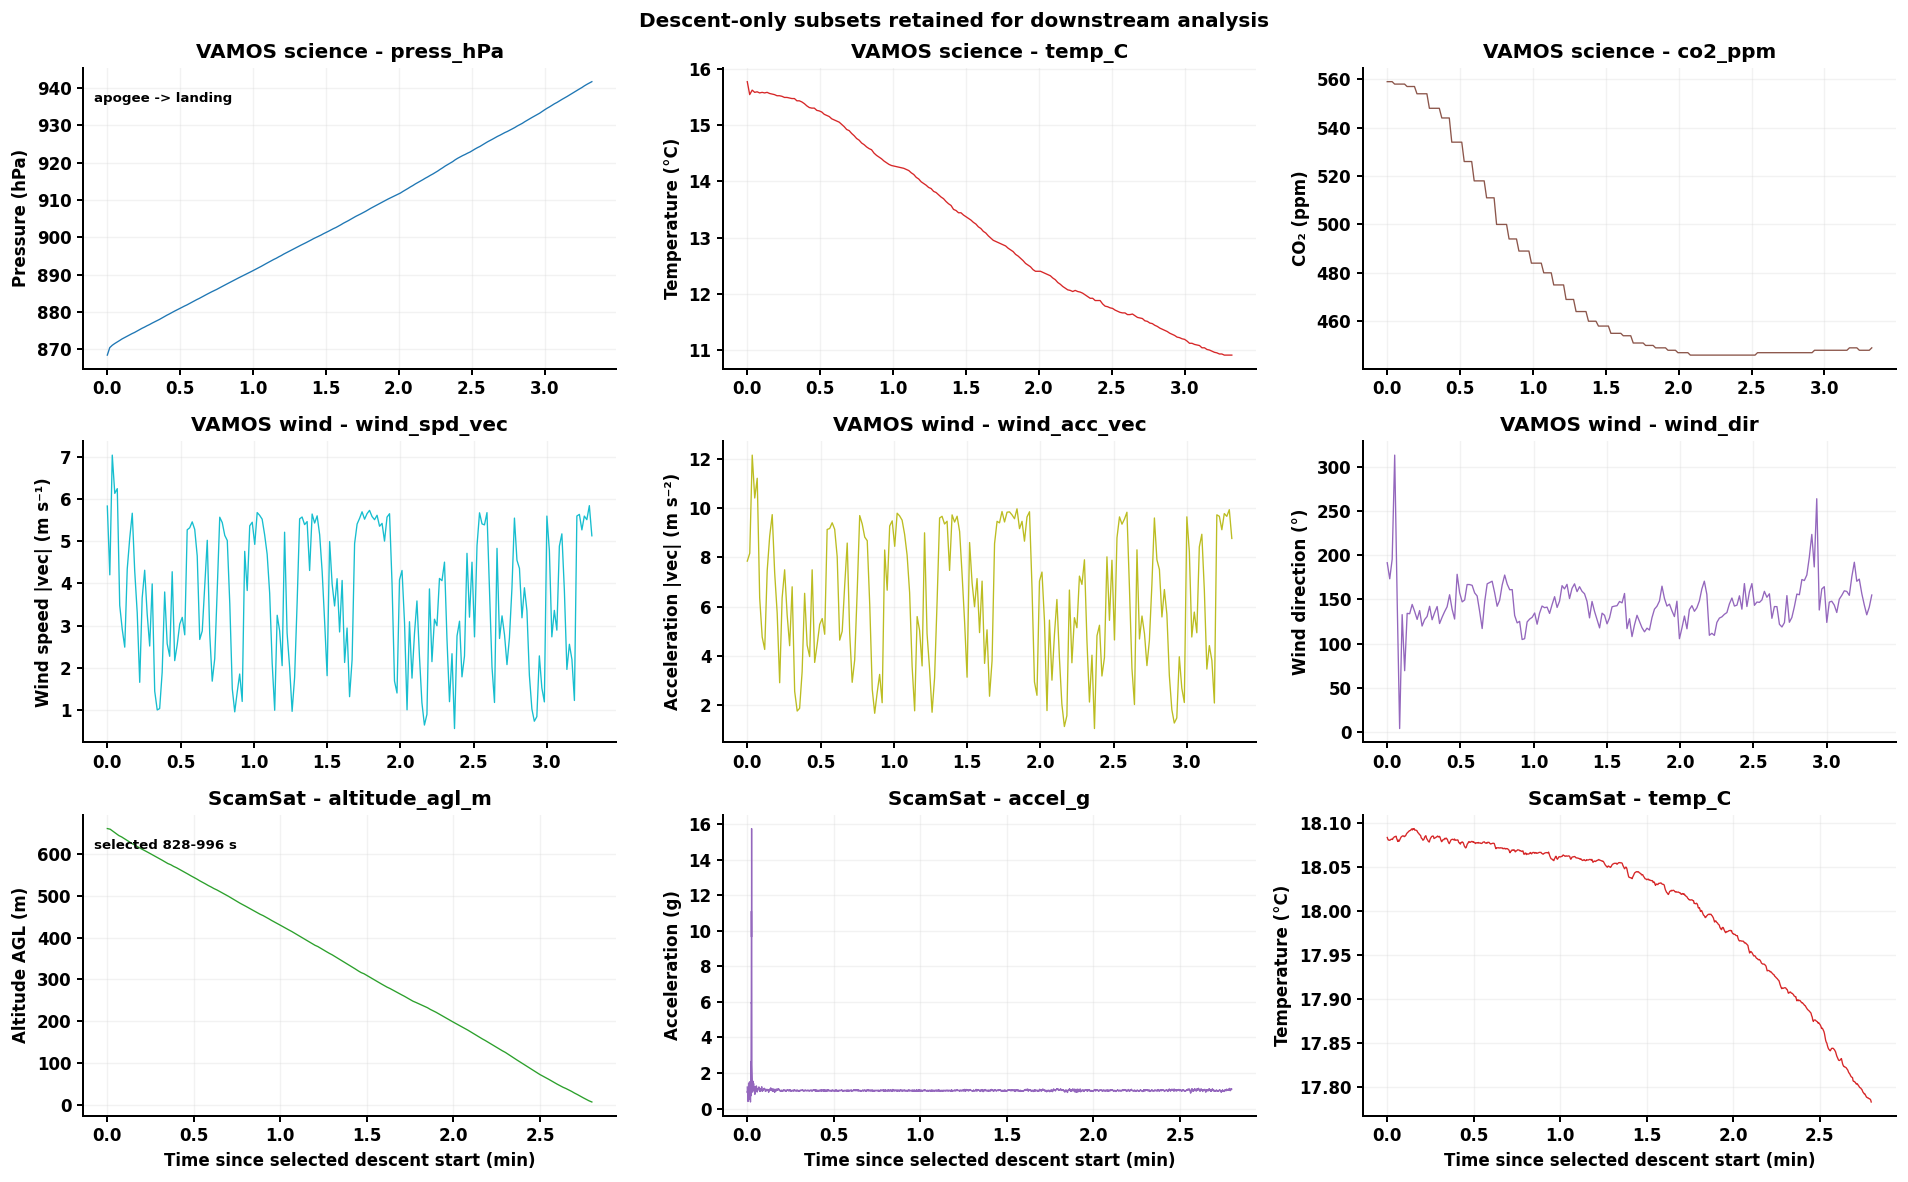

Retained descent-only subsets:
dataset                signal  start_s  end_s  duration_s  samples  h_peak_m
  VAMOS science pressure/temp   3313.8 3513.2       199.5      196     681.0
  VAMOS                  wind   3313.8 3513.2       199.5      195     681.0
ScamSat          acceleration    828.0  996.0       168.0     4712     660.9
ScamSat           temperature    828.0  996.0       168.0      829     660.9
ScamSat              altitude    828.0  996.0       168.0      169     660.9
ScamSat              pressure    828.0  996.0       168.0      829     660.9
ScamSat                 PM2.5    828.0  996.0       168.0      169     660.9
ScamSat                  PM10    828.0  996.0       168.0      169     660.9


In [63]:
# ── 3.3 Plot descent-only subsets used downstream ───────────────────────────
_vamos_tmin = (vamos_spec['t_s'].values - t_apo) / 60.0
_wind_tmin = (wind_spec['t_s'].values - t_apo) / 60.0
_scam_tmin = (scam_alt_spec['t_s'].values - scam_t_apo) / 60.0
_scam_auto_t0 = scam_auto_drop['t_apogee_s']
_scam_auto_t1 = scam_auto_drop['t_landing_s']

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex='row')
fig.suptitle('Descent-only subsets retained for downstream analysis', fontweight='bold')

_vamos_panels = [
    ('press_hPa', 'Pressure (hPa)', 'tab:blue'),
    ('temp_C', 'Temperature (°C)', 'tab:red'),
    ('co2_ppm', 'CO₂ (ppm)', 'tab:brown'),
]
for ax, (col, ylabel, color) in zip(axes[0], _vamos_panels):
    _df = vamos_spec if col != 'co2_ppm' else vamos_spec[vamos_spec['co2_ppm'] > 0]
    ax.plot((_df['t_s'].values - t_apo) / 60.0, _df[col].values, lw=0.8, color=color)
    ax.set(ylabel=ylabel, title=f'VAMOS science - {col}')
axes[0, 0].text(0.02, 0.92, 'apogee -> landing', transform=axes[0, 0].transAxes, fontsize=8, va='top')

_wind_panels = [
    ('wind_spd_vec', 'Wind speed |vec| (m s⁻¹)', 'tab:cyan'),
    ('wind_acc_vec', 'Acceleration |vec| (m s⁻²)', 'tab:olive'),
    ('wind_dir', 'Wind direction (°)', 'tab:purple'),
]
for ax, (col, ylabel, color) in zip(axes[1], _wind_panels):
    ax.plot(_wind_tmin, wind_spec[col].values, lw=0.8, color=color)
    ax.set(ylabel=ylabel, title=f'VAMOS wind - {col}')

_scam_panels = [
    (scam_alt_spec, 'altitude_agl_m', 'Altitude AGL (m)', 'tab:green'),
    (scam_accel_spec, 'accel_g', 'Acceleration (g)', 'tab:purple'),
    (scam_temp_spec, 'temp_C', 'Temperature (°C)', 'tab:red'),
]
for ax, (df, col, ylabel, color) in zip(axes[2], _scam_panels):
    ax.plot((df['t_s'].values - scam_t_apo) / 60.0, df[col].values, lw=0.8, color=color)
    ax.set(xlabel='Time since selected descent start (min)', ylabel=ylabel, title=f'ScamSat - {col}')
axes[2, 0].text(0.02, 0.92, 'selected 828-996 s', transform=axes[2, 0].transAxes, fontsize=8, va='top')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'flight_dynamics/fig_descent_only_subsets.png', strip_text=False)
plt.show()

print('Retained descent-only subsets:')
print(spectral_windows.round({'start_s': 1, 'end_s': 1, 'duration_s': 1, 'h_peak_m': 1}).to_string(index=False))


### 4.1 VAMOS Science - Pressure and Temperature

---
## 4. Spectral Analysis

### 4.0 Pipeline and descent-window selection

Section §3 defines and plots the descent-only subsets used here. Before any FFT, Welch PSD, STFT, or yaw-proxy spectrum is computed, all non-descent samples have already been removed from the analysed signals.

Each selected time series then goes through three spectral steps:

| Step | Tool | Purpose |
|------|------|---------|
| Uniform resampling | Linear interpolation to regular grid | FFT/Welch require equally-spaced samples |
| Linear detrend | Least-squares fit | Remove the descent trend before spectral estimation |
| Spectral estimation | Hann FFT + Welch PSD + STFT | Frequency content, robust PSD, time-frequency evolution |

Low-pass filtering is applied later to produce smooth atmospheric profiles. It is deliberately not used as a precondition for the PSD/STFT peak search, because a 0.3-0.4 Hz low-pass would suppress much of the pendulum band.

#### Pendulum frequency reference

For suspension length $L$:

$$f_{\mathrm{pend}} = \frac{1}{2\pi}\sqrt{\frac{g}{L}}$$

| $L$ (m) | $f_{\mathrm{pend}}$ (Hz) |
|---------|--------------------------|
| 3.0 | 0.29 |
| 1.0 | 0.50 |
| 0.5 | 0.70 |
| 0.3 | 0.91 |

A persistent narrow peak in **0.3-1.0 Hz** during the retained descent window would indicate pendulum oscillation. With ~1 Hz VAMOS sampling, only the lower part of this band (≈0.3-0.5 Hz) is resolved; ScamSat acceleration resolves the full band.


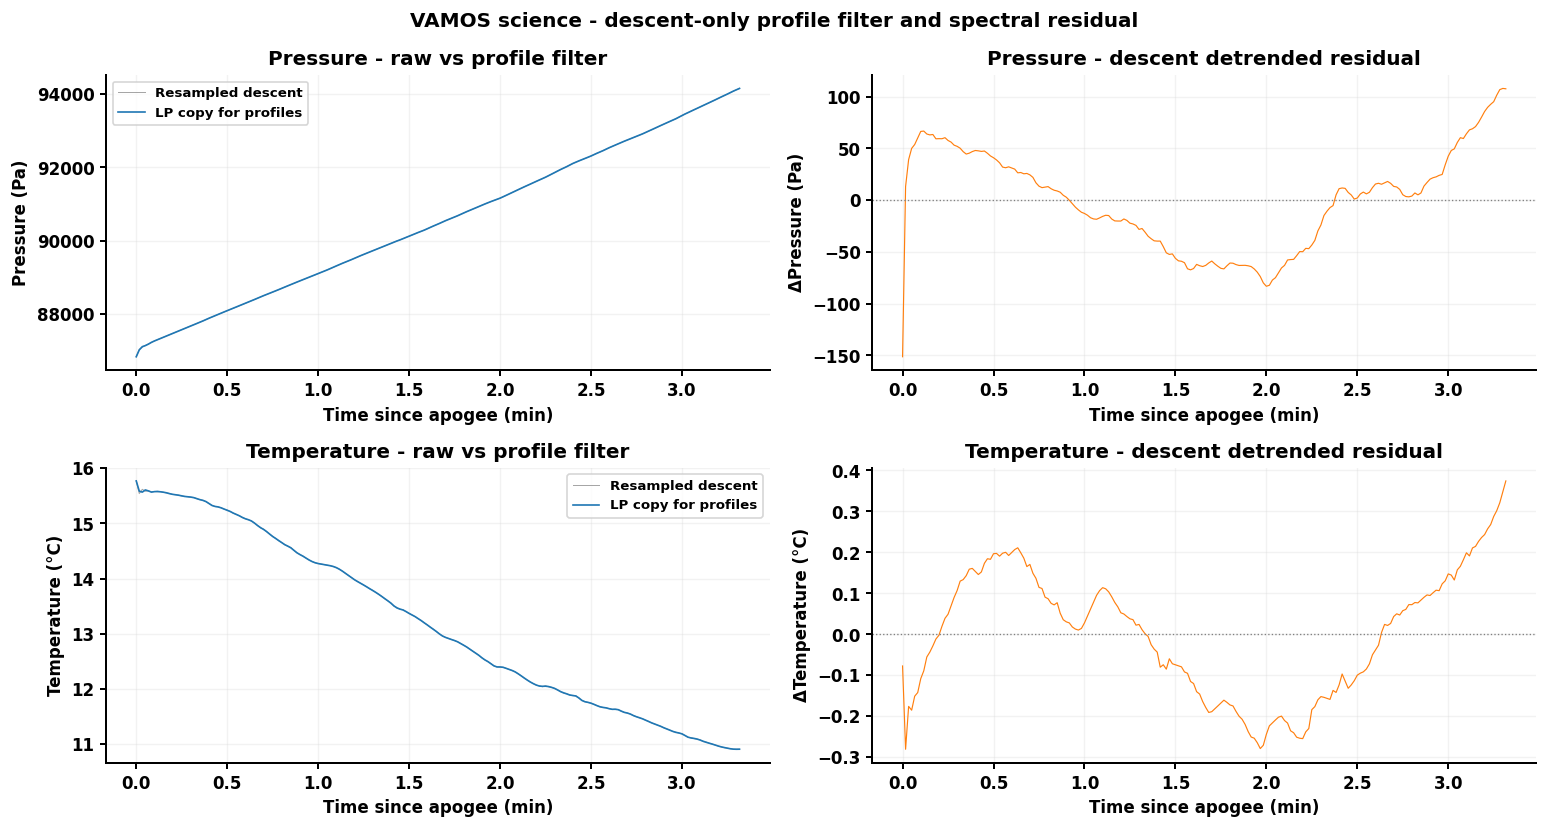

VAMOS science descent: 196 raw samples | 199 s resampled at 1 Hz | Nyquist = 0.50 Hz
Resolved pendulum band for VAMOS science: 0.30-0.50 Hz


In [64]:
# ── 4.1 Resample + profile filter + spectral detrend ───────────────────────
def _resolved_band(fs, band=PENDULUM_BAND):
    """Return the part of a frequency band that is below Nyquist."""
    lo, hi = band
    return lo, min(hi, 0.5 * float(fs))


def _shade_resolved_band(ax, fs, *, label='Resolved pendulum band', color='gold', alpha=0.25):
    lo, hi = _resolved_band(fs)
    if hi > lo:
        ax.axvspan(lo, hi, color=color, alpha=alpha, label=label)


def _band_peak_report(freqs, psd, fs, band=PENDULUM_BAND):
    """Summarise the strongest PSD bin in the resolved pendulum band."""
    lo, hi = _resolved_band(fs, band)
    in_band = (freqs >= lo) & (freqs <= hi)
    background_hi = min(max(hi, 1.0), 0.5 * float(fs))
    background = (freqs >= 0.05) & (freqs <= background_hi) & ~in_band
    if hi <= lo or not np.any(in_band):
        return {'resolved_band_hz': f'{lo:.2f}-{hi:.2f}', 'peak_hz': np.nan,
                'peak_psd': np.nan, 'peak_to_background': np.nan}

    band_freqs = freqs[in_band]
    band_psd = psd[in_band]
    peak_idx = int(np.nanargmax(band_psd))
    bg = np.nanmedian(psd[background]) if np.any(background) else np.nan
    ratio = band_psd[peak_idx] / bg if np.isfinite(bg) and bg > 0 else np.nan
    return {
        'resolved_band_hz': f'{lo:.2f}-{hi:.2f}',
        'peak_hz': float(band_freqs[peak_idx]),
        'peak_psd': float(band_psd[peak_idx]),
        'peak_to_background': float(ratio) if np.isfinite(ratio) else np.nan,
    }


t_v = vamos_spec['t_rel'].values
p_v = vamos_spec['press_hPa'].values * 100.0   # Pa
T_v = vamos_spec['temp_C'].values

t_vu, p_vu = resample_uniform(t_v, p_v, FS_V)
_,   T_vu  = resample_uniform(t_v, T_v, FS_V)
_t_vu_min = (t_vu - t_vu[0]) / 60.0

# Smooth copies for atmospheric/profile plots only.
p_vf = butter_lowpass(p_vu, cutoff_hz=min(0.3, FS_V * 0.45), fs=FS_V, order=4)
T_vf = butter_lowpass(T_vu, cutoff_hz=min(0.3, FS_V * 0.45), fs=FS_V, order=4)

# Spectra use the descent-only resampled raw signal after detrending, not the low-pass copy.
p_vd = detrend_linear(p_vu, t_vu)
T_vd = detrend_linear(T_vu, t_vu)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('VAMOS science - descent-only profile filter and spectral residual', fontweight='bold')
for i, (raw_u, filt, detr, lbl, unit) in enumerate([
    (p_vu, p_vf, p_vd, 'Pressure', 'Pa'),
    (T_vu, T_vf, T_vd, 'Temperature', '°C'),
]):
    axes[i,0].plot(_t_vu_min, raw_u, lw=0.6, color='gray', alpha=0.7, label='Resampled descent')
    axes[i,0].plot(_t_vu_min, filt, lw=1.0, color='tab:blue', label='LP copy for profiles')
    axes[i,0].set(xlabel='Time since apogee (min)', ylabel=f'{lbl} ({unit})', title=f'{lbl} - raw vs profile filter')
    axes[i,0].legend(fontsize=8)
    axes[i,1].plot(_t_vu_min, detr, lw=0.7, color='tab:orange')
    axes[i,1].axhline(0, color='gray', lw=0.8, ls=':')
    axes[i,1].set(xlabel='Time since apogee (min)', ylabel=f'Δ{lbl} ({unit})', title=f'{lbl} - descent detrended residual')
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_filter.png', strip_text=False)
plt.show()

_lo, _hi = _resolved_band(FS_V)
print(f'VAMOS science descent: {len(vamos_spec)} raw samples | {t_vu[-1] - t_vu[0]:.0f} s resampled at {FS_V:.0f} Hz | Nyquist = {FS_V/2:.2f} Hz')
print(f'Resolved pendulum band for VAMOS science: {_lo:.2f}-{_hi:.2f} Hz')


 window      signal resolved_band_hz  peak_hz  peak_to_background
Descent    Pressure        0.30-0.50     0.31               0.399
Descent Temperature        0.30-0.50     0.49               1.293


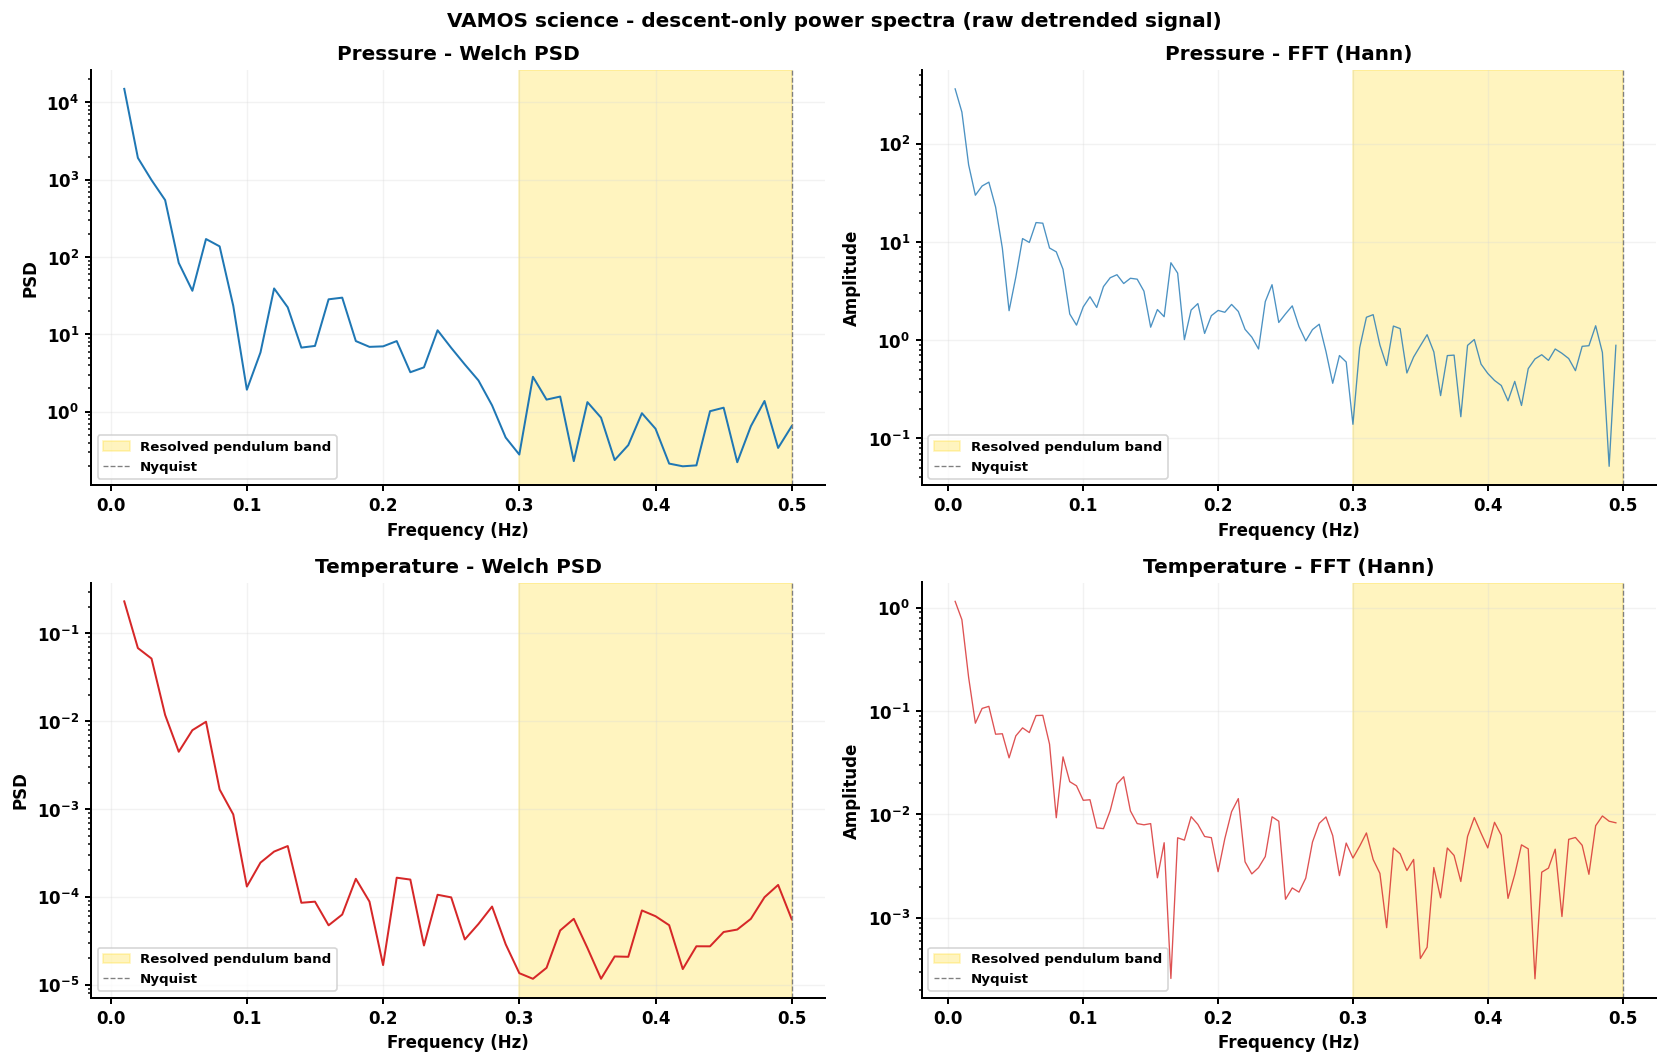

In [65]:
# ── 4.1 Welch PSD + Hann FFT ───────────────────────────────────────────────
NPERSEG_V = min(128, max(32, len(p_vd) // 2))

fw_p, psd_p, *_ = compute_welch_psd(t_vu, p_vd, FS_V, NPERSEG_V)
fw_T, psd_T, *_ = compute_welch_psd(t_vu, T_vd, FS_V, NPERSEG_V)

science_peak_stats = []
for signal_name, freqs, psd in [
    ('Pressure', fw_p, psd_p),
    ('Temperature', fw_T, psd_T),
]:
    report = _band_peak_report(freqs, psd, FS_V)
    report.update({'window': 'Descent', 'signal': signal_name})
    science_peak_stats.append(report)
science_peak_stats = pd.DataFrame(science_peak_stats)
print(science_peak_stats[['window', 'signal', 'resolved_band_hz', 'peak_hz', 'peak_to_background']].round(3).to_string(index=False))

N = len(p_vd)
hw = np.hanning(N)
nrm = np.sqrt(np.sum(hw**2))
P_f = np.abs(fft(p_vd * hw))[:N//2] / nrm
T_f = np.abs(fft(T_vd * hw))[:N//2] / nrm
f_f = fftfreq(N, 1.0/FS_V)[:N//2]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('VAMOS science - descent-only power spectra (raw detrended signal)', fontweight='bold')
for row, (fw, psd, ff, amp, lbl, col) in enumerate([
    (fw_p, psd_p, f_f, P_f, 'Pressure (Pa)', 'tab:blue'),
    (fw_T, psd_T, f_f, T_f, 'Temperature (°C)', 'tab:red'),
]):
    axes[row,0].semilogy(fw[1:], psd[1:], color=col, lw=1.2)
    _shade_resolved_band(axes[row,0], FS_V)
    axes[row,0].axvline(FS_V/2, color='gray', lw=0.8, ls='--', label='Nyquist')
    axes[row,0].set(xlabel='Frequency (Hz)', ylabel='PSD', title=f'{lbl.split()[0]} - Welch PSD')
    axes[row,0].legend(fontsize=8)
    axes[row,1].semilogy(ff[1:], amp[1:], color=col, lw=0.8, alpha=0.8)
    _shade_resolved_band(axes[row,1], FS_V)
    axes[row,1].axvline(FS_V/2, color='gray', lw=0.8, ls='--', label='Nyquist')
    axes[row,1].set(xlabel='Frequency (Hz)', ylabel='Amplitude', title=f'{lbl.split()[0]} - FFT (Hann)')
    axes[row,1].legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_psd.png', strip_text=False)
plt.show()


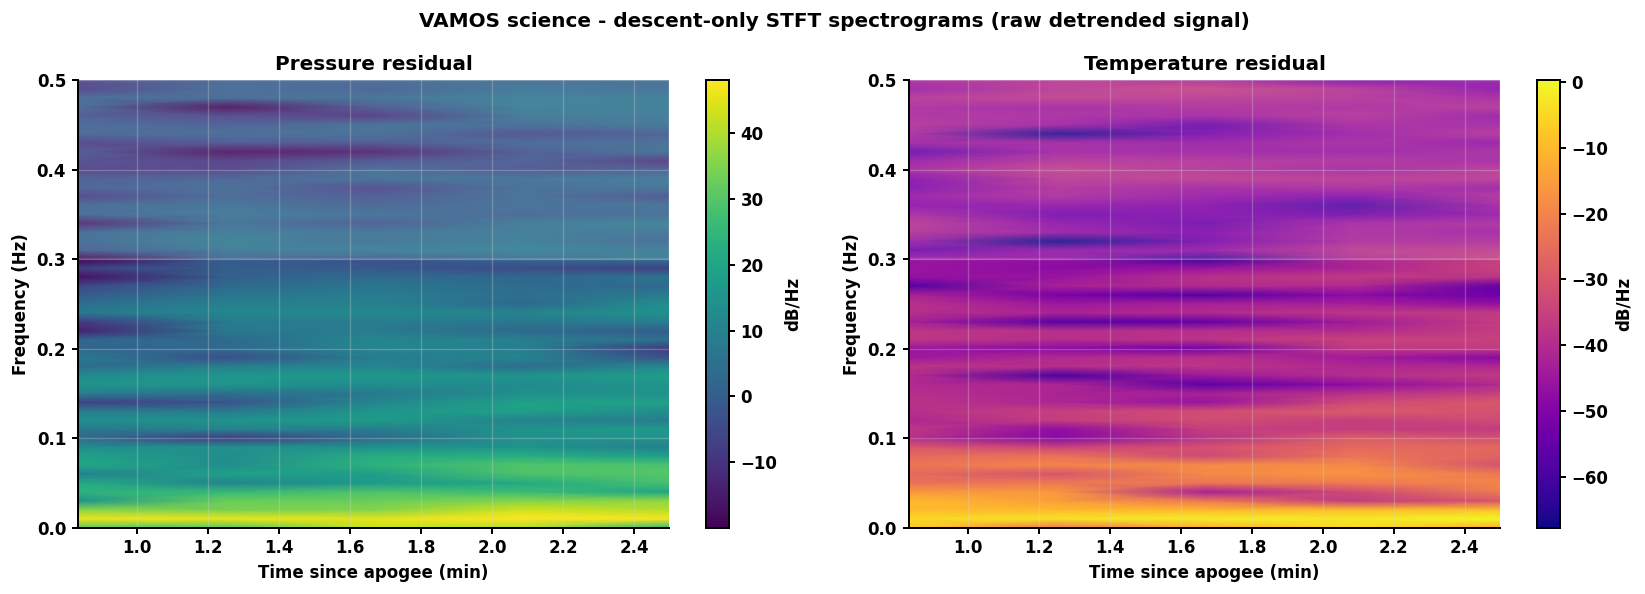

In [66]:
# ── 4.1 STFT spectrogram ─────────────────────────────────────────────────────
NSTFT = min(128, max(32, len(p_vd) // 2))
NOLAP = min(NSTFT * 3 // 4, NSTFT - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VAMOS science - descent-only STFT spectrograms (raw detrended signal)', fontweight='bold')
for ax, (sig, lbl, cmap) in zip(axes, [
    (p_vd, 'Pressure residual', 'viridis'),
    (T_vd, 'Temperature residual', 'plasma'),
]):
    fs, ts, Zxx = _scipy_spectrogram(sig, fs=FS_V, nperseg=NSTFT, noverlap=NOLAP, window='hann')
    im = ax.pcolormesh(ts/60, fs, 10*np.log10(np.abs(Zxx)+1e-30), shading='gouraud', cmap=cmap)
    lo, hi = _resolved_band(FS_V)
    if hi > lo:
        ax.axhspan(lo, hi, color='white', alpha=0.12, label='Resolved pendulum band')
    ax.set(xlabel='Time since apogee (min)', ylabel='Frequency (Hz)', title=f'{lbl}', ylim=(0, FS_V/2))
    plt.colorbar(im, ax=ax, label='dB/Hz')
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_stft.png', strip_text=False)
plt.show()


#### Results - VAMOS science

The pressure-derived apogee -> landing interval is selected before resampling, detrending, FFT, Welch PSD, or STFT.  The full recording remains useful as context in §2, but it is no longer part of the spectral test.

Within the **resolved** pendulum band for this ~1 Hz stream (≈0.3-0.5 Hz), neither pressure nor temperature shows a strong narrow peak during the detected descent. Frequencies above Nyquist cannot be interpreted from VAMOS science and are therefore not used as evidence for or against faster pendulum motion.

**Conclusion:** VAMOS pressure and temperature show no resolved low-frequency parachute artefact during descent. The low-pass copies are used only for smooth atmospheric profiles, not as evidence in the spectral test.


### 4.2 VAMOS Wind - Descent-only Spectral Analysis

The wind sensor records over the full mission, but pendulum and yaw artefacts are only physically relevant during parachute descent.  The PSD, STFT, and wind-direction yaw proxy below therefore use only the VAMOS apogee -> landing interval detected from pressure.


VAMOS wind descent window: 195 samples | 199 s


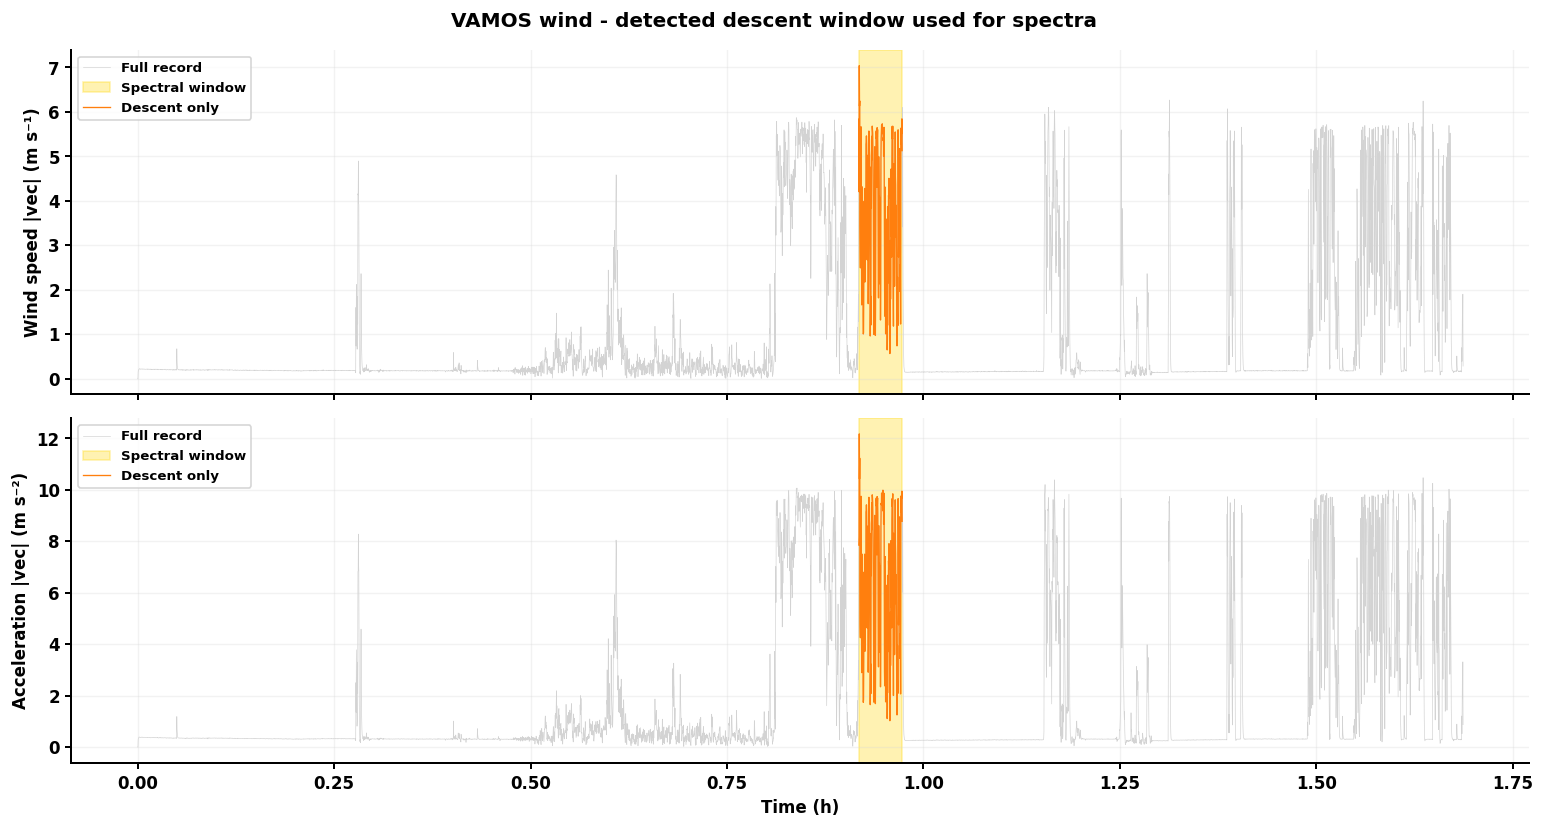

In [67]:
# ── 4.2 Descent window selection ─────────────────────────────────────────────
_twh = wind['t_rel'].values / 3600
_d0h = (t_apo - wind['t_s'].iat[0]) / 3600
_d1h = (t_land - wind['t_s'].iat[0]) / 3600
_twd_min = (wind_spec['t_s'].values - t_apo) / 60.0

print(f'VAMOS wind descent window: {len(wind_spec)} samples | {t_land - t_apo:.0f} s')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('VAMOS wind - detected descent window used for spectra', fontweight='bold')
for ax, col, ylabel in zip(axes, ['wind_spd_vec', 'wind_acc_vec'],
                                   ['Wind speed |vec| (m s⁻¹)', 'Acceleration |vec| (m s⁻²)']):
    ax.plot(_twh, wind[col], lw=0.4, color='lightgray', label='Full record')
    ax.axvspan(_d0h, _d1h, color='gold', alpha=0.3, label='Spectral window')
    ax.plot(wind_spec['t_rel'].values / 3600, wind_spec[col].values, lw=0.8, color='tab:orange', label='Descent only')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Time (h)')
plt.tight_layout()
save_figure(fig, 'flight_dynamics/fig_wind_phases.png', strip_text=False)
plt.show()


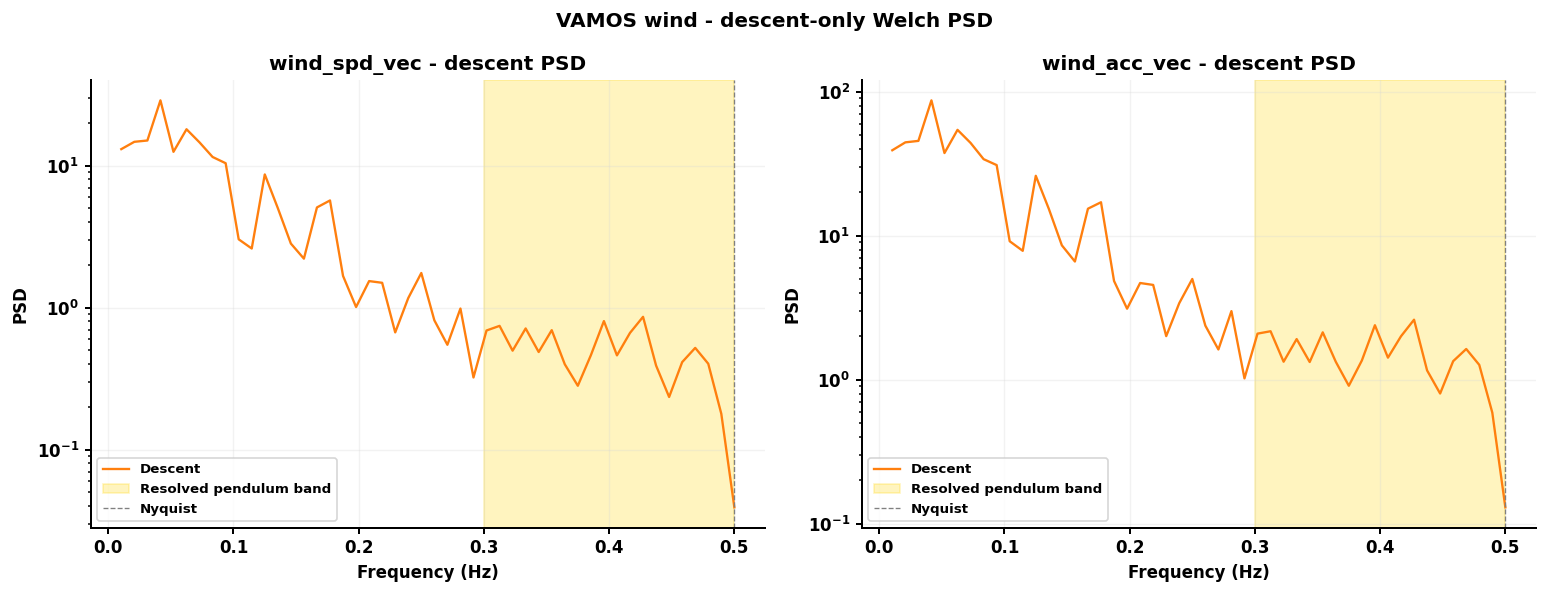

 window       signal resolved_band_hz  peak_hz  peak_to_background
Descent wind_spd_vec        0.30-0.50    0.427               0.358
Descent wind_acc_vec        0.30-0.50    0.427               0.361


In [68]:
# ── 4.2 Descent-only Welch PSD ───────────────────────────────────────────────
FS_W_PSD = FS_W
NPERSEG_W = min(96, max(32, len(wind_spec) // 2))
_wind_peak_stats = []

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('VAMOS wind - descent-only Welch PSD', fontweight='bold')
for ax, col in zip(axes, ['wind_spd_vec', 'wind_acc_vec']):
    seg = wind_spec.dropna(subset=['t_rel', col])
    if len(seg) < 32:
        print(f'Skip descent/{col}: {len(seg)} samples')
        continue
    f_w, psd_w, *_ = compute_welch_psd(seg['t_rel'].values, seg[col].values, FS_W_PSD, NPERSEG_W)
    report = _band_peak_report(f_w, psd_w, FS_W_PSD)
    report.update({'window': 'Descent', 'signal': col})
    _wind_peak_stats.append(report)
    ax.semilogy(f_w[1:], psd_w[1:], label='Descent', color='tab:orange', lw=1.4)
    _shade_resolved_band(ax, FS_W_PSD)
    ax.axvline(FS_W_PSD/2, color='gray', lw=0.8, ls='--', label='Nyquist')
    ax.set(xlabel='Frequency (Hz)', ylabel='PSD', title=f'{col} - descent PSD')
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_wind_psd_phases.png', strip_text=False)
plt.show()

_wind_peak_stats = pd.DataFrame(_wind_peak_stats)
print(_wind_peak_stats[['window', 'signal', 'resolved_band_hz', 'peak_hz', 'peak_to_background']].round(3).to_string(index=False))


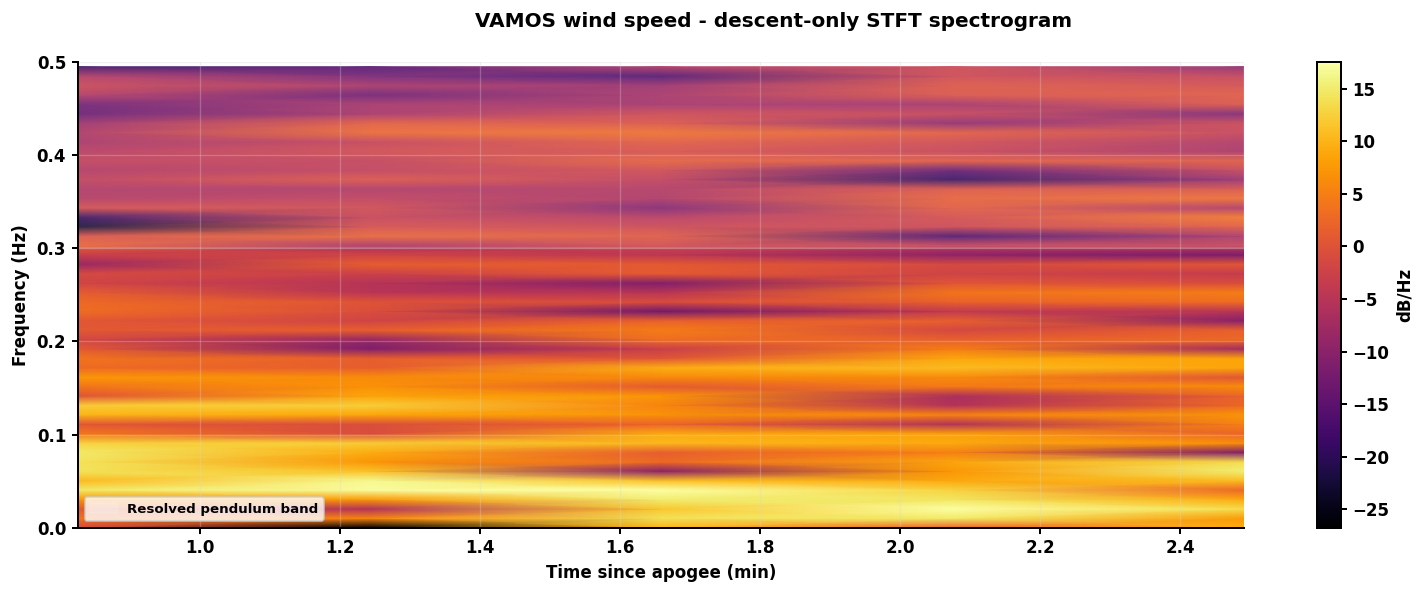

In [69]:
# ── 4.2 Wind STFT spectrogram ────────────────────────────────────────────────
_t_wu, _spd_wu = resample_uniform(wind_spec['t_rel'].values, wind_spec['wind_spd_vec'].values, FS_W)
_spd_wd = detrend_linear(_spd_wu, _t_wu)
NSTFT_W = min(128, max(32, len(_spd_wd) // 2))
NOLAP_W = min(NSTFT_W * 3 // 4, NSTFT_W - 1)

fs_s, ts_s, Zxx_s = _scipy_spectrogram(_spd_wd, fs=FS_W, nperseg=NSTFT_W, noverlap=NOLAP_W, window='hann')

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('VAMOS wind speed - descent-only STFT spectrogram', fontweight='bold')
im = ax.pcolormesh(ts_s/60, fs_s, 10*np.log10(np.abs(Zxx_s)+1e-30), shading='gouraud', cmap='inferno')
lo, hi = _resolved_band(FS_W)
if hi > lo:
    ax.axhspan(lo, hi, color='white', alpha=0.12, label='Resolved pendulum band')
ax.set(xlabel='Time since apogee (min)', ylabel='Frequency (Hz)', ylim=(0, FS_W/2))
plt.colorbar(im, ax=ax, label='dB/Hz')
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_wind_stft.png', strip_text=False)
plt.show()


Wind-direction sample rate ≈ 0.97 Hz; Nyquist ≈ 0.49 Hz (faster spin would alias).
 window  duration_s  net_turns  median_abs_yaw_deg_s  p95_abs_yaw_deg_s  peak_hz  peak_period_s
Descent     198.439     -0.101                  2.86             12.189    0.021           48.0


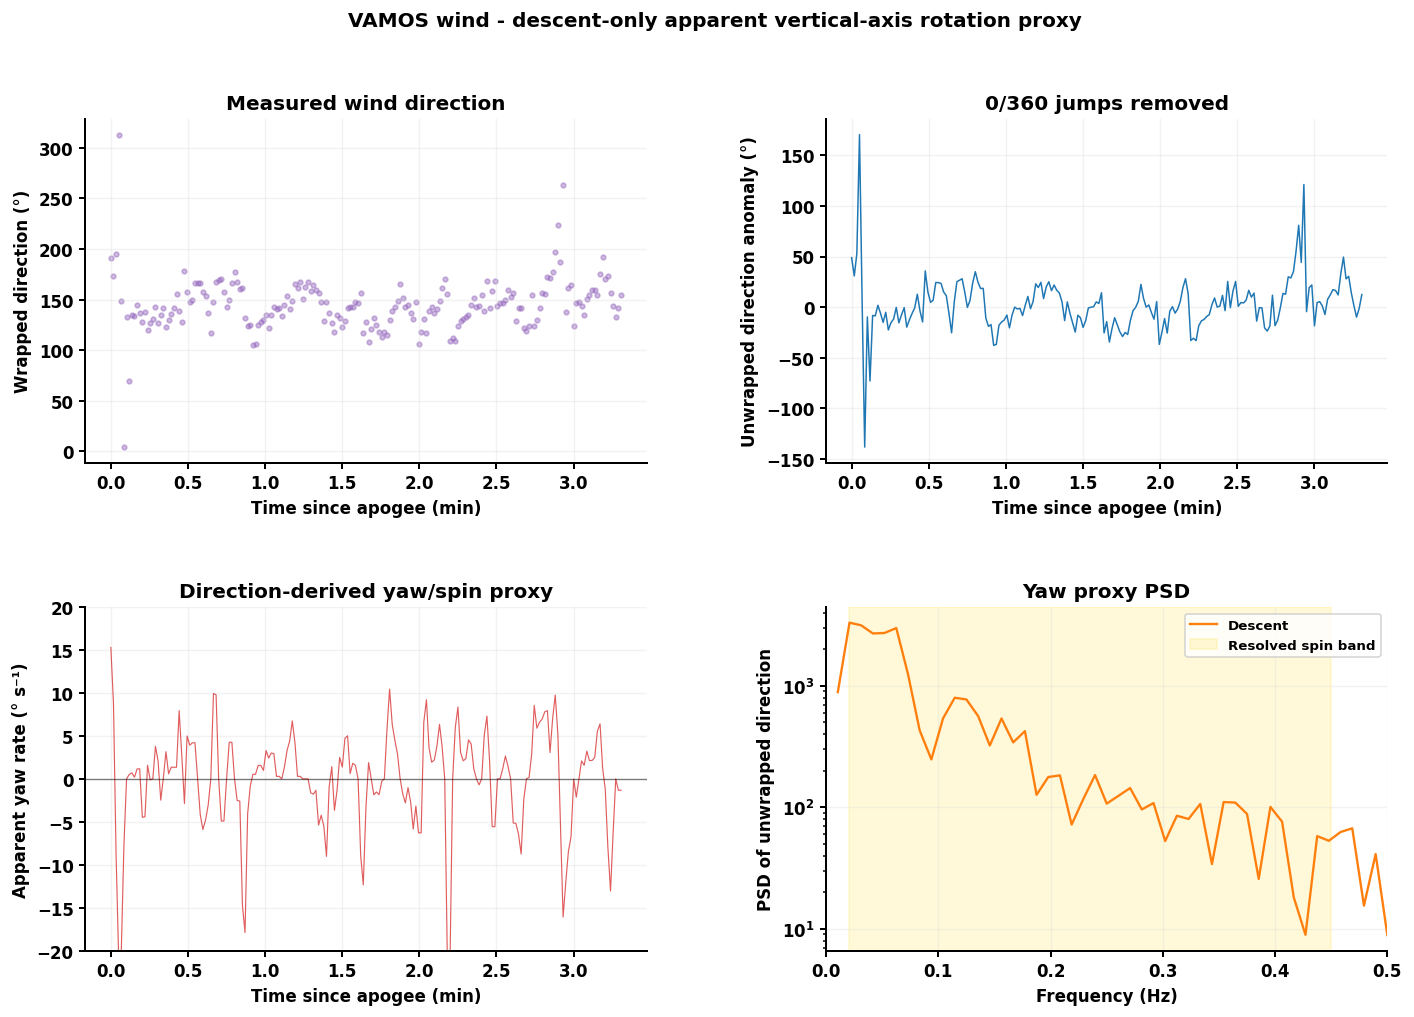

In [70]:
# ── 4.2 Apparent axial spin from wind direction ──────────────────────────────
YAW_FS = 1.0
NPERSEG_YAW = min(96, max(32, len(wind_spec) // 2))
_SPIN_BAND = (0.02, 0.45)  # resolved at the wind sensor sample rate

_yaw_fs_native = 1.0 / np.median(np.diff(wind['t_rel'].values))
_wind_yaw = wind_spec.dropna(subset=['wind_dir_unwrapped', 'yaw_rate_deg_s']).copy()

peak_hz = np.nan
peak_period_s = np.nan
if len(_wind_yaw) >= 64:
    f_yaw, psd_yaw, *_ = compute_welch_psd(
        _wind_yaw['t_rel'].values, _wind_yaw['wind_dir_unwrapped'].values,
        YAW_FS, NPERSEG_YAW,
    )
    band = (f_yaw >= _SPIN_BAND[0]) & (f_yaw <= min(_SPIN_BAND[1], YAW_FS / 2))
    if np.any(band):
        peak_idx = np.argmax(psd_yaw[band])
        peak_hz = float(f_yaw[band][peak_idx])
        peak_period_s = float(1.0 / peak_hz) if peak_hz > 0 else np.nan

_spin_stats = pd.DataFrame([{
    'window': 'Descent',
    'duration_s': _wind_yaw['t_rel'].iat[-1] - _wind_yaw['t_rel'].iat[0],
    'net_turns': (_wind_yaw['wind_dir_unwrapped'].iat[-1] - _wind_yaw['wind_dir_unwrapped'].iat[0]) / 360.0,
    'median_abs_yaw_deg_s': np.nanmedian(_wind_yaw['yaw_rate_deg_s'].abs().values),
    'p95_abs_yaw_deg_s': np.nanpercentile(_wind_yaw['yaw_rate_deg_s'].abs().values, 95),
    'peak_hz': peak_hz,
    'peak_period_s': peak_period_s,
}])
print(f'Wind-direction sample rate ≈ {_yaw_fs_native:.2f} Hz; Nyquist ≈ {_yaw_fs_native / 2:.2f} Hz (faster spin would alias).')
print(_spin_stats.round(3).to_string(index=False))

fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
fig.suptitle('VAMOS wind - descent-only apparent vertical-axis rotation proxy', fontweight='bold')

_twd_min = (wind_spec['t_s'].values - t_apo) / 60.0
ax = fig.add_subplot(gs[0, 0])
ax.scatter(_twd_min, wind_spec['wind_dir'], s=8, alpha=0.45, color='tab:purple')
ax.set(xlabel='Time since apogee (min)', ylabel='Wrapped direction (°)', title='Measured wind direction')

ax = fig.add_subplot(gs[0, 1])
_dir_anom = wind_spec['wind_dir_unwrapped'] - np.nanmedian(_wind_yaw['wind_dir_unwrapped'])
ax.plot(_twd_min, _dir_anom, lw=0.9, color='tab:blue')
ax.set(xlabel='Time since apogee (min)', ylabel='Unwrapped direction anomaly (°)', title='0/360 jumps removed')

ax = fig.add_subplot(gs[1, 0])
ax.plot(_twd_min, wind_spec['yaw_rate_deg_s'], lw=0.7, color='tab:red', alpha=0.75)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
_yaw_lim = np.nanpercentile(np.abs(_wind_yaw['yaw_rate_deg_s']), 98)
_yaw_lim = min(max(_yaw_lim, 20), 120)
ax.set_ylim(-_yaw_lim, _yaw_lim)
ax.set(xlabel='Time since apogee (min)', ylabel='Apparent yaw rate (° s⁻¹)', title='Direction-derived yaw/spin proxy')

ax = fig.add_subplot(gs[1, 1])
if len(_wind_yaw) >= 64:
    ax.semilogy(f_yaw[1:], psd_yaw[1:], label='Descent', color='tab:orange', lw=1.4)
ax.axvspan(_SPIN_BAND[0], min(_SPIN_BAND[1], YAW_FS / 2), color='gold', alpha=0.15, label='Resolved spin band')
ax.set(xlabel='Frequency (Hz)', ylabel='PSD of unwrapped direction', title='Yaw proxy PSD', xlim=(0, 0.5))
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'flight_dynamics/fig_wind_axial_spin.png', strip_text=False)
plt.show()


#### Results - VAMOS wind

The wind PSD, STFT, and direction-derived yaw proxy now use only the detected VAMOS descent window.  This avoids diluting the parachute dynamics with aircraft vibration before release or sensor floor noise after landing.

Within the resolved VAMOS wind band (≈0.3-0.5 Hz), the descent window does not show a narrow peak above the local background in wind speed or wind acceleration. The STFT likewise shows no persistent low-frequency periodic component through the drop. Faster 0.5-1.0 Hz pendulum/spin motion would be above Nyquist for this sensor and could alias.

The wind-direction yaw proxy adds one important caveat: the descent window shows a slow apparent rotation/drift of the measured bearing, with its strongest resolved component at a period of tens of seconds, not a fast spin peak. Because this is derived from `wind_dir` alone, it may mix real wind-direction variability, wind shear, and payload yaw around the vertical axis.

**Conclusion:** No evidence of a persistent resolved parachute pendulum oscillation or fast axial spin in the VAMOS wind data during descent. Absolute wind direction should still be treated cautiously because slow CanSat yaw could bias the measured bearing.


### 4.3 ScamSat - Acceleration and Temperature

The **acceleration channel** is the most direct indicator of mechanical oscillations. ScamSat has its own altitude-derived descent window, so acceleration and temperature spectra are computed only from maximum altitude -> near-ground return.


In [71]:
# ── 4.3 ScamSat: estimate sample rates inside detected descent ──────────────
def _fs(df, col_t='t_s'):
    t = df[col_t].values
    return (len(t) - 1) / (t[-1] - t[0])

fs_accel = _fs(scam_accel_spec)
fs_temp_s = _fs(scam_temp_spec)
FS_SA = max(1.0, round(fs_accel))
FS_ST = max(1.0, round(fs_temp_s))
print(f'ScamSat detected descent: {scam_t_apo:.0f}-{scam_t_land:.0f} s | duration {scam_t_land - scam_t_apo:.0f} s | peak {scam_drop["h_peak_m"]:.0f} m AGL')
print(f'ScamSat accel descent: {len(scam_accel_spec):5d} samples | fs ≈ {fs_accel:.2f} Hz → using {FS_SA} Hz')
print(f'ScamSat temp descent:  {len(scam_temp_spec):5d} samples | fs ≈ {fs_temp_s:.2f} Hz → using {FS_ST} Hz')

# Resample. Spectra use raw detrended descent signals; low-pass copies are for display/profile plots.
_ta_u, _aa_u = resample_uniform(scam_accel_spec['t_s'].values, scam_accel_spec['accel_g'].values, FS_SA)
_aa_f = butter_lowpass(_aa_u, cutoff_hz=min(0.4, FS_SA*0.4), fs=FS_SA, order=4)
_aa_d = detrend_linear(_aa_u, _ta_u)

_tt_u, _aT_u = resample_uniform(scam_temp_spec['t_s'].values, scam_temp_spec['temp_C'].values, FS_ST)
_aT_f = butter_lowpass(_aT_u, cutoff_hz=min(0.3, FS_ST*0.4), fs=FS_ST, order=4)
_aT_d = detrend_linear(_aT_u, _tt_u)


ScamSat detected descent: 828-996 s | duration 168 s | peak 661 m AGL
ScamSat accel descent:  4712 samples | fs ≈ 28.05 Hz → using 28 Hz
ScamSat temp descent:    829 samples | fs ≈ 4.93 Hz → using 5 Hz


 window       signal resolved_band_hz  peak_hz  peak_to_background
Descent Acceleration        0.30-1.00    0.536               0.811
Descent  Temperature        0.30-1.00    0.383               0.220


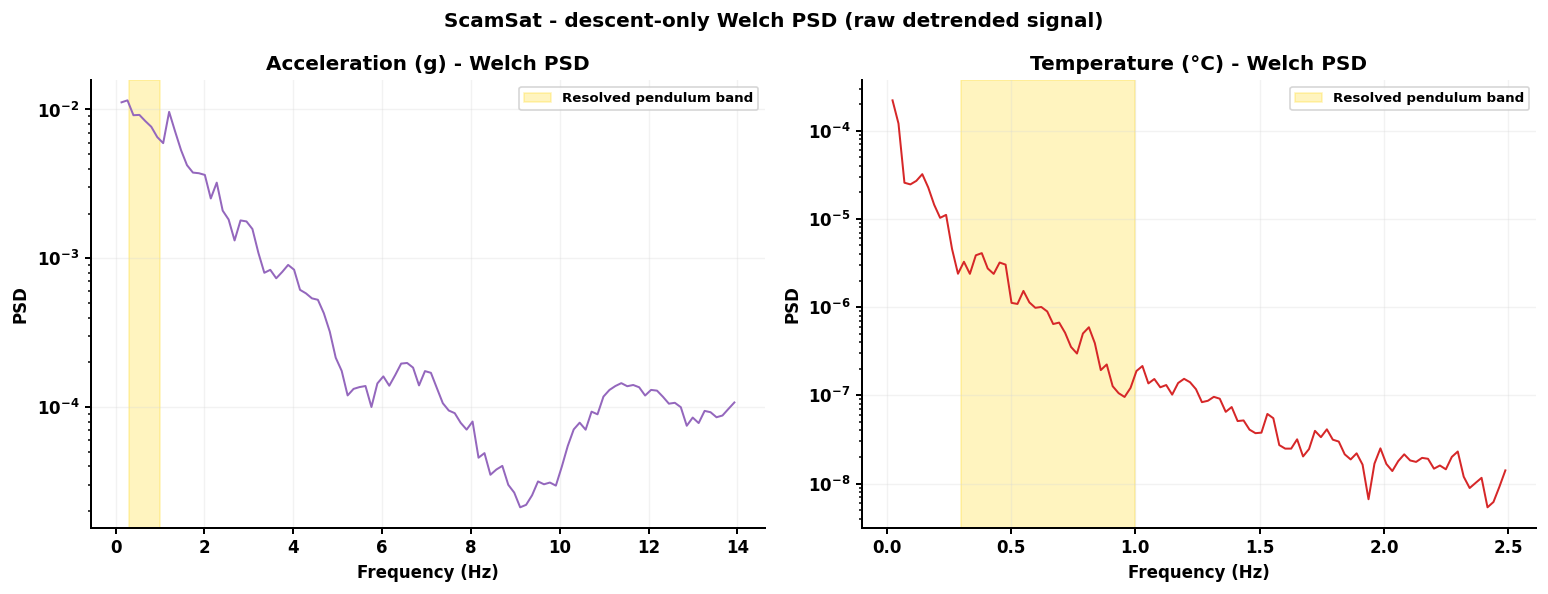

In [72]:
# ── 4.3 Welch PSD ────────────────────────────────────────────────────────────
NPERSEG_S = min(256, len(_aa_d) // 4, len(_aT_d) // 4)

fw_a, psd_a, *_ = compute_welch_psd(_ta_u, _aa_d, FS_SA, NPERSEG_S)
fw_t, psd_t, *_ = compute_welch_psd(_tt_u, _aT_d, FS_ST, NPERSEG_S)

_scam_peak_stats = []
for signal, fw, psd, fs in [
    ('Acceleration', fw_a, psd_a, FS_SA),
    ('Temperature', fw_t, psd_t, FS_ST),
]:
    report = _band_peak_report(fw, psd, fs)
    report.update({'window': 'Descent', 'signal': signal})
    _scam_peak_stats.append(report)
_scam_peak_stats = pd.DataFrame(_scam_peak_stats)
print(_scam_peak_stats[['window', 'signal', 'resolved_band_hz', 'peak_hz', 'peak_to_background']].round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ScamSat - descent-only Welch PSD (raw detrended signal)', fontweight='bold')
for ax, (fw, psd, lbl, col, fs_use) in zip(axes, [
    (fw_a, psd_a, 'Acceleration (g)', 'tab:purple', FS_SA),
    (fw_t, psd_t, 'Temperature (°C)', 'tab:red', FS_ST),
]):
    ax.semilogy(fw[1:], psd[1:], color=col, lw=1.2)
    _shade_resolved_band(ax, fs_use)
    ax.set(xlabel='Frequency (Hz)', ylabel='PSD', title=f'{lbl} - Welch PSD')
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_psd.png', strip_text=False)
plt.show()


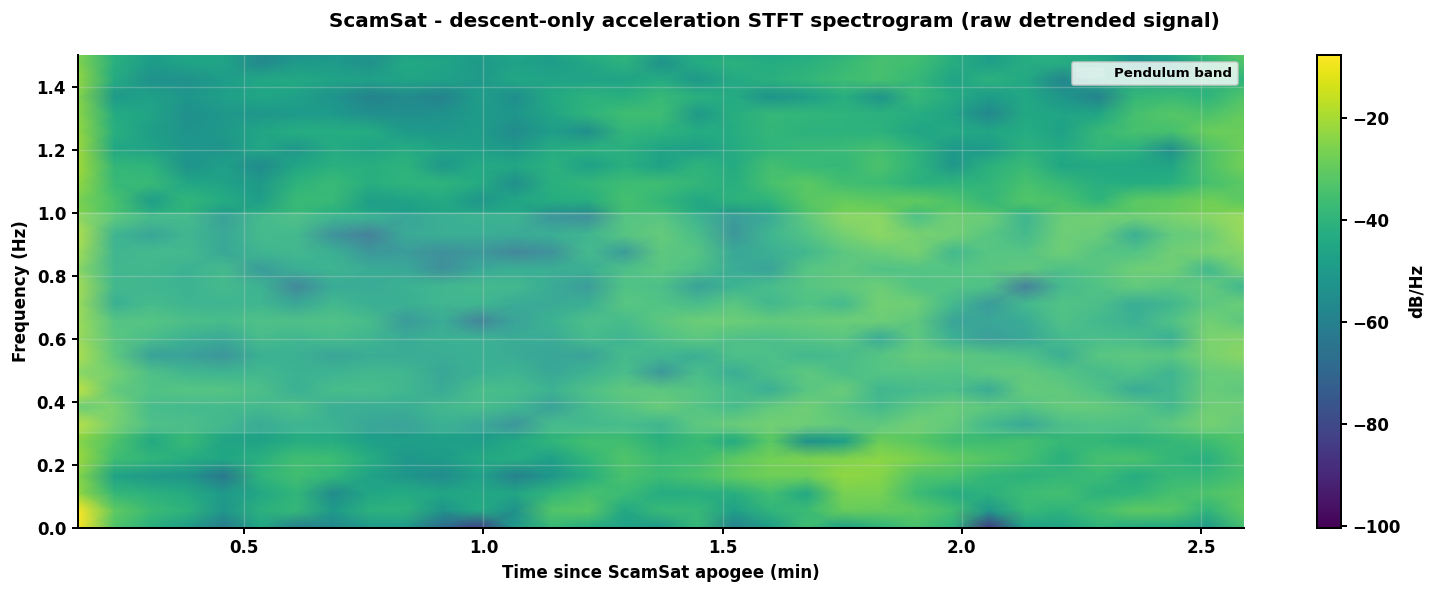

In [73]:
# ── 4.3 STFT spectrogram - acceleration ──────────────────────────────────────
NSTFT_S = min(512, len(_aa_d) // 4)
fs_s2, ts_s2, Zxx_s2 = _scipy_spectrogram(
    _aa_d, fs=float(FS_SA), nperseg=NSTFT_S, noverlap=NSTFT_S*3//4, window='hann')

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('ScamSat - descent-only acceleration STFT spectrogram (raw detrended signal)', fontweight='bold')
im = ax.pcolormesh(ts_s2/60, fs_s2, 10*np.log10(np.abs(Zxx_s2)+1e-30), shading='gouraud', cmap='viridis')
lo, hi = _resolved_band(FS_SA)
if hi > lo:
    ax.axhspan(lo, hi, color='white', alpha=0.12, label='Pendulum band')
ax.set(xlabel='Time since ScamSat apogee (min)', ylabel='Frequency (Hz)', ylim=(0, min(1.5, float(FS_SA)/2)))
plt.colorbar(im, ax=ax, label='dB/Hz')
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_stft.png', strip_text=False)
plt.show()


#### Results - ScamSat

ScamSat acceleration resolves the full 0.3-1.0 Hz pendulum band, and the spectra above are computed only on the altitude-detected descent window. The strongest acceleration bin sits near the low edge of the band, but its peak-to-background ratio is close to unity rather than a clear narrow resonance. The STFT also does not show a persistent line through the descent window.

**Conclusion:** ScamSat does not provide robust evidence for a sustained parachute pendulum resonance during descent. Any mechanical excitation appears broadband or weak rather than a stable narrow-band oscillation.


### 4.4 Summary and Final Processed Signals

| Dataset | Signal | Pendulum peak found? | Action |
|---------|--------|---------------------|--------|
| VAMOS science | Pressure | No resolved 0.3-0.5 Hz descent peak | Use LP-filtered copy for profile analysis |
| VAMOS science | Temperature | No resolved 0.3-0.5 Hz descent peak | Use LP-filtered copy for profile analysis |
| VAMOS wind | Wind speed/acceleration/direction | No resolved narrow descent peak; slow yaw possible | Use speed profile; treat direction as potentially yaw-contaminated |
| ScamSat | Acceleration | No significant narrow 0.3-1.0 Hz descent peak | Use as mechanical cross-check |
| ScamSat | Temperature | No significant narrow 0.3-1.0 Hz descent peak | Use LP-filtered copy |

The LP-filtered signals (trend preserved) are used in §5 for atmospheric analysis; spectral conclusions are based on raw detrended signals from the detected descent windows only.


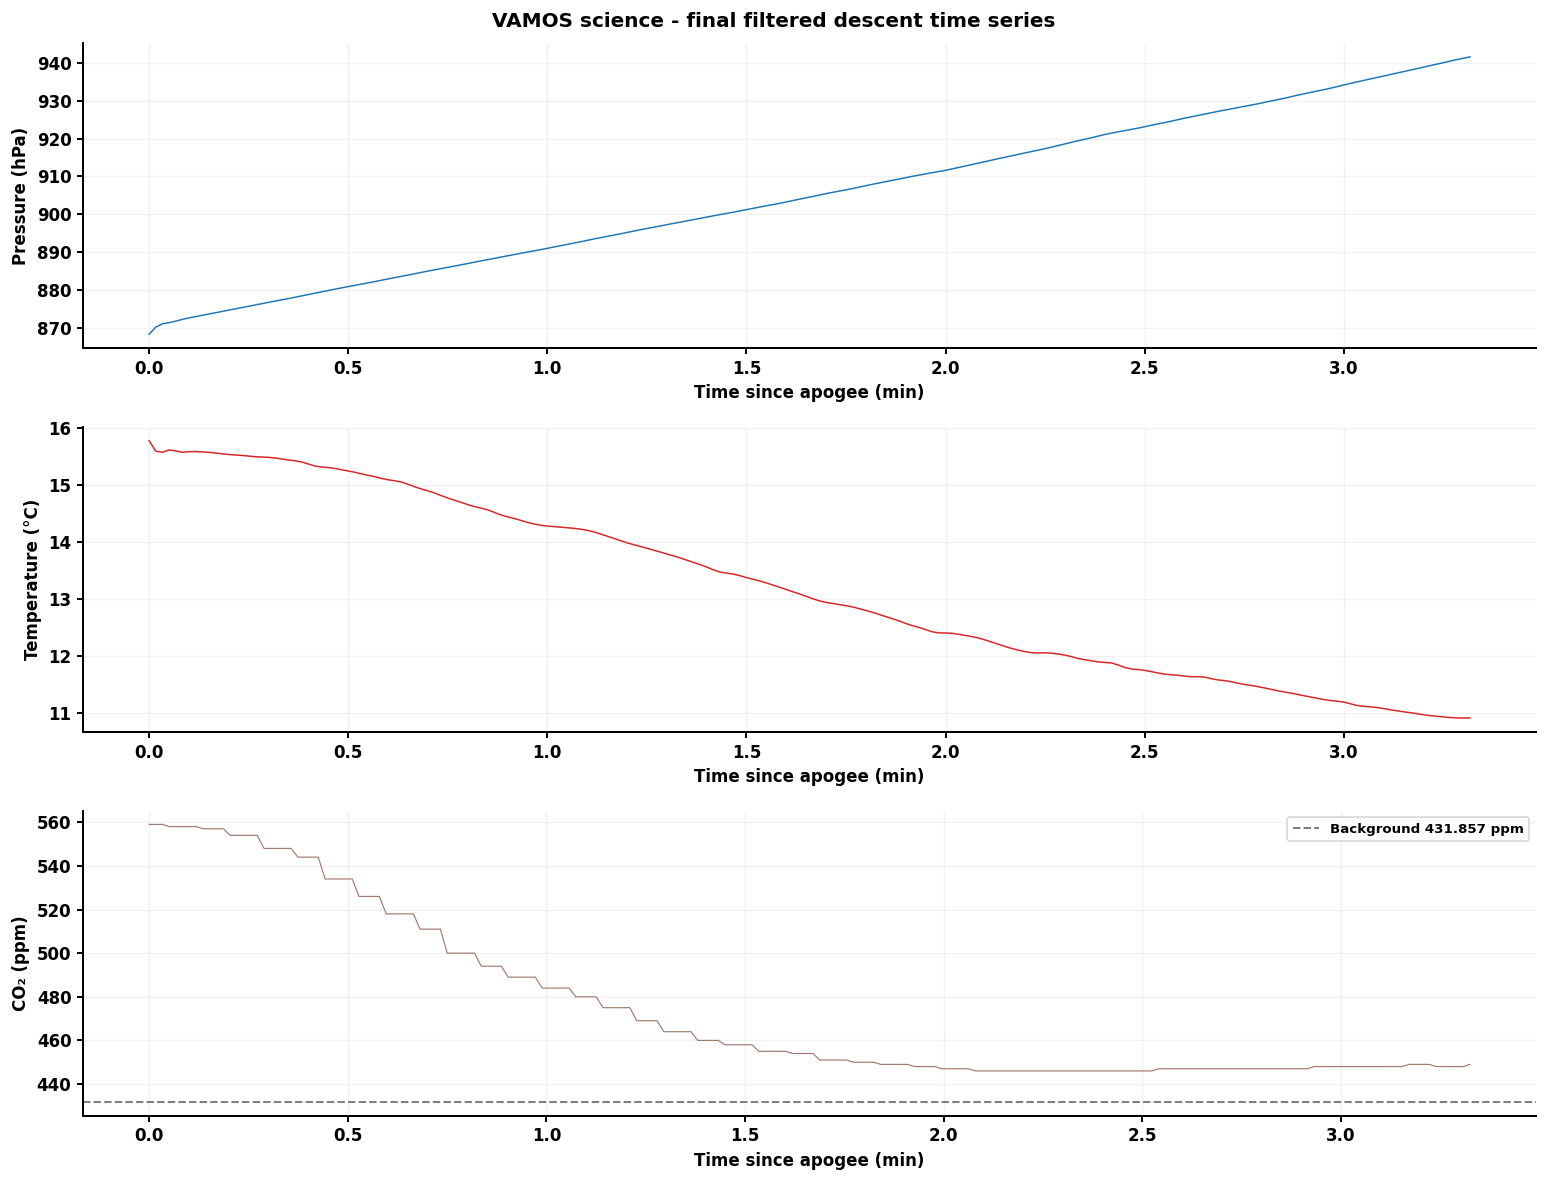

In [74]:
# ── 4.4 Final filtered signals - VAMOS ───────────────────────────────────────
_apo_mf = (t_apo - vamos['t_s'].iat[0]) / 60
_land_mf = (t_land - vamos['t_s'].iat[0]) / 60
_vamos_co2_spec = _slice_time(vamos_co2, t_apo, t_land)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)
fig.suptitle('VAMOS science - final filtered descent time series', fontweight='bold')

for ax, (sig, ylabel, col) in zip(axes[:2], [
    (p_vf / 100, 'Pressure (hPa)', 'tab:blue'),
    (T_vf, 'Temperature (°C)', 'tab:red'),
]):
    ax.plot(_t_vu_min, sig, lw=0.9, color=col)
    ax.set(xlabel='Time since apogee (min)', ylabel=ylabel)

_co2_td = (_vamos_co2_spec['t_s'].values - t_apo) / 60
axes[2].plot(_co2_td, _vamos_co2_spec['co2_ppm'].values, lw=0.7, color='tab:brown', alpha=0.8)
axes[2].axhline(CO2_BACKGROUND_PPM, ls='--', color='gray', lw=1.2, label=f'Background {CO2_BACKGROUND_PPM} ppm')
axes[2].set(ylabel='CO₂ (ppm)', xlabel='Time since apogee (min)')
axes[2].legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_final.png', strip_text=False)
plt.show()


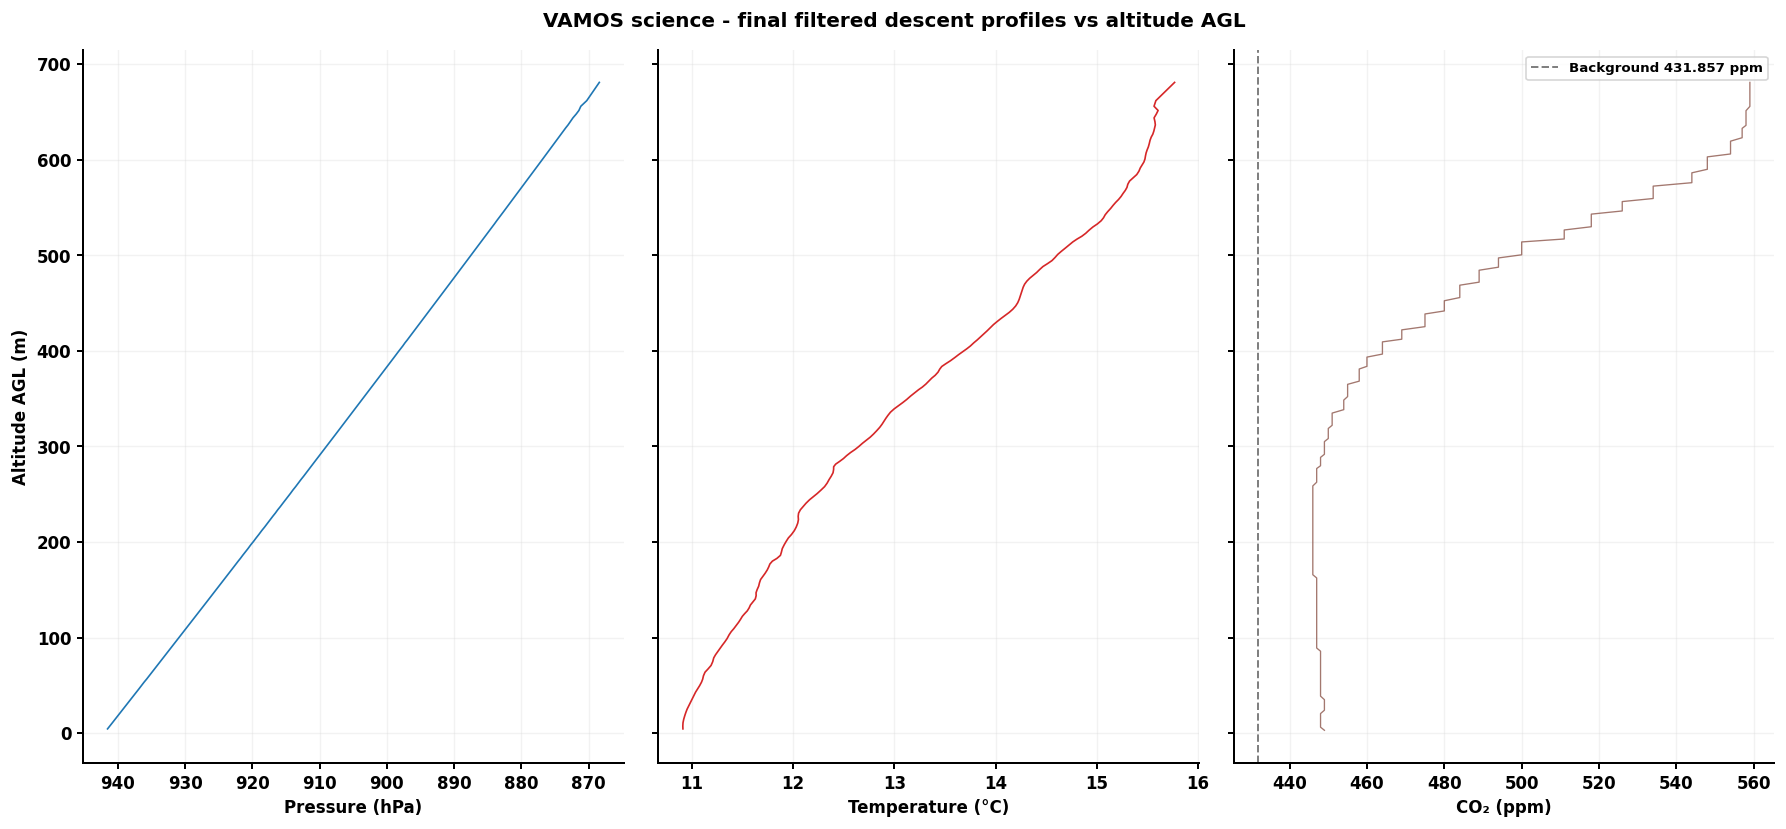

In [75]:
# ── 4.4 Final filtered signals - VAMOS vs altitude AGL ──────────────────────
# Interpolate h_agl from full vamos t_rel to the resampled descent grid
_h_vu = np.interp(t_vu, vamos["t_rel"].values, vamos_drop["h_agl"])
_h_co2_alt = np.interp(
    _vamos_co2_spec["t_rel"].values, vamos["t_rel"].values, vamos_drop["h_agl"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig.suptitle('VAMOS science - final filtered descent profiles vs altitude AGL', fontweight='bold')

axes[0].plot(p_vf / 100, _h_vu, lw=1.0, color='tab:blue')
axes[0].set(xlabel='Pressure (hPa)', ylabel='Altitude AGL (m)')
axes[0].invert_xaxis()

axes[1].plot(T_vf, _h_vu, lw=1.0, color='tab:red')
axes[1].set(xlabel='Temperature (°C)')

axes[2].plot(_vamos_co2_spec['co2_ppm'].values, _h_co2_alt, lw=0.8, color='tab:brown', alpha=0.8)
axes[2].axvline(CO2_BACKGROUND_PPM, ls='--', color='gray', lw=1.2,
               label=f'Background {CO2_BACKGROUND_PPM} ppm')
axes[2].set(xlabel='CO₂ (ppm)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_final_altitude.png', strip_text=False)
plt.show()


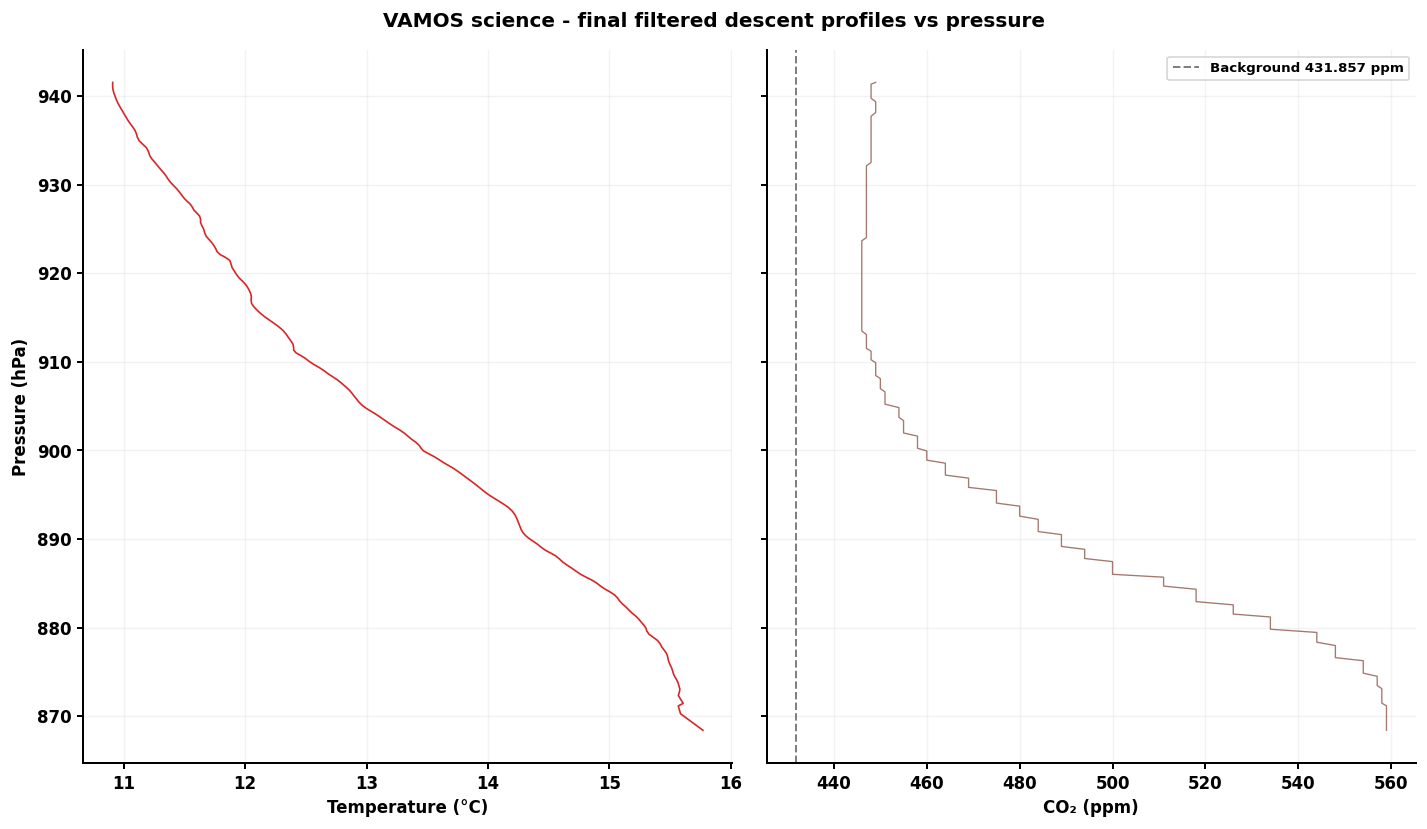

In [76]:
# ── 4.4 Final filtered signals - VAMOS vs pressure ──────────────────────────
# p_vf and T_vf already share the same uniform time grid t_vu;
# interpolate pressure to the CO2 timestamps
_p_co2_hpa = np.interp(_vamos_co2_spec["t_rel"].values, t_vu, p_vf / 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle('VAMOS science - final filtered descent profiles vs pressure', fontweight='bold')

axes[0].plot(T_vf, p_vf / 100, lw=1.0, color='tab:red')
axes[0].set(xlabel='Temperature (°C)', ylabel='Pressure (hPa)')
axes[0].invert_yaxis()

axes[1].plot(_vamos_co2_spec['co2_ppm'].values, _p_co2_hpa, lw=0.8, color='tab:brown', alpha=0.8)
axes[1].axvline(CO2_BACKGROUND_PPM, ls='--', color='gray', lw=1.2,
               label=f'Background {CO2_BACKGROUND_PPM} ppm')
axes[1].set(xlabel='CO₂ (ppm)')
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_vamos_final_pressure.png', strip_text=False)
plt.show()


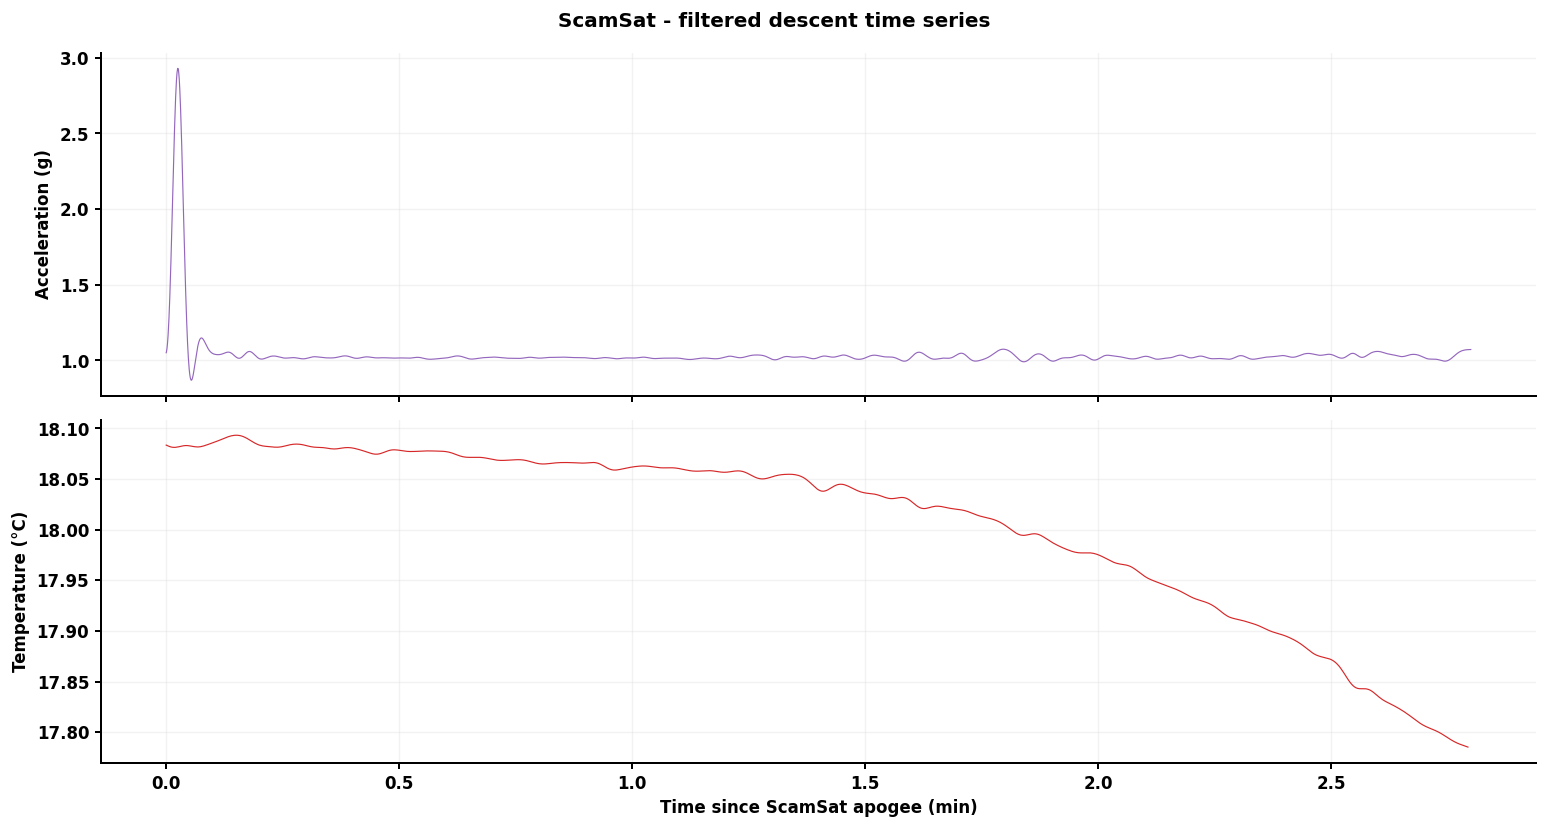

In [77]:
# ── 4.4 Final filtered signals - ScamSat ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('ScamSat - filtered descent time series', fontweight='bold')
axes[0].plot((_ta_u - _ta_u[0]) / 60, _aa_f, lw=0.7, color='tab:purple')
axes[0].set_ylabel('Acceleration (g)')
axes[1].plot((_tt_u - _tt_u[0]) / 60, _aT_f, lw=0.7, color='tab:red')
axes[1].set(ylabel='Temperature (°C)', xlabel='Time since ScamSat apogee (min)')
plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_final.png', strip_text=False)
plt.show()


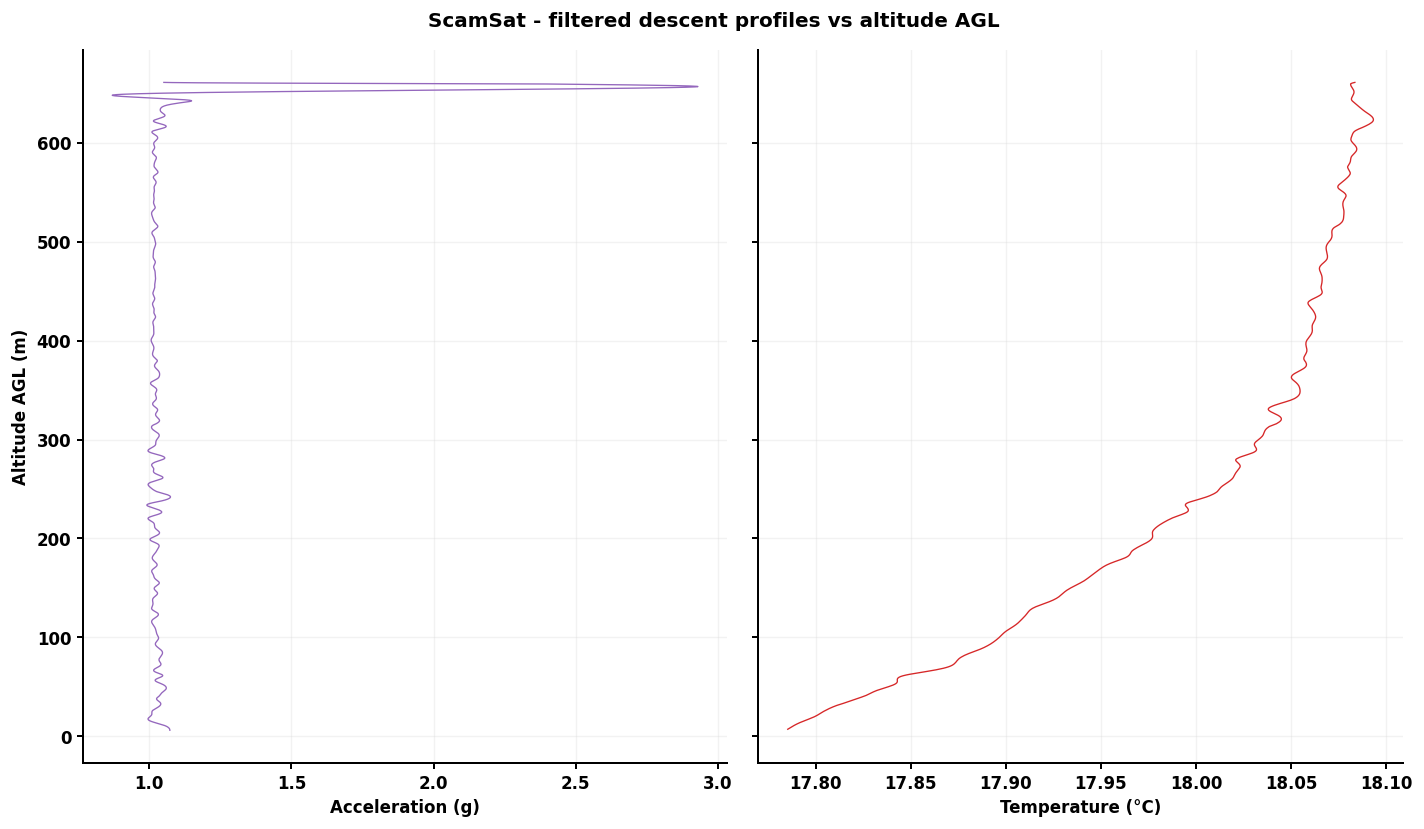

In [78]:
# ── 4.4 Final filtered signals - ScamSat vs altitude AGL ─────────────────────
_h_accel_s = np.interp(
    _ta_u, scam_alt_spec['t_s'].values, scam_alt_spec['altitude_agl_m'].values
)
_h_temp_s = np.interp(
    _tt_u, scam_alt_spec['t_s'].values, scam_alt_spec['altitude_agl_m'].values
)

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle('ScamSat - filtered descent profiles vs altitude AGL', fontweight='bold')

axes[0].plot(_aa_f, _h_accel_s, lw=0.8, color='tab:purple')
axes[0].set(xlabel='Acceleration (g)', ylabel='Altitude AGL (m)')

axes[1].plot(_aT_f, _h_temp_s, lw=0.8, color='tab:red')
axes[1].set(xlabel='Temperature (°C)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_final_altitude.png', strip_text=False)
plt.show()


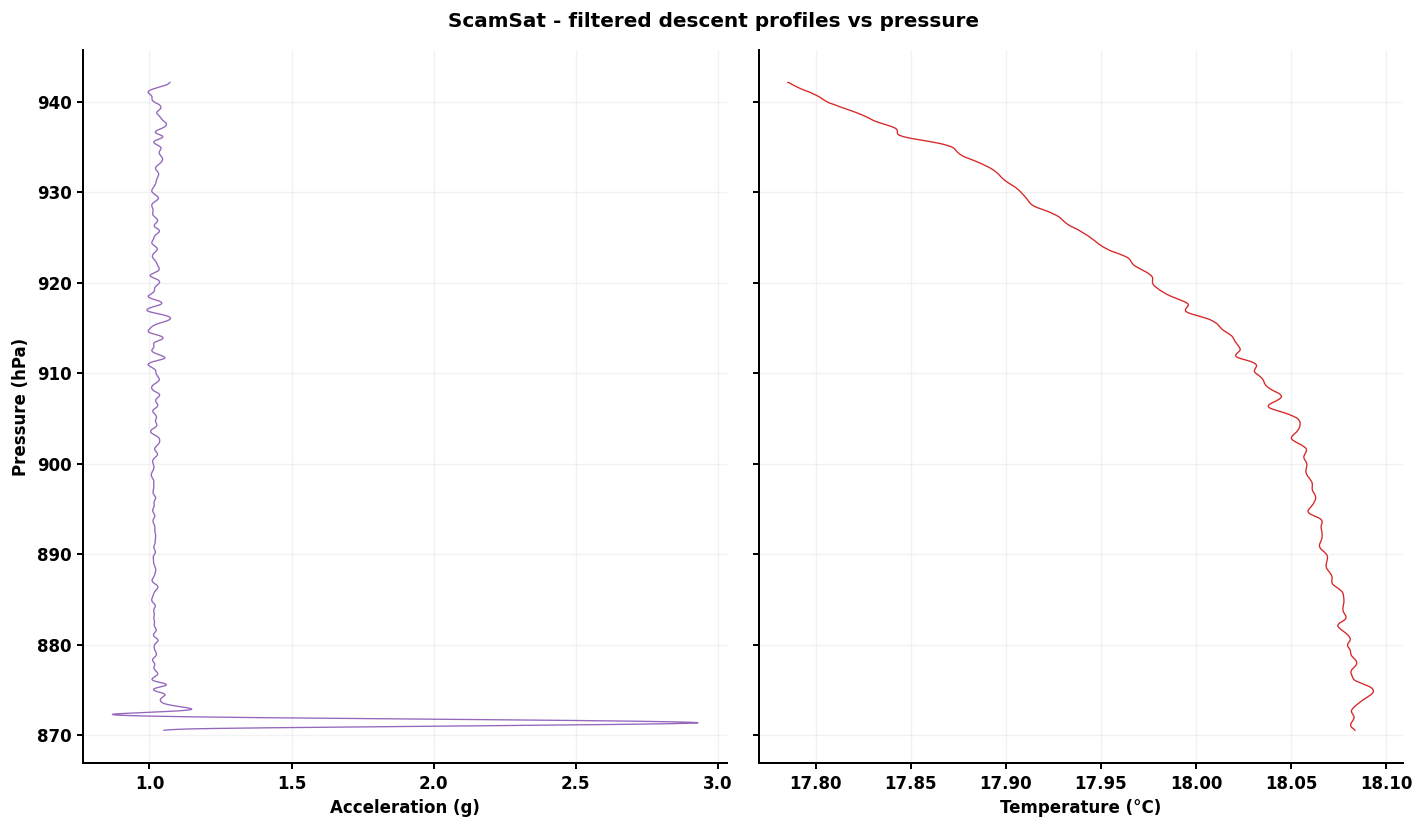

In [79]:
# ── 4.4 Final filtered signals - ScamSat vs pressure ─────────────────────────
_scam_press_spec = scam_press[scam_press['t_s'].between(scam_t_apo, scam_t_land)].copy()
_p_accel_pa = np.interp(
    _ta_u, _scam_press_spec['t_s'].values, _scam_press_spec['press_Pa'].values
)
_p_temp_s_pa = np.interp(
    _tt_u, _scam_press_spec['t_s'].values, _scam_press_spec['press_Pa'].values
)

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle('ScamSat - filtered descent profiles vs pressure', fontweight='bold')

axes[0].plot(_aa_f, _p_accel_pa / 100, lw=0.8, color='tab:purple')
axes[0].set(xlabel='Acceleration (g)', ylabel='Pressure (hPa)')
axes[0].invert_yaxis()

axes[1].plot(_aT_f, _p_temp_s_pa / 100, lw=0.8, color='tab:red')
axes[1].set(xlabel='Temperature (°C)')
axes[1].invert_yaxis()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_final_pressure.png', strip_text=False)
plt.show()


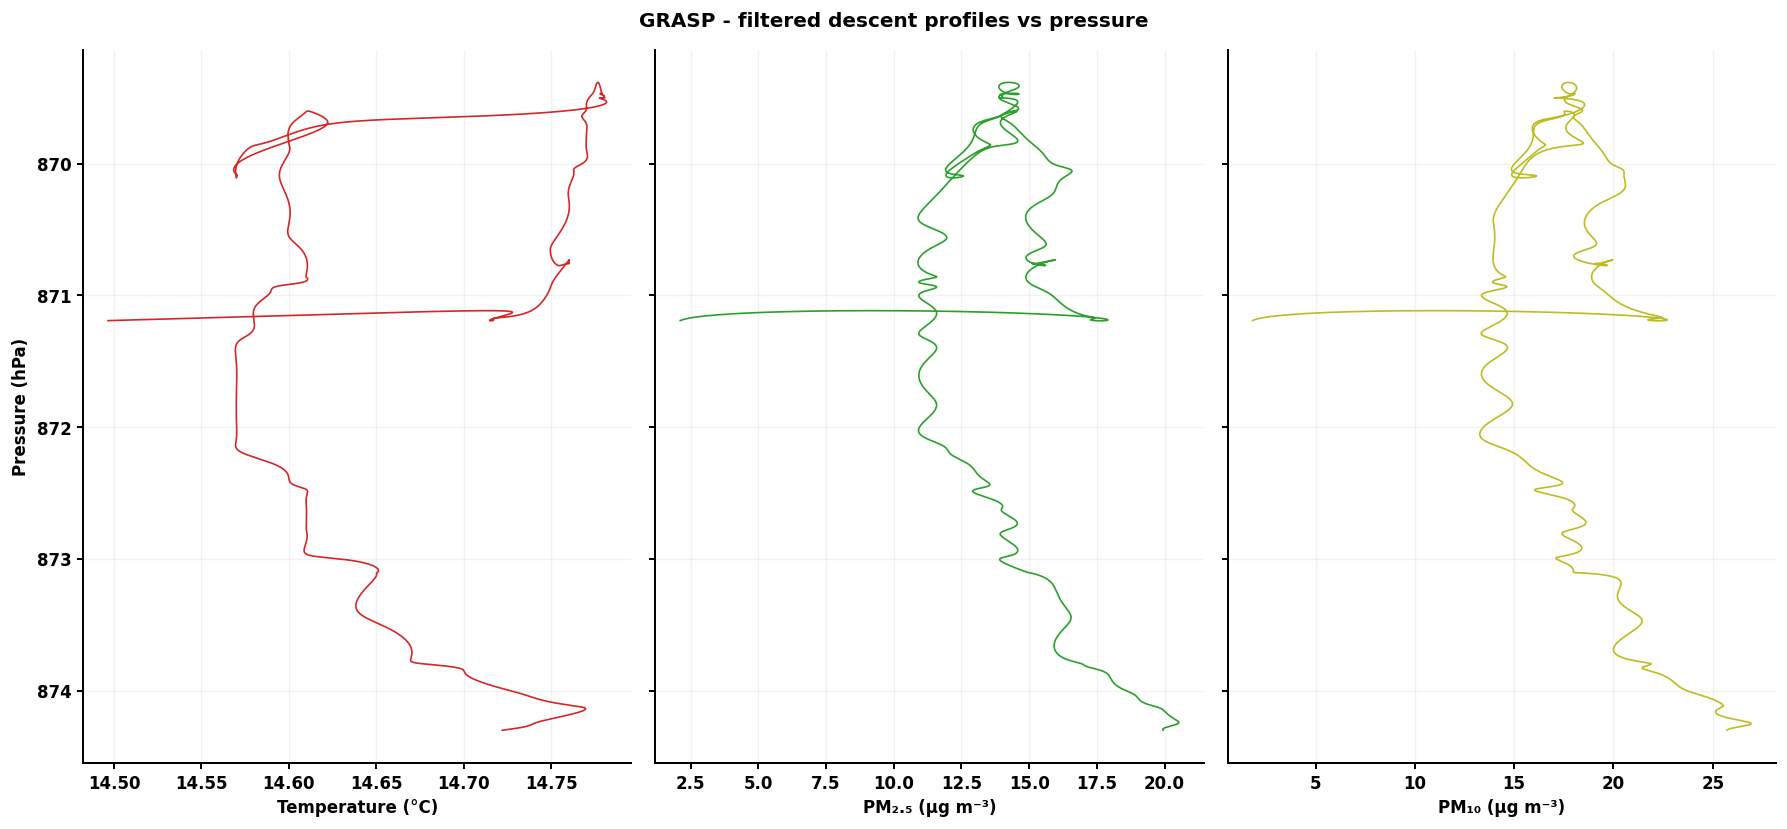

In [80]:
# ── 4.4 GRASP - all channels vs pressure ────────────────────────────────────
# GRASP data is entirely during descent; apply low-pass before plotting.
_cutoff_g = min(0.3, FS_G * 0.45)
_t_gu2, _p_gu2   = resample_uniform(grasp_clean["t_rel"].values, grasp_clean["press_Pa"].values,  FS_G)
_,      _T_gu2   = resample_uniform(grasp_clean["t_rel"].values, grasp_clean["temp_C"].values,    FS_G)
_,      _pm25_gu = resample_uniform(grasp_clean["t_rel"].values, grasp_clean["pm25"].values,      FS_G)
_,      _pm10_gu = resample_uniform(grasp_clean["t_rel"].values, grasp_clean["pm10"].values,      FS_G)

_p_gf2    = butter_lowpass(_p_gu2,   _cutoff_g, FS_G, order=4)
_T_gf2    = butter_lowpass(_T_gu2,   _cutoff_g, FS_G, order=4)
_pm25_gf2 = butter_lowpass(_pm25_gu, _cutoff_g, FS_G, order=4)
_pm10_gf2 = butter_lowpass(_pm10_gu, _cutoff_g, FS_G, order=4)

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig.suptitle('GRASP - filtered descent profiles vs pressure', fontweight='bold')

axes[0].plot(_T_gf2,    _p_gf2 / 100, lw=1.0, color='tab:red')
axes[0].set(xlabel='Temperature (°C)', ylabel='Pressure (hPa)')
axes[0].invert_yaxis()

axes[1].plot(_pm25_gf2, _p_gf2 / 100, lw=1.0, color='tab:green')
axes[1].set(xlabel='PM₂.₅ (µg m⁻³)')

axes[2].plot(_pm10_gf2, _p_gf2 / 100, lw=1.0, color='tab:olive')
axes[2].set(xlabel='PM₁₀ (µg m⁻³)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_grasp_vs_pressure.png', strip_text=False)
plt.show()


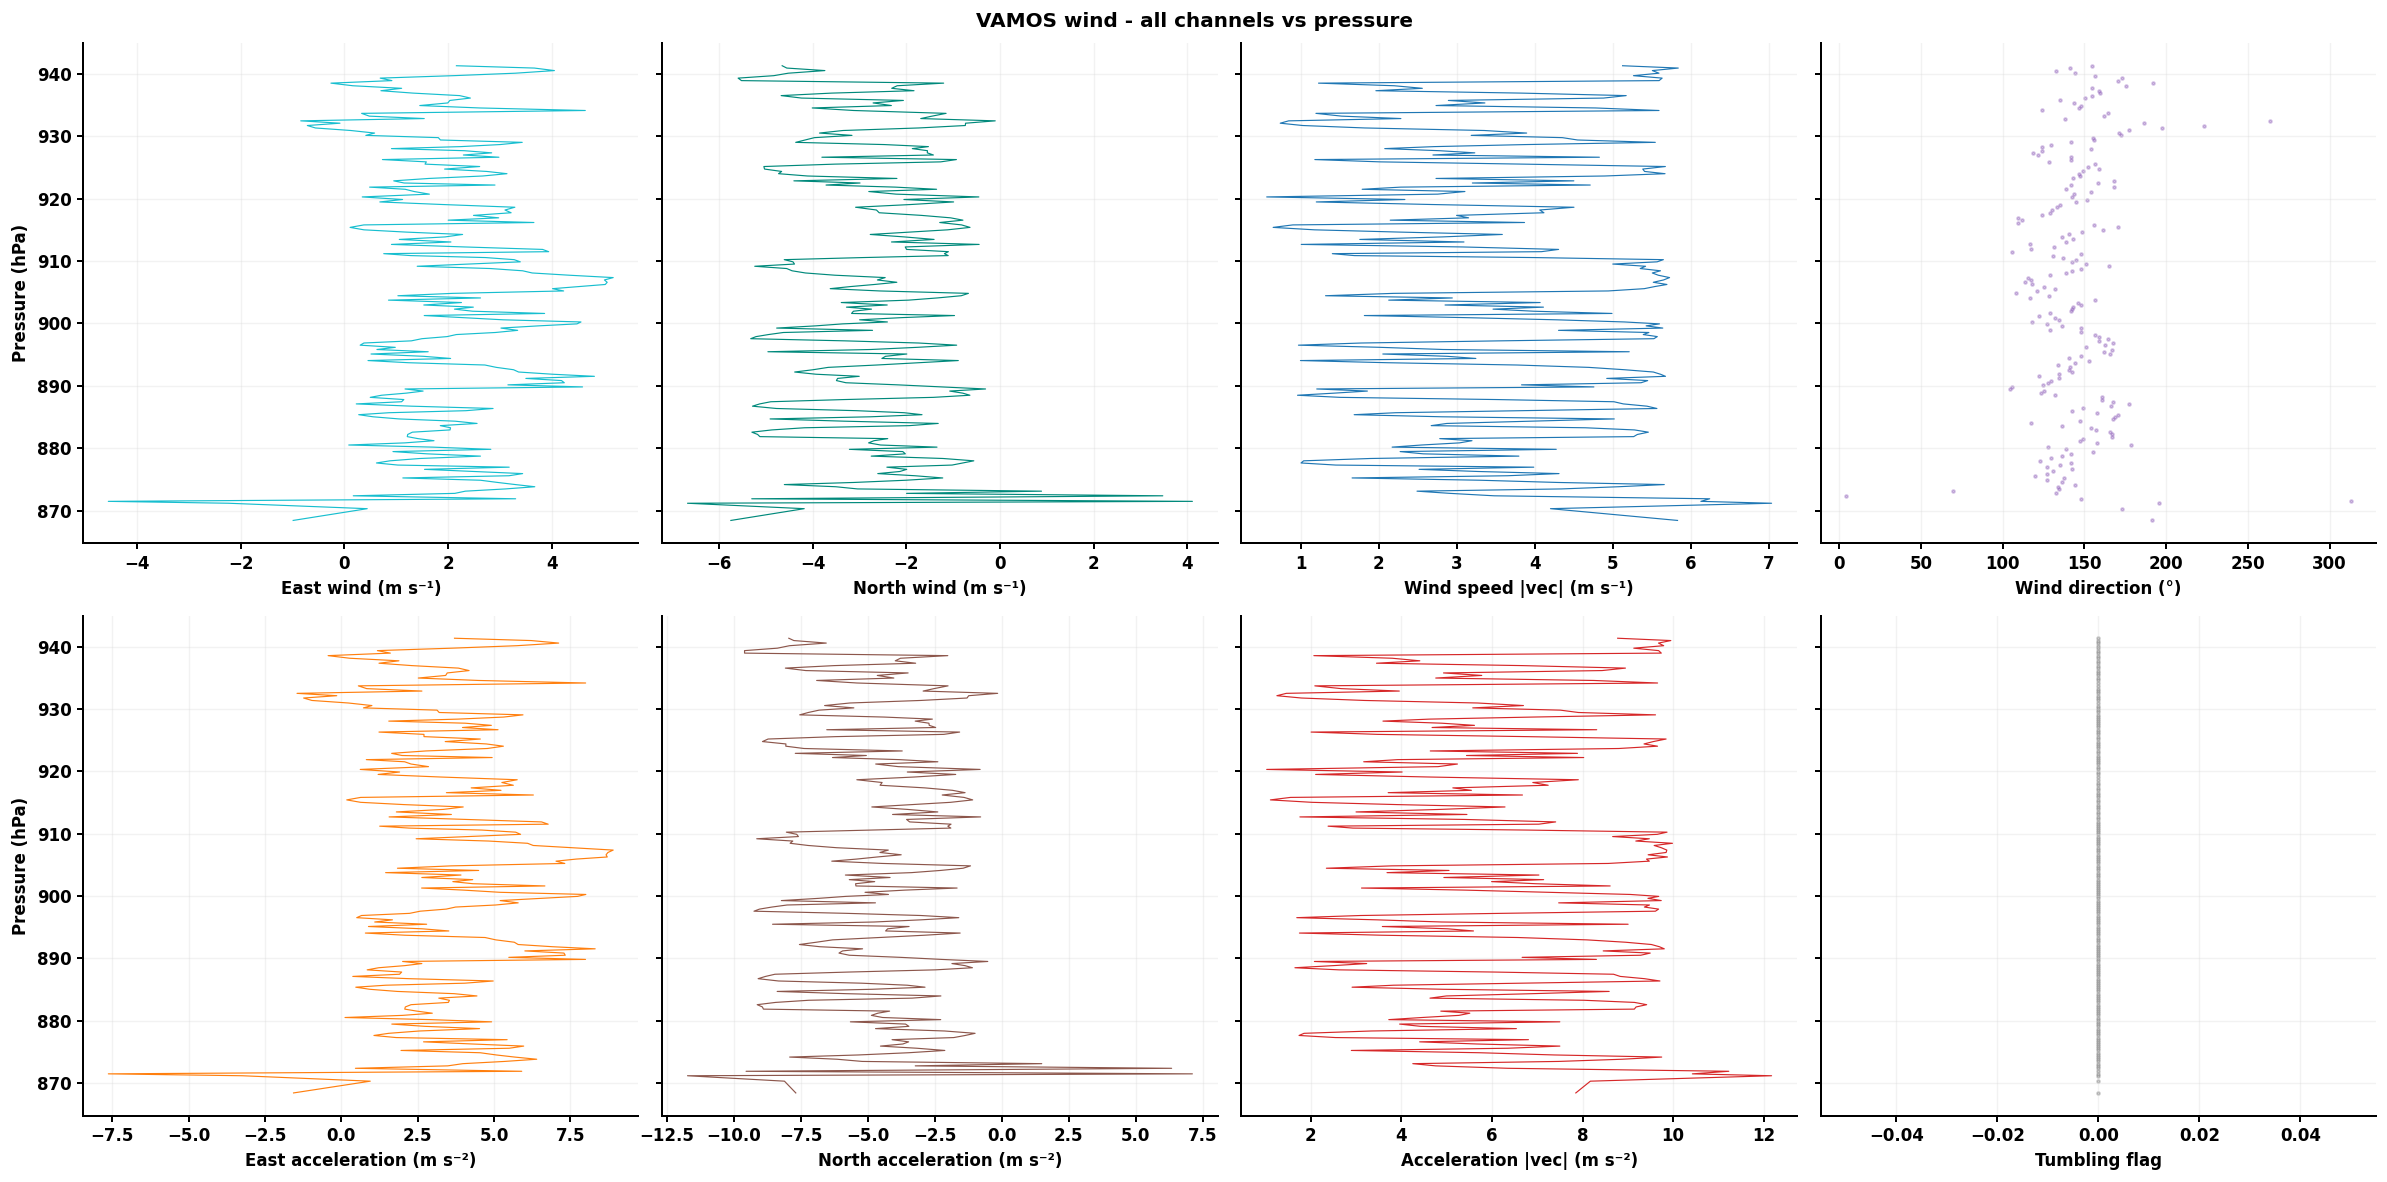

In [81]:
# ── 4.4 VAMOS wind - all channels vs pressure ────────────────────────────────
_p_wind_hpa = np.interp(
    wind_spec['t_rel'].values, t_vu, p_vf / 100
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
fig.suptitle('VAMOS wind - all channels vs pressure', fontweight='bold')

_panels = [
    # (col, xlabel, color, scatter)
    ('x_mps',        'East wind (m s⁻¹)',          'tab:cyan',   False),
    ('y_mps',        'North wind (m s⁻¹)',          '#00897B',   False),
    ('wind_spd_vec', 'Wind speed |vec| (m s⁻¹)',    'tab:blue',   False),
    ('wind_dir',     'Wind direction (°)',           'tab:purple', True),
    ('x_acc',        'East acceleration (m s⁻²)',   'tab:orange', False),
    ('y_acc',        'North acceleration (m s⁻²)',  'tab:brown',  False),
    ('wind_acc_vec', 'Acceleration |vec| (m s⁻²)',  'tab:red',    False),
    ('tumbling',     'Tumbling flag',                'tab:gray',   True),
]

for ax, (col, xlabel, color, scatter) in zip(axes.flat, _panels):
    vals = wind_spec[col].values
    if scatter:
        ax.scatter(vals, _p_wind_hpa, s=3, alpha=0.4, color=color)
    else:
        ax.plot(vals, _p_wind_hpa, lw=0.7, color=color)
    ax.set(xlabel=xlabel)
    ax.grid(True, alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel('Pressure (hPa)')
    ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_wind_vs_pressure.png', strip_text=False)
plt.show()


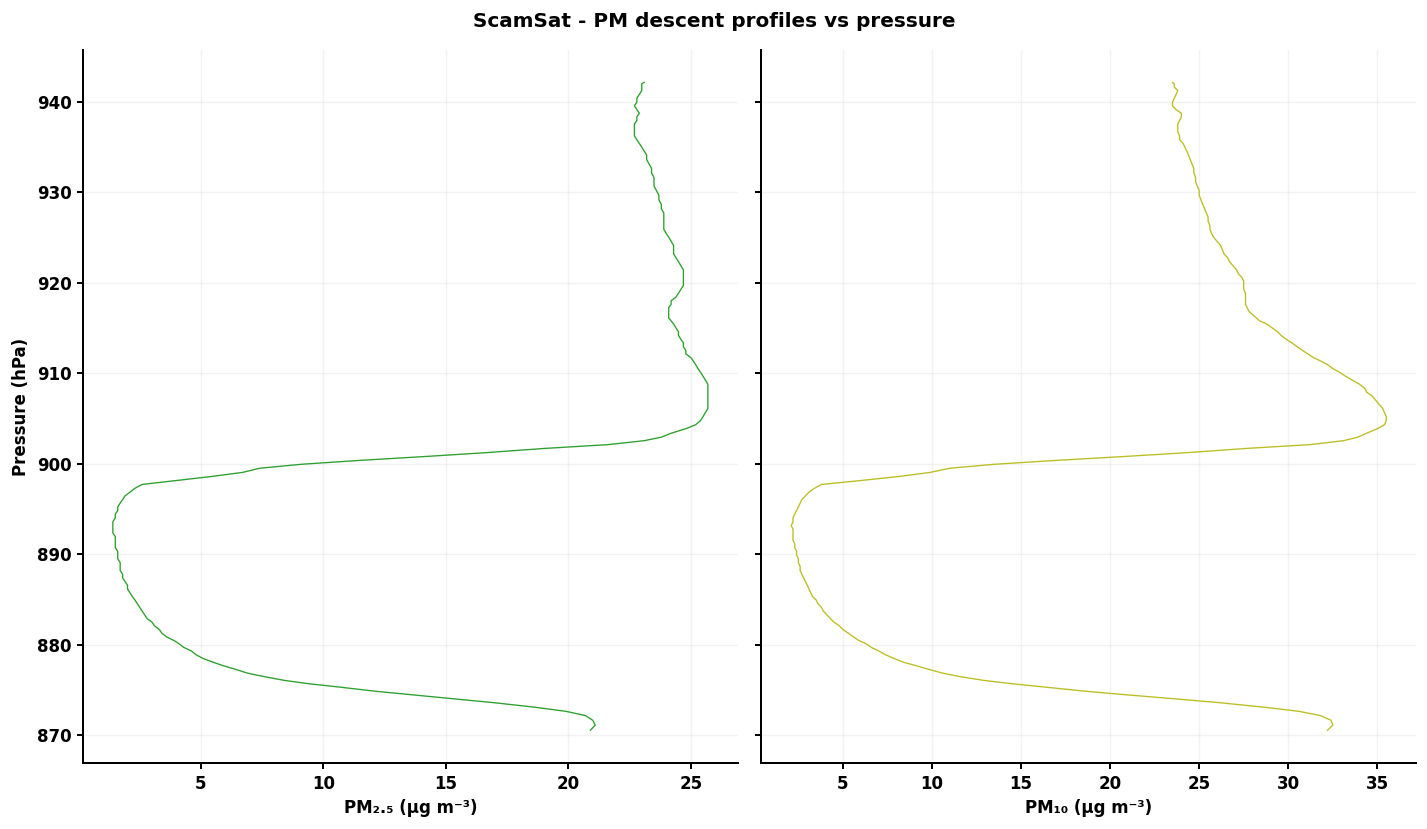

In [82]:
# ── 4.4 ScamSat - PM channels vs pressure ────────────────────────────────────
_scam_pm25_spec = scam_pm25[scam_pm25['t_s'].between(scam_t_apo, scam_t_land)].copy()
_scam_pm10_spec = scam_pm10[scam_pm10['t_s'].between(scam_t_apo, scam_t_land)].copy()

_p_pm25_hpa = np.interp(
    _scam_pm25_spec['t_s'].values,
    _scam_press_spec['t_s'].values, _scam_press_spec['press_Pa'].values
) / 100
_p_pm10_hpa = np.interp(
    _scam_pm10_spec['t_s'].values,
    _scam_press_spec['t_s'].values, _scam_press_spec['press_Pa'].values
) / 100

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle('ScamSat - PM descent profiles vs pressure', fontweight='bold')

axes[0].plot(_scam_pm25_spec['pm25'].values, _p_pm25_hpa, lw=0.8, color='tab:green')
axes[0].set(xlabel='PM₂.₅ (µg m⁻³)', ylabel='Pressure (hPa)')
axes[0].invert_yaxis()

axes[1].plot(_scam_pm10_spec['pm10'].values, _p_pm10_hpa, lw=0.8, color='tab:olive')
axes[1].set(xlabel='PM₁₀ (µg m⁻³)')
axes[1].invert_yaxis()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_scamsat_pm_vs_pressure.png', strip_text=False)
plt.show()


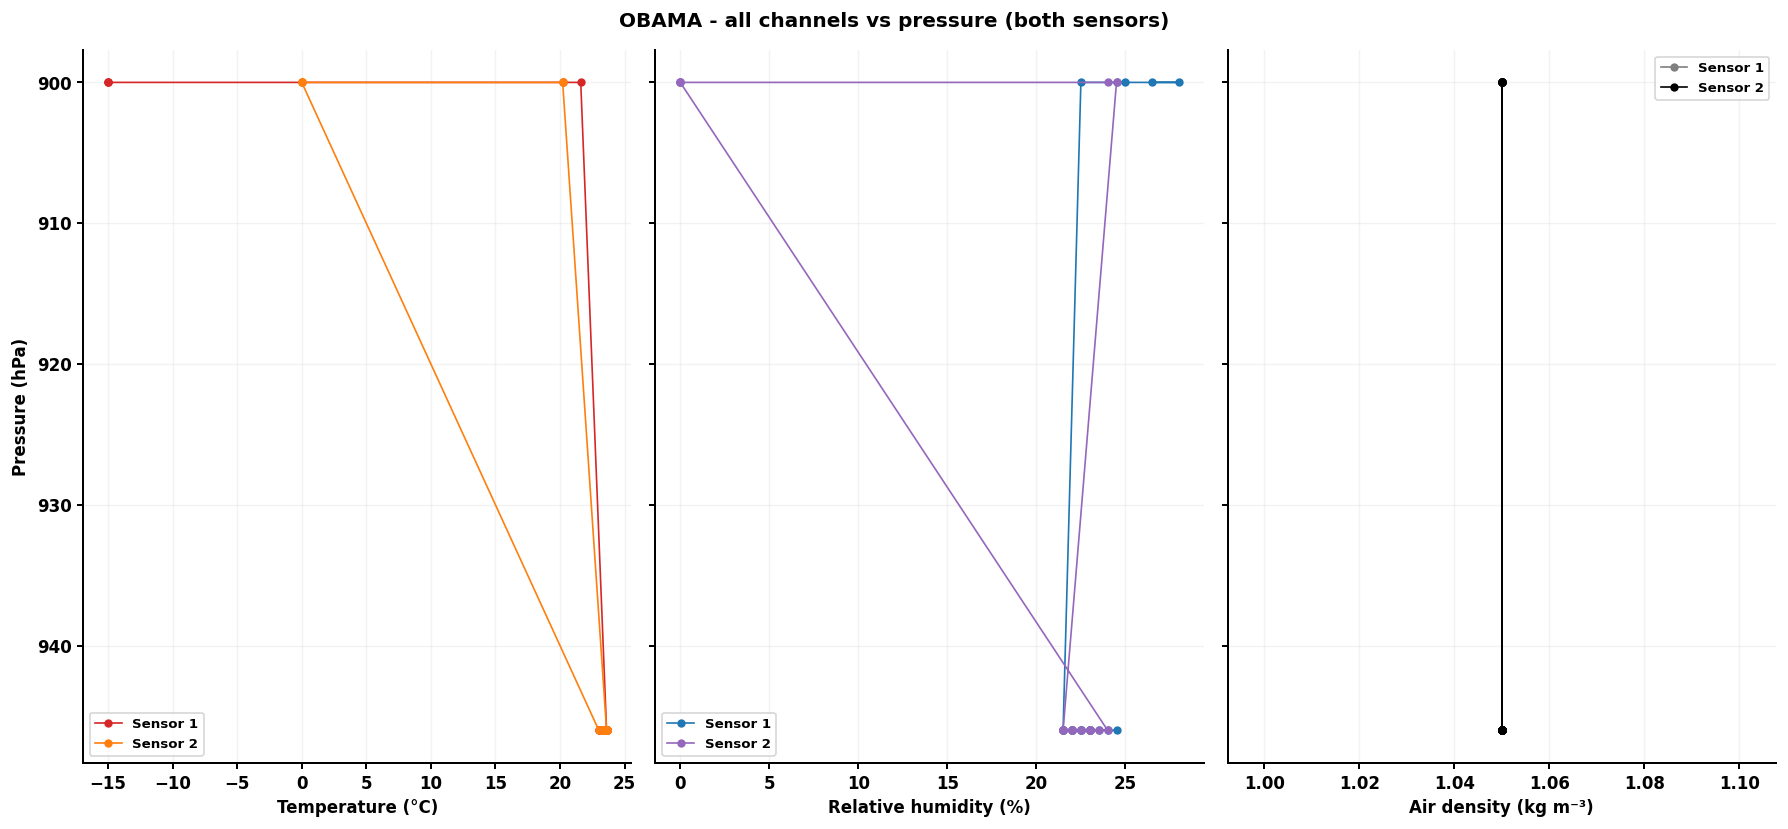

In [83]:
# ── 4.4 OBAMA - all channels vs pressure (31 rows) ──────────────────────────
_ob = obama.dropna(subset=['first_pstat_avg_hPa']).copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig.suptitle('OBAMA - all channels vs pressure (both sensors)', fontweight='bold')

_mkw = dict(marker='o', ms=4, lw=1.0)

axes[0].plot(_ob['first_temp_avg_C'],    _ob['first_pstat_avg_hPa'],  color='tab:red',    label='Sensor 1', **_mkw)
axes[0].plot(_ob['second_temp_avg_C'],   _ob['second_pstat_avg_hPa'], color='tab:orange', label='Sensor 2', **_mkw)
axes[0].set(xlabel='Temperature (°C)', ylabel='Pressure (hPa)')
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

axes[1].plot(_ob['first_hum_avg_pct'],   _ob['first_pstat_avg_hPa'],  color='tab:blue',   label='Sensor 1', **_mkw)
axes[1].plot(_ob['second_hum_avg_pct'],  _ob['second_pstat_avg_hPa'], color='tab:purple', label='Sensor 2', **_mkw)
axes[1].set(xlabel='Relative humidity (%)')
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

axes[2].plot(_ob['first_rho_avg'],  _ob['first_pstat_avg_hPa'],  color='tab:gray',  label='Sensor 1', **_mkw)
axes[2].plot(_ob['second_rho_avg'], _ob['second_pstat_avg_hPa'], color='black',     label='Sensor 2', **_mkw)
axes[2].set(xlabel='Air density (kg m⁻³)')
axes[2].invert_yaxis()
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_obama_vs_pressure.png', strip_text=False)
plt.show()


---
## 5. Atmospheric Time Series Analysis

With pre-processed signals in hand, we address the atmospheric component of the research question.  
We use:
- **GRASP** for high-frequency descent profiles (temperature, pressure, PM₂.₅/PM₁₀ at ~38 Hz, LP-filtered).
- **VAMOS science** for CO₂ and a longer-context T/P record including the drop window.
- **VAMOS wind** for the wind speed/direction profile during the descent.
- **OBAMA** as independent T/P/RH spot-check (not time-synchronised; order-of-magnitude only).
- **ISA standard atmosphere** as the theoretical vertical reference.


### 5.1 Temperature and Pressure - Vertical Profiles

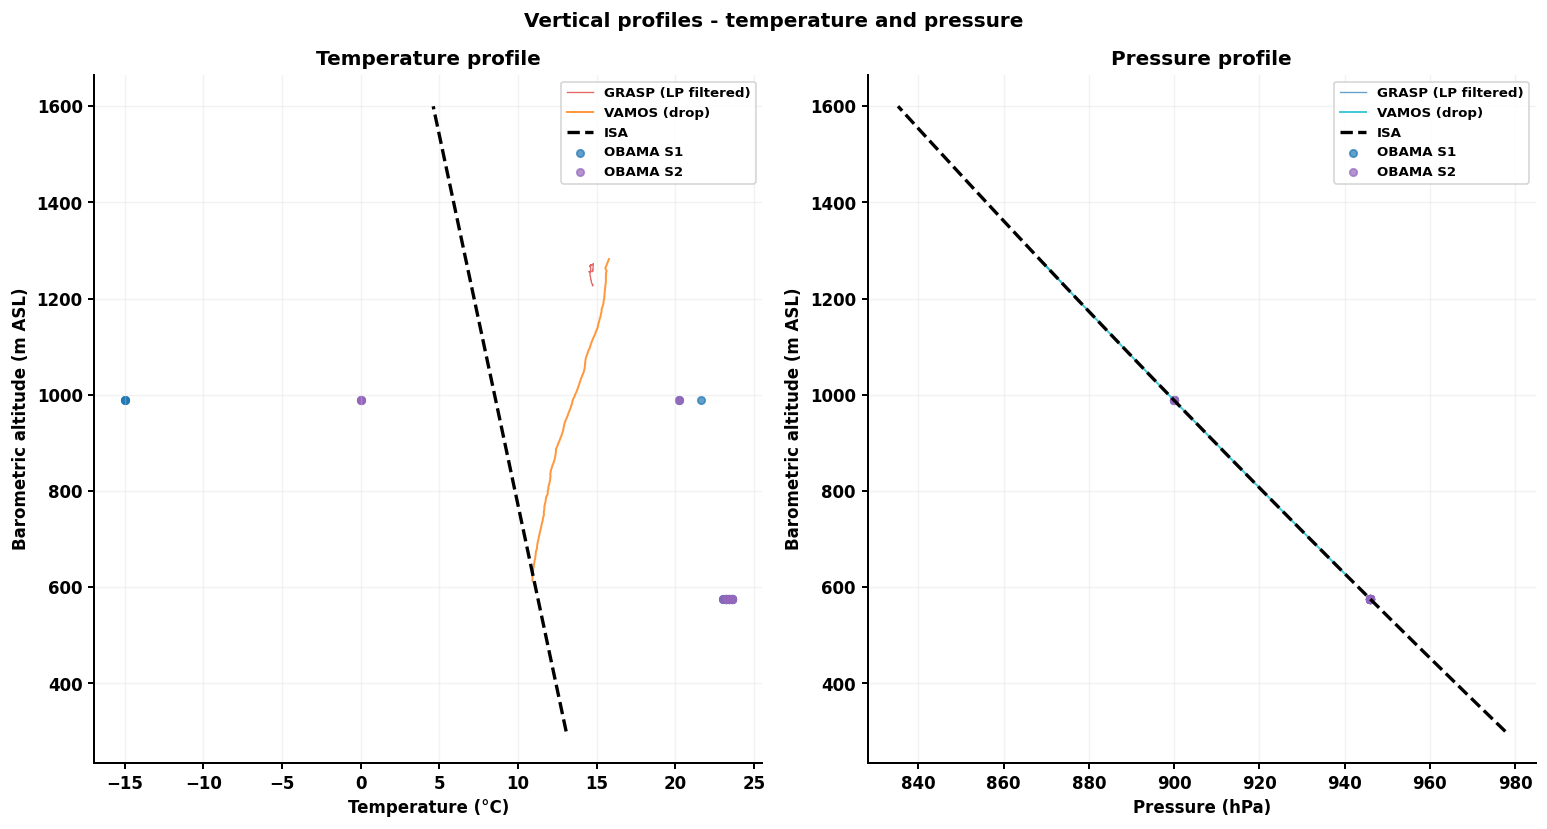

GRASP lapse rate: +1.00 K km⁻¹  (ISA: −6.5 K km⁻¹)
Mean T anomaly vs ISA: +7.8 K


In [84]:
# ── 5.1 GRASP filtered vertical profile ──────────────────────────────────────
_t_gu, _p_gu = resample_uniform(grasp_clean['t_rel'].values, grasp_clean['press_Pa'].values, float(FS_G))
_,     _T_gu = resample_uniform(grasp_clean['t_rel'].values, grasp_clean['temp_C'].values,  float(FS_G))
_p_gf = butter_lowpass(_p_gu, cutoff_hz=0.5, fs=float(FS_G), order=4)
_T_gf = butter_lowpass(_T_gu, cutoff_hz=0.3, fs=float(FS_G), order=4)
_h_gf = isa_alt(_p_gf)   # barometric altitude from filtered pressure

# ISA
_h_isa = np.linspace(300, 1600, 300)
_T_isa = isa_temp_c(_h_isa)
_p_isa = isa_press(_h_isa) / 100.0

# VAMOS drop window
_vd    = vamos[drop_mask]
_h_vd  = isa_alt(_vd['press_hPa'].values * 100.0)

# OBAMA
_ob    = obama.dropna(subset=['first_pstat_avg_hPa','first_temp_avg_C'])
_h_ob1 = isa_alt(_ob['first_pstat_avg_hPa'].values * 100.0)
_h_ob2 = isa_alt(_ob['second_pstat_avg_hPa'].values * 100.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Vertical profiles - temperature and pressure', fontweight='bold')

ax = axes[0]
ax.plot(_T_gf, _h_gf, lw=0.8, color='tab:red',    alpha=0.7, label='GRASP (LP filtered)')
ax.plot(_vd['temp_C'].values, _h_vd, lw=1.2, color='tab:orange', alpha=0.8, label='VAMOS (drop)')
ax.plot(_T_isa, _h_isa, lw=2.0, color='black', ls='--', label='ISA')
ax.scatter(_ob['first_temp_avg_C'],  _h_ob1, s=20, color='tab:blue',   alpha=0.7, label='OBAMA S1')
ax.scatter(_ob['second_temp_avg_C'], _h_ob2, s=20, color='tab:purple', alpha=0.7, label='OBAMA S2')
ax.set(xlabel='Temperature (°C)', ylabel='Barometric altitude (m ASL)', title='Temperature profile')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(_p_gf/100, _h_gf, lw=0.8, color='tab:blue', alpha=0.7, label='GRASP (LP filtered)')
ax.plot(_vd['press_hPa'].values, _h_vd, lw=1.2, color='tab:cyan', alpha=0.8, label='VAMOS (drop)')
ax.plot(_p_isa, _h_isa, lw=2.0, color='black', ls='--', label='ISA')
ax.scatter(_ob['first_pstat_avg_hPa'],  _h_ob1, s=20, color='tab:blue',   alpha=0.7, label='OBAMA S1')
ax.scatter(_ob['second_pstat_avg_hPa'], _h_ob2, s=20, color='tab:purple', alpha=0.7, label='OBAMA S2')
ax.set(xlabel='Pressure (hPa)', ylabel='Barometric altitude (m ASL)', title='Pressure profile')
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'cross_dataset/fig_vertical_profiles.png', strip_text=False)
plt.show()

_lapse = np.polyfit(_h_gf, _T_gf, 1)[0] * 1000
_bias  = _T_gf.mean() - isa_temp_c(_h_gf).mean()
print(f'GRASP lapse rate: {_lapse:+.2f} K km⁻¹  (ISA: −6.5 K km⁻¹)')
print(f'Mean T anomaly vs ISA: {_bias:+.1f} K')


### 5.2 Particulate Matter - PM₂.₅ and PM₁₀

WHO 2021 Air Quality Guidelines: PM₂.₅ < 15 µg m⁻³, PM₁₀ < 45 µg m⁻³ (24-h mean).

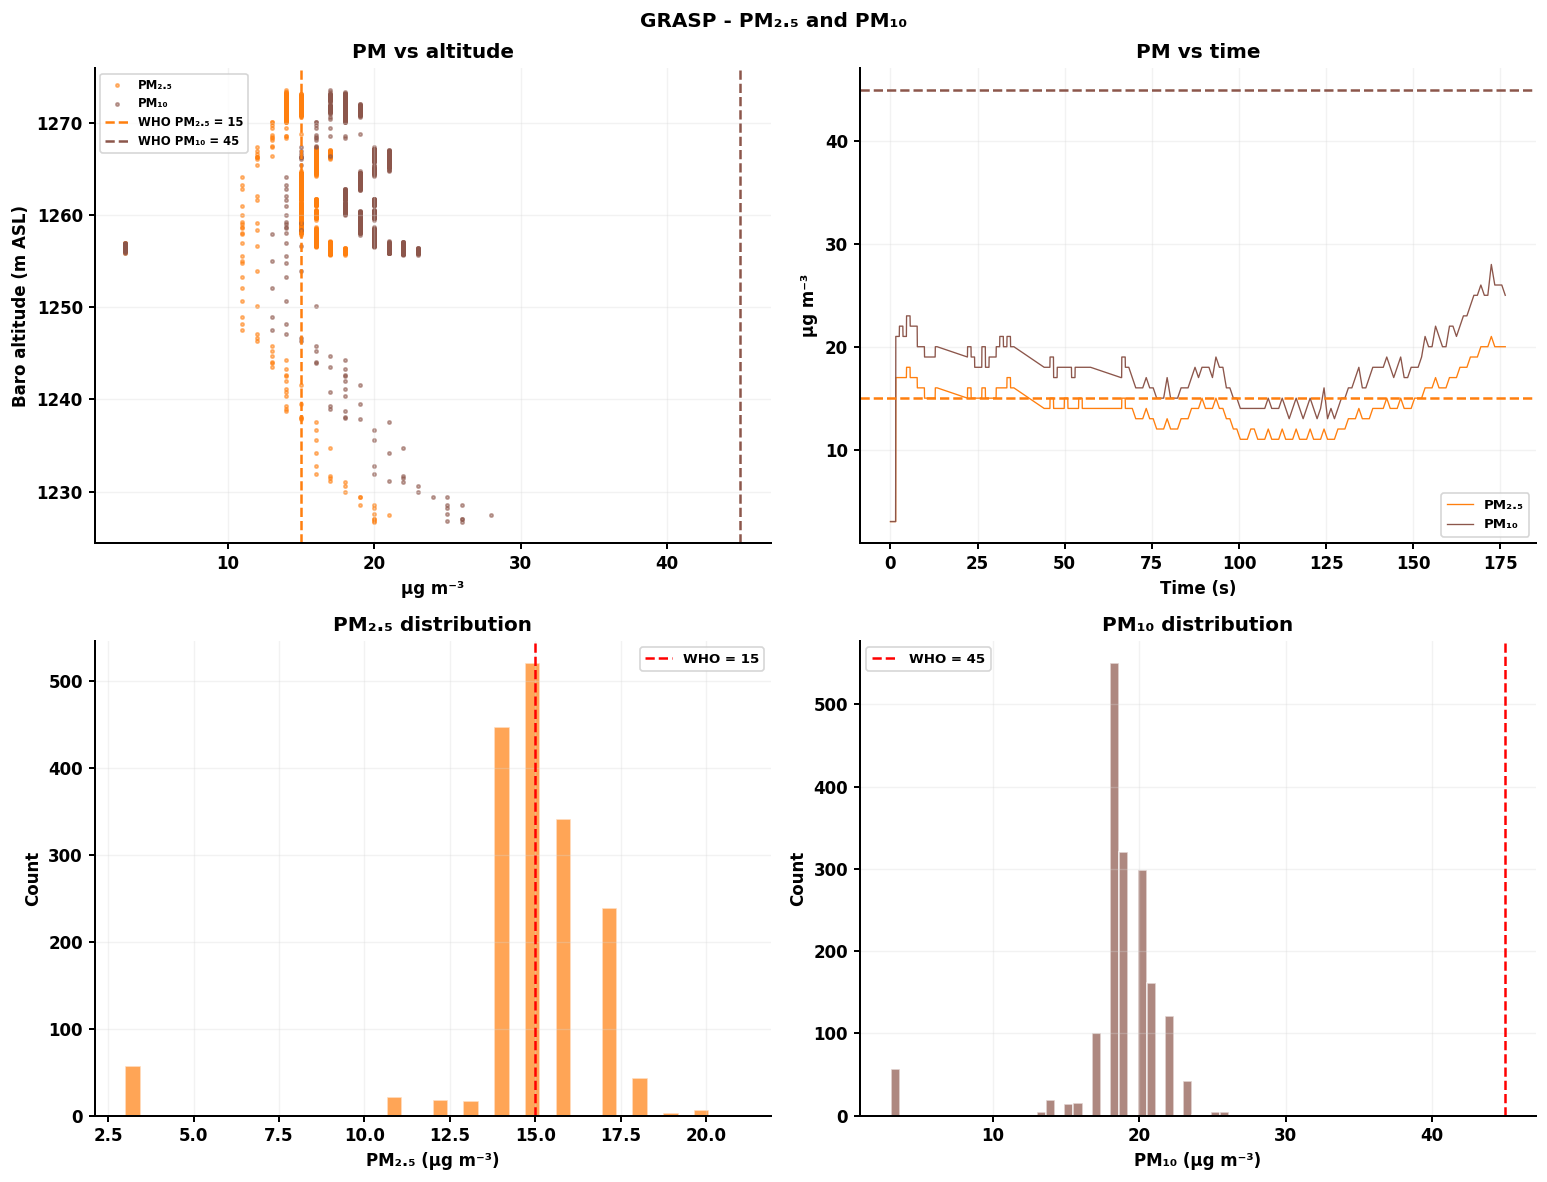

PM₂.₅ > WHO limit: 37.0% of samples
PM₂.₅ median: 15.0  max: 21.0  µg m⁻³
PM₁₀  median: 19.0  max: 28.0  µg m⁻³


In [85]:
# ── 5.2 PM analysis ───────────────────────────────────────────────────────────
_pm25 = grasp_clean['pm25'].values
_pm10 = grasp_clean['pm10'].values
_h    = grasp_clean['alt_baro'].values
_tg   = grasp_clean['t_rel'].values

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('GRASP - PM₂.₅ and PM₁₀', fontweight='bold')

ax = axes[0,0]
ax.scatter(_pm25, _h, s=4, alpha=0.5, color='tab:orange', label='PM₂.₅')
ax.scatter(_pm10, _h, s=4, alpha=0.5, color='tab:brown',  label='PM₁₀')
ax.axvline(WHO_PM25_24H, color='tab:orange', lw=1.5, ls='--', label=f'WHO PM₂.₅ = {WHO_PM25_24H}')
ax.axvline(WHO_PM10_24H, color='tab:brown',  lw=1.5, ls='--', label=f'WHO PM₁₀ = {WHO_PM10_24H}')
ax.set(xlabel='µg m⁻³', ylabel='Baro altitude (m ASL)', title='PM vs altitude')
ax.legend(fontsize=7)

ax = axes[0,1]
ax.plot(_tg, _pm25, lw=0.8, color='tab:orange', label='PM₂.₅')
ax.plot(_tg, _pm10, lw=0.8, color='tab:brown',  label='PM₁₀')
ax.axhline(WHO_PM25_24H, color='tab:orange', lw=1.5, ls='--')
ax.axhline(WHO_PM10_24H, color='tab:brown',  lw=1.5, ls='--')
ax.set(xlabel='Time (s)', ylabel='µg m⁻³', title='PM vs time')
ax.legend(fontsize=8)

for ax, data, lbl, lim, col in [
    (axes[1,0], _pm25, 'PM₂.₅', WHO_PM25_24H, 'tab:orange'),
    (axes[1,1], _pm10, 'PM₁₀',  WHO_PM10_24H, 'tab:brown'),
]:
    ax.hist(data, bins=40, color=col, alpha=0.7, edgecolor='white')
    ax.axvline(lim, color='red', lw=1.5, ls='--', label=f'WHO = {lim}')
    ax.set(xlabel=f'{lbl} (µg m⁻³)', ylabel='Count', title=f'{lbl} distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_pm_analysis.png', strip_text=False)
plt.show()
print(f'PM₂.₅ > WHO limit: {np.mean(_pm25 > WHO_PM25_24H)*100:.1f}% of samples')
print(f'PM₂.₅ median: {np.median(_pm25):.1f}  max: {np.max(_pm25):.1f}  µg m⁻³')
print(f'PM₁₀  median: {np.median(_pm10):.1f}  max: {np.max(_pm10):.1f}  µg m⁻³')


### 5.3 CO₂ - VAMOS

NDIR sensor, warm-up zeros excluded. Global atmospheric background: 420 ppm (NOAA, 2024).

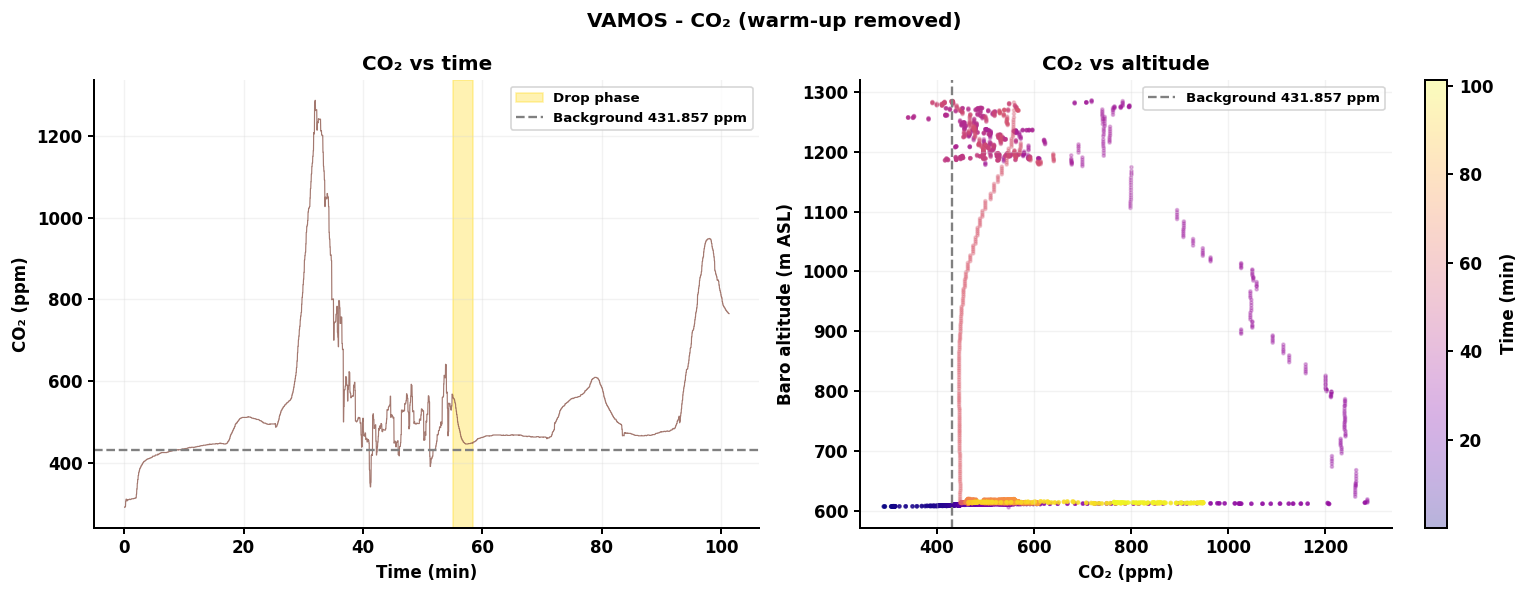

CO₂ median: 488 ppm | max: 1287 ppm
Above background: 89.8% of samples


In [86]:
# ── 5.3 CO₂ analysis ─────────────────────────────────────────────────────────
_co2_t = vamos_co2['t_rel'].values / 60
_co2_v = vamos_co2['co2_ppm'].values
_co2_h = isa_alt(vamos_co2['press_hPa'].values * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('VAMOS - CO₂ (warm-up removed)', fontweight='bold')

ax = axes[0]
ax.plot(_co2_t, _co2_v, lw=0.7, color='tab:brown', alpha=0.8)
ax.axvspan(_apo_mf, _land_mf, color='gold', alpha=0.3, label='Drop phase')
ax.axhline(CO2_BACKGROUND_PPM, ls='--', color='gray', lw=1.4, label=f'Background {CO2_BACKGROUND_PPM} ppm')
ax.set(xlabel='Time (min)', ylabel='CO₂ (ppm)', title='CO₂ vs time')
ax.legend(fontsize=8)

ax = axes[1]
sc = ax.scatter(_co2_v, _co2_h, s=3, alpha=0.3, c=_co2_t, cmap='plasma')
ax.axvline(CO2_BACKGROUND_PPM, ls='--', color='gray', lw=1.4, label=f'Background {CO2_BACKGROUND_PPM} ppm')
ax.set(xlabel='CO₂ (ppm)', ylabel='Baro altitude (m ASL)', title='CO₂ vs altitude')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Time (min)')

plt.tight_layout()
save_figure(fig, 'signal_processing/fig_co2_analysis.png', strip_text=False)
plt.show()
print(f'CO₂ median: {np.median(_co2_v):.0f} ppm | max: {np.max(_co2_v):.0f} ppm')
print(f'Above background: {np.mean(_co2_v > CO2_BACKGROUND_PPM)*100:.1f}% of samples')


### 5.4 Wind - VAMOS

Full mission time series and vertical profile during the drop phase.

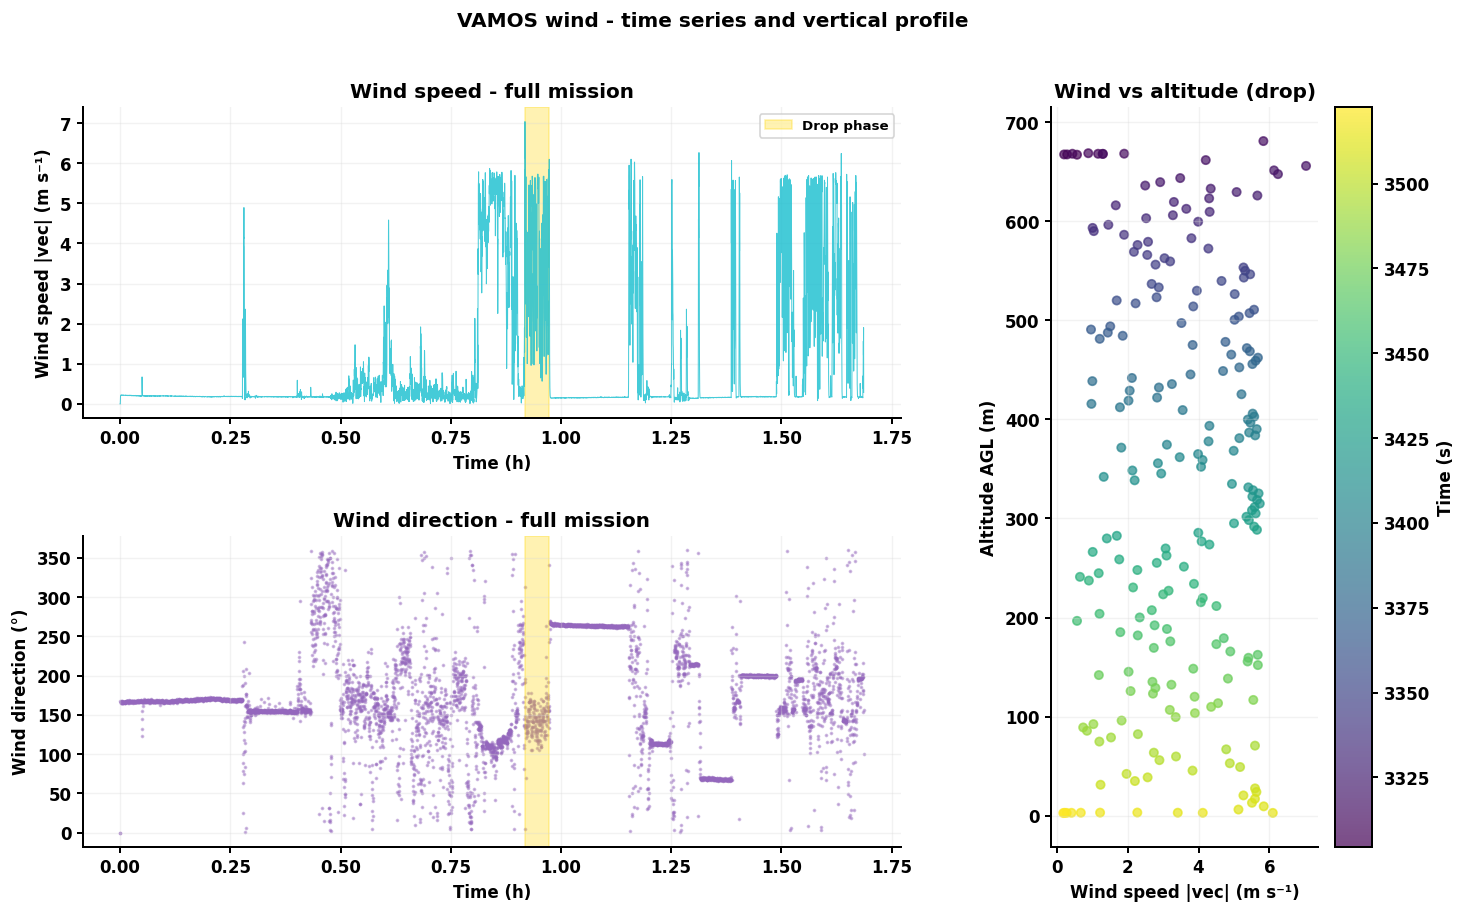

Drop-phase wind - mean: 3.45 m/s | max: 7.04 m/s
Drop-phase apparent yaw/spin - net: -0.88 turns | median |yaw rate|: 2.97 deg/s


In [87]:
# ── 5.4 Wind analysis ────────────────────────────────────────────────────────
_drop_w = wind[wind['t_s'].between(t_apo - 10, t_land + 10)].copy()
_h_drop = np.interp(_drop_w['t_s'].values, vamos['t_s'].values, vamos_drop['h_agl'])

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.45)
fig.suptitle('VAMOS wind - time series and vertical profile', fontweight='bold')

_twh = wind['t_rel'].values / 3600
_d0h = (t_apo  - wind['t_s'].iat[0]) / 3600
_d1h = (t_land - wind['t_s'].iat[0]) / 3600

ax = fig.add_subplot(gs[0, :2])
ax.plot(_twh, wind['wind_spd_vec'], lw=0.6, color='tab:cyan', alpha=0.8)
ax.axvspan(_d0h, _d1h, color='gold', alpha=0.3, label='Drop phase')
ax.set(xlabel='Time (h)', ylabel='Wind speed |vec| (m s⁻¹)', title='Wind speed - full mission')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, :2])
ax.scatter(_twh, wind['wind_dir'], s=1.5, alpha=0.4, color='tab:purple')
ax.axvspan(_d0h, _d1h, color='gold', alpha=0.3)
ax.set(xlabel='Time (h)', ylabel='Wind direction (°)', title='Wind direction - full mission')

ax = fig.add_subplot(gs[:, 2])
sc = ax.scatter(_drop_w['wind_spd_vec'].values, _h_drop,
                s=25, alpha=0.7, c=_drop_w['t_s'].values, cmap='viridis')
ax.set(xlabel='Wind speed |vec| (m s⁻¹)', ylabel='Altitude AGL (m)', title='Wind vs altitude (drop)')
plt.colorbar(sc, ax=ax, label='Time (s)')

plt.tight_layout()
save_figure(fig, 'flight_dynamics/fig_wind_profile.png', strip_text=False)
plt.show()
print(f'Drop-phase wind - mean: {_drop_w["wind_spd_vec"].mean():.2f} m/s | max: {_drop_w["wind_spd_vec"].max():.2f} m/s')
_drop_turns = (_drop_w["wind_dir_unwrapped"].iat[-1] - _drop_w["wind_dir_unwrapped"].iat[0]) / 360.0
_drop_med_yaw = _drop_w["yaw_rate_deg_s"].abs().median()
print(f'Drop-phase apparent yaw/spin - net: {_drop_turns:.2f} turns | median |yaw rate|: {_drop_med_yaw:.2f} deg/s')


## 6. Final plots: every retained signal as a function of pressure

        Pressure is plotted on the vertical axis and inverted, so the descent reads from low pressure aloft toward higher pressure near the ground.


NameError: name 'temp_v_clean' is not defined

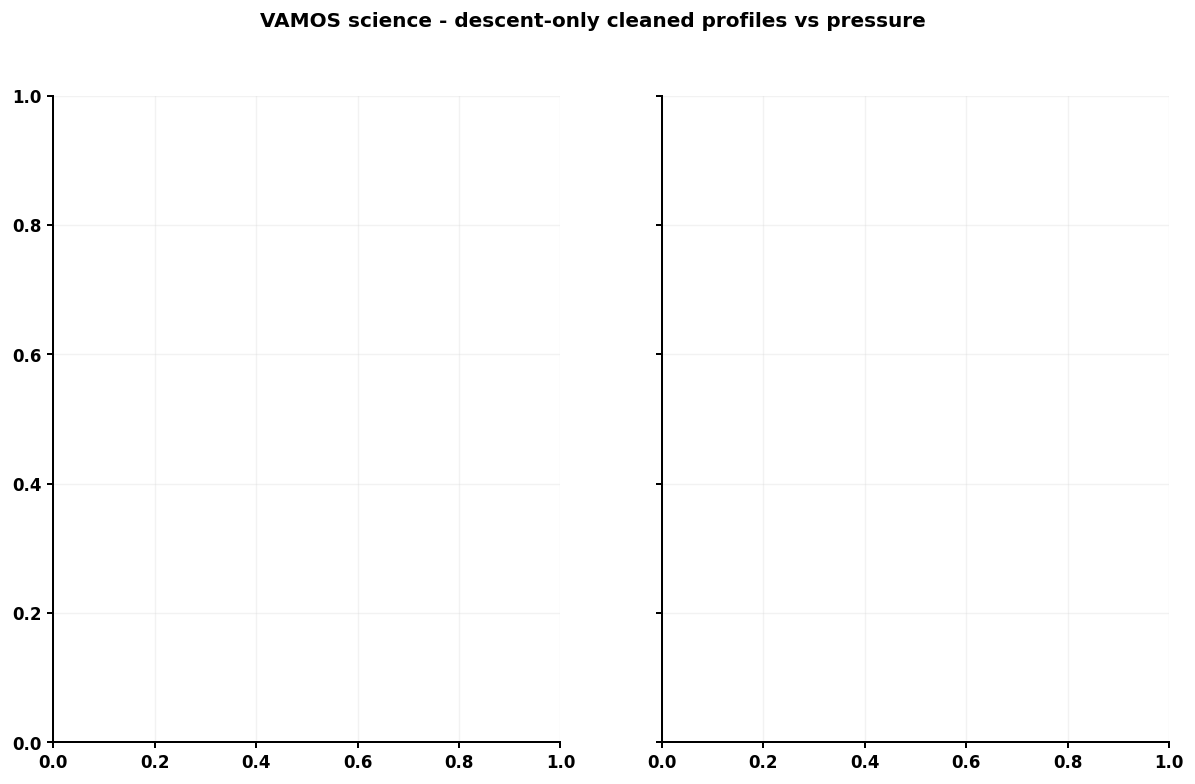

In [88]:
# 6.1 VAMOS science vs pressure
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle("VAMOS science - descent-only cleaned profiles vs pressure", fontweight="bold")

axes[0].plot(temp_v_clean, p_v_clean, color="tab:red", lw=1.2)
axes[0].set(xlabel="Temperature (deg C)", ylabel="Pressure (hPa)")
axes[0].invert_yaxis()  # inverte l'asse Y (si propaga ad axes[1] via sharey)

axes[1].plot(vamos_co2_profile["co2_clean"], vamos_co2_profile["press_hPa"], color="tab:brown", lw=1.0)
axes[1].scatter(vamos_co2_profile["co2_ppm"], vamos_co2_profile["press_hPa"], color="tab:brown", s=8, alpha=0.25, label="valid raw CO2")
axes[1].axvline(CO2_BACKGROUND_PPM, color="gray", ls="--", lw=1.2, label=f"background {CO2_BACKGROUND_PPM} ppm")
axes[1].set(xlabel="CO2 (ppm)")
axes[1].invert_yaxis()  # ← aggiunto: esplicito per sicurezza
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(True, alpha=0.3)

p_min = p_v_clean.min()
p_max = p_v_clean.max()
axes[0].set_ylim(p_max, p_min) 

plt.tight_layout()
save_figure(fig, "signal_processing/final_vamos_science_vs_pressure.png", strip_text=False)
plt.show()

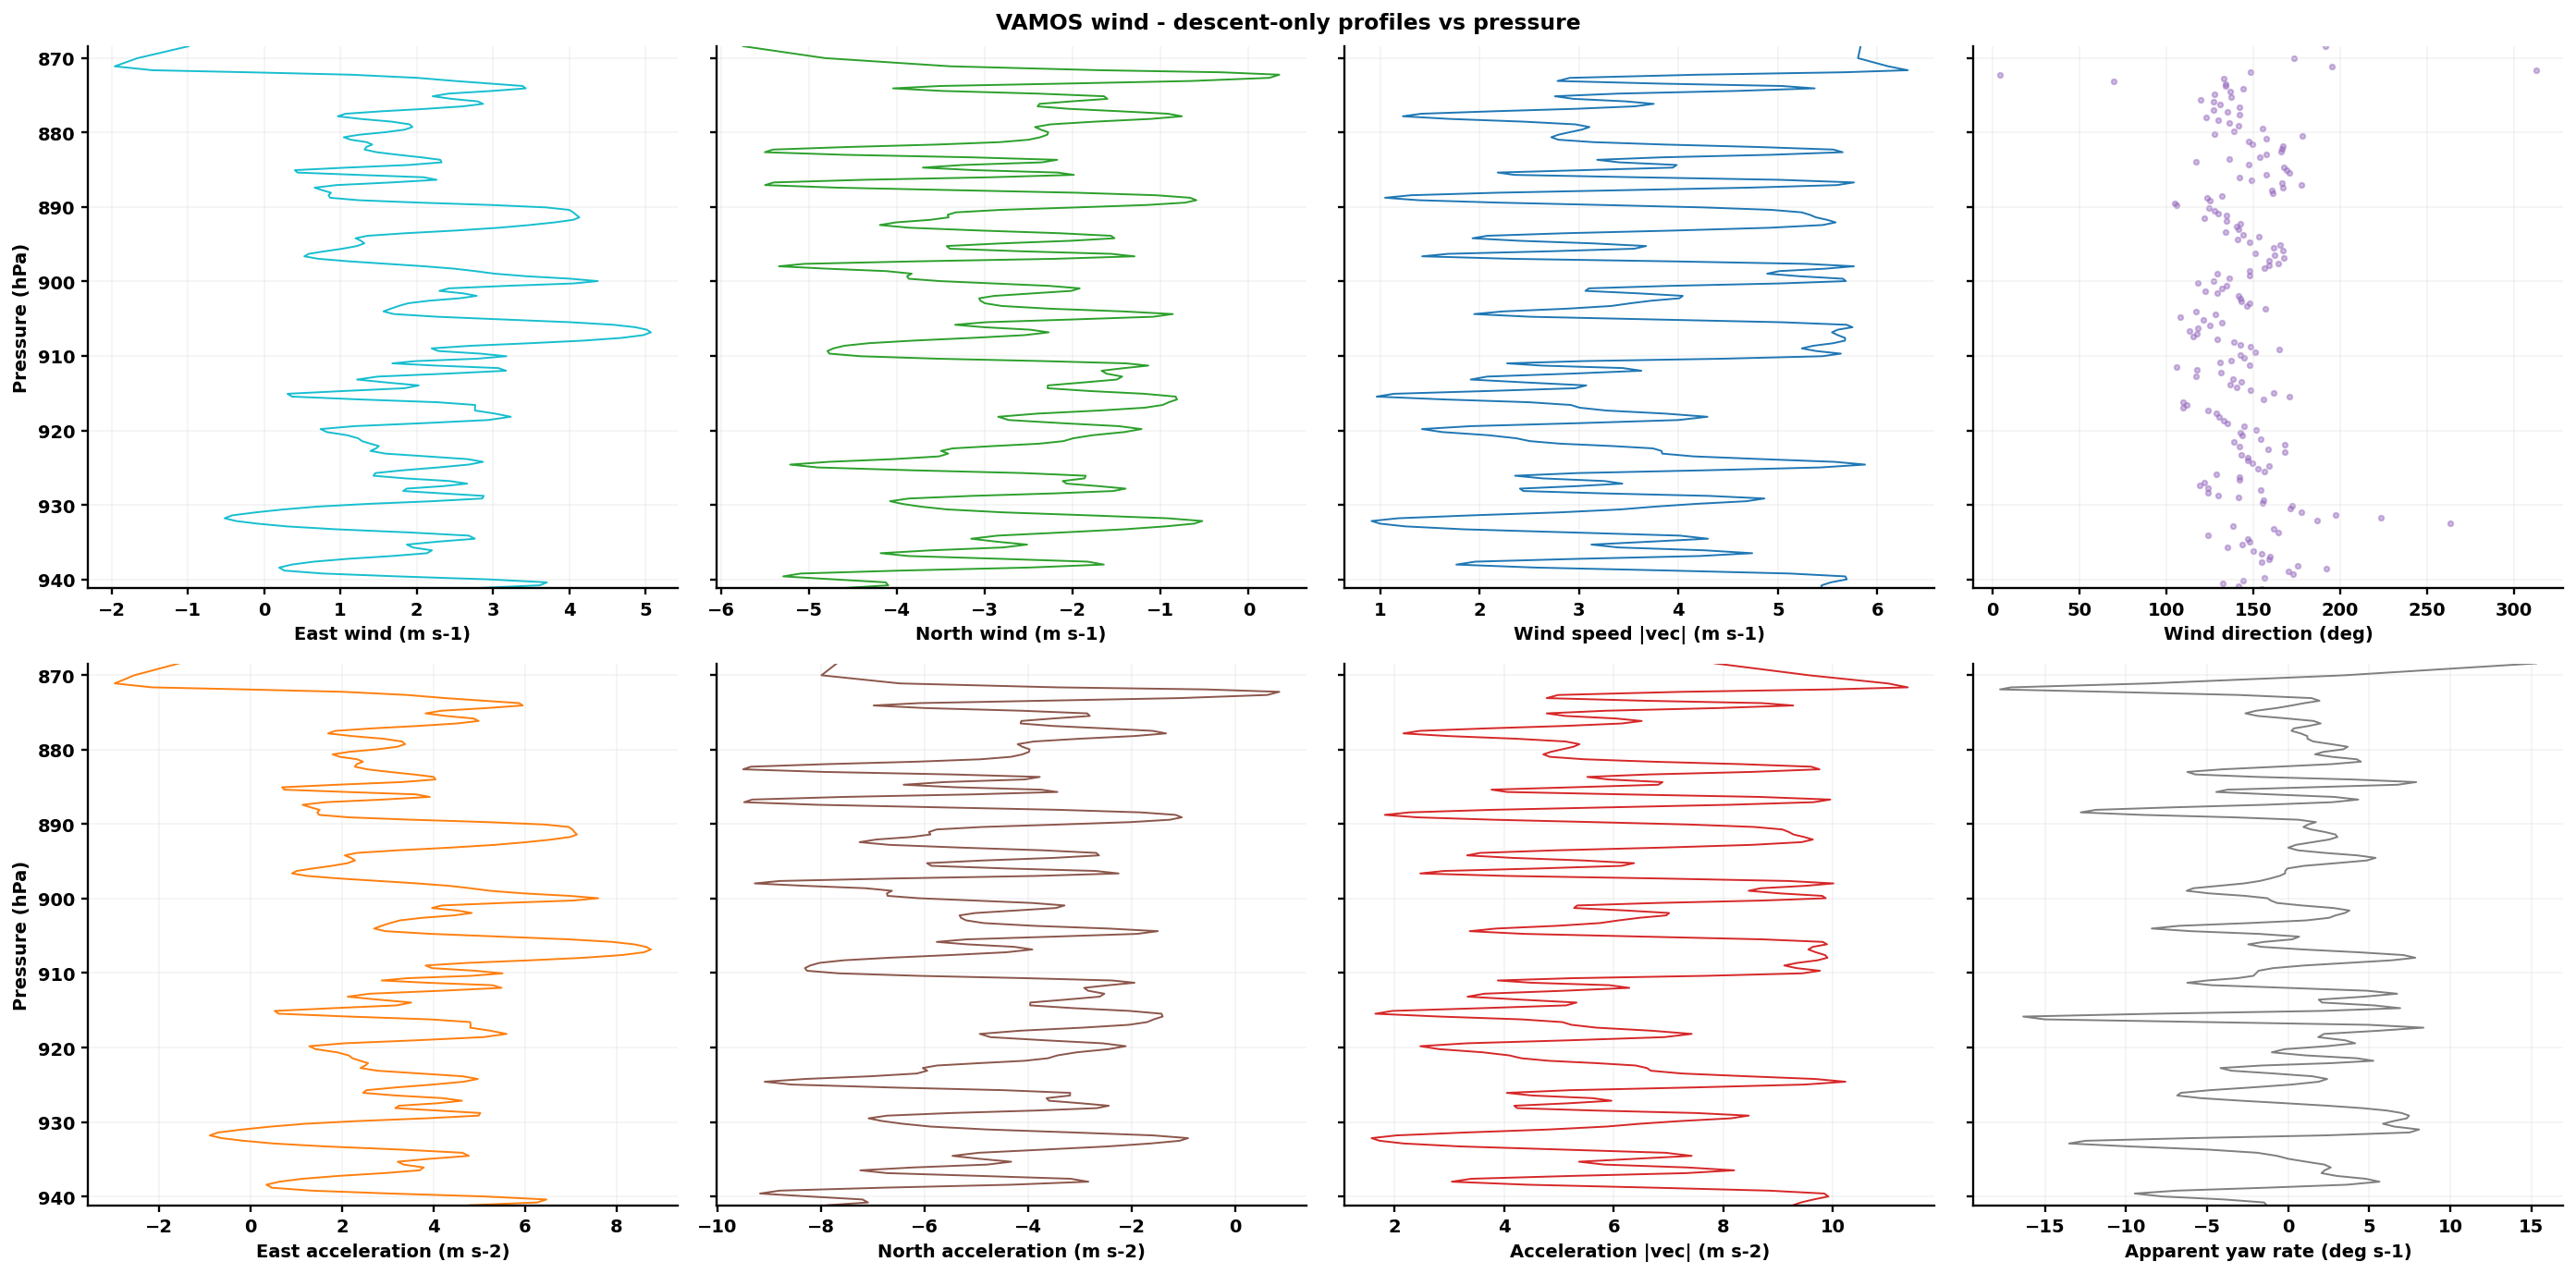

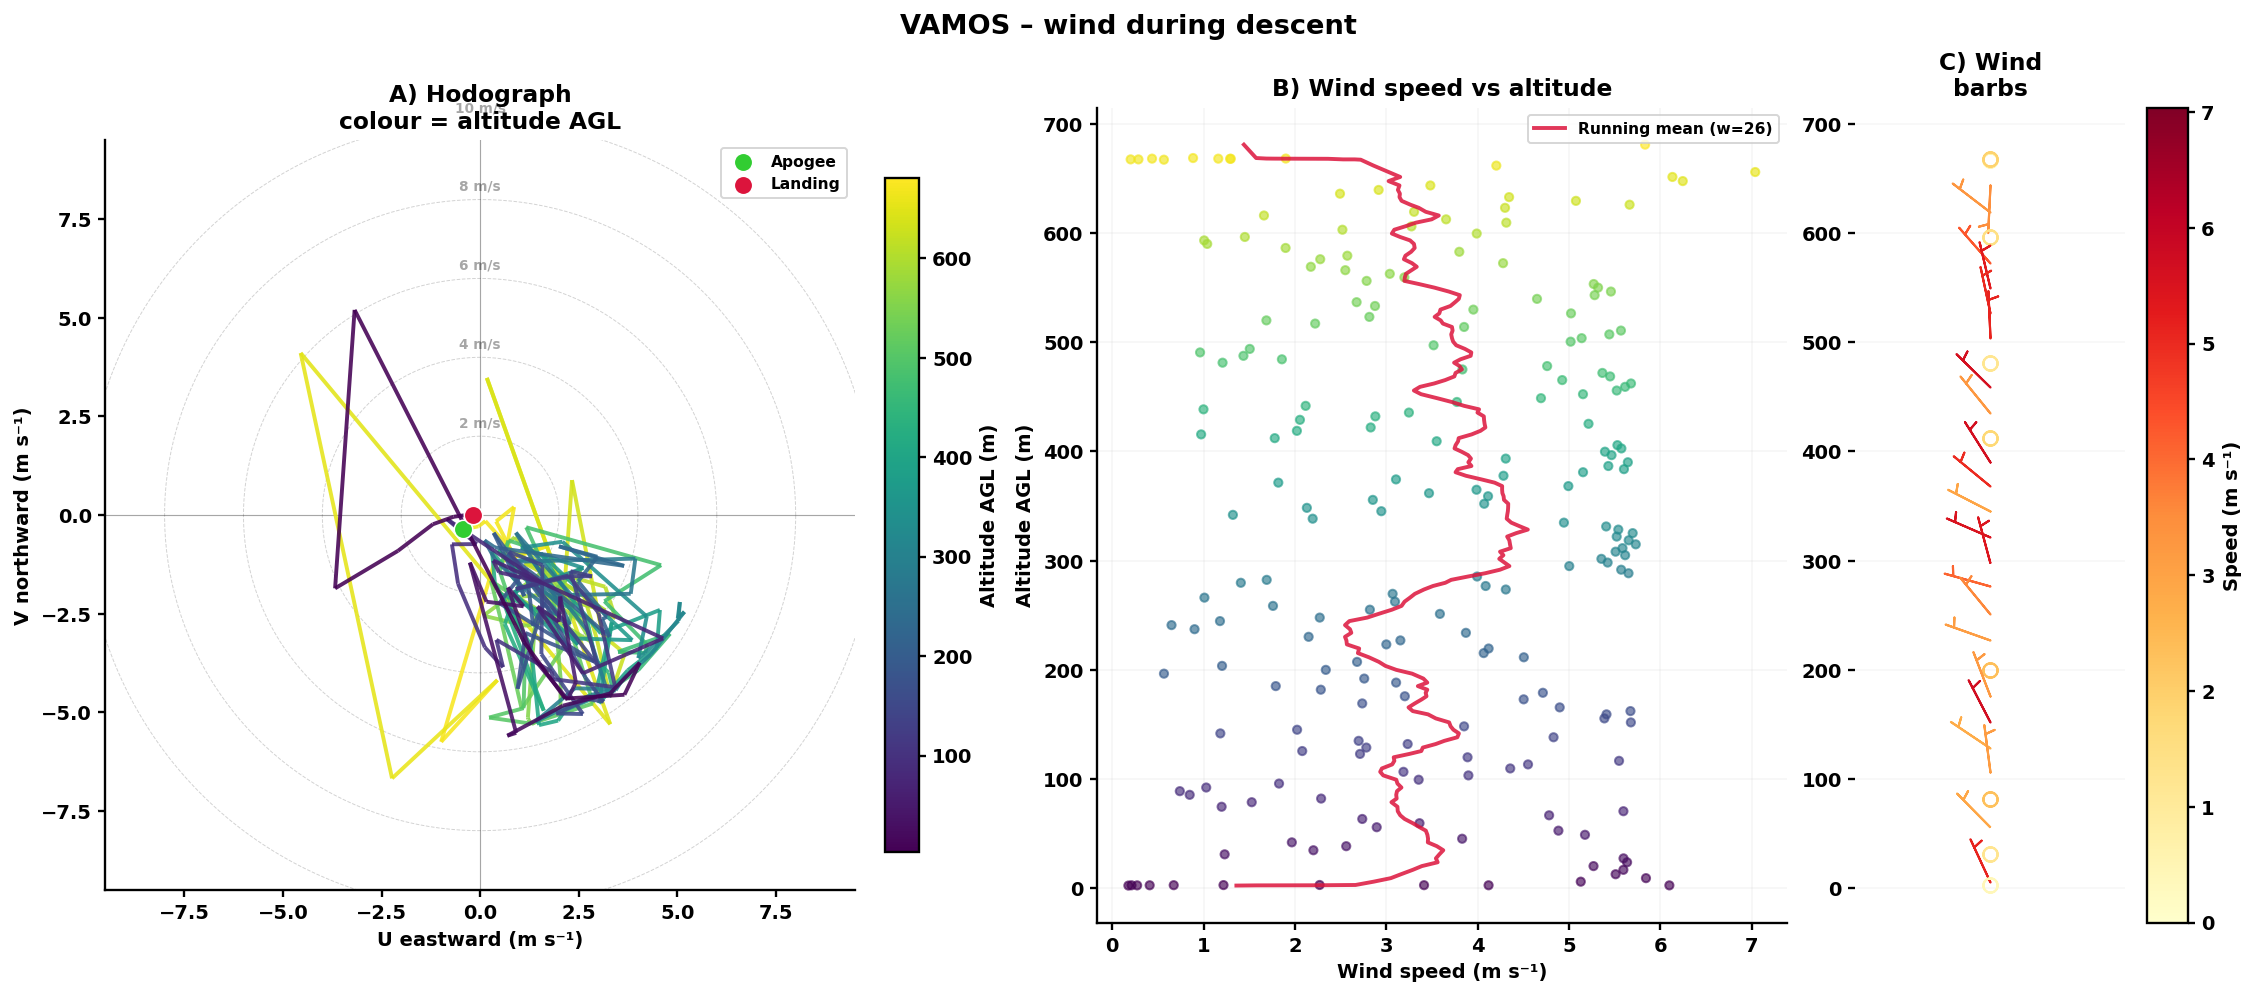

Drop-phase mean wind:  U=1.77 m/s (E)  V=-2.50 m/s (N)
Mean bearing (from):   324.7°  |  Mean speed: 3.45 m/s


In [ ]:
# 6.2.1 VAMOS wind vs pressure
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
fig.suptitle("VAMOS wind - descent-only profiles vs pressure", fontweight="bold")

panels = [
    ("x_mps", "East wind (m s-1)", "tab:cyan"),
    ("y_mps", "North wind (m s-1)", "tab:green"),
    ("wind_spd_vec", "Wind speed |vec| (m s-1)", "tab:blue"),
    ("wind_dir", "Wind direction (deg)", "tab:purple"),
    ("x_acc", "East acceleration (m s-2)", "tab:orange"),
    ("y_acc", "North acceleration (m s-2)", "tab:brown"),
    ("wind_acc_vec", "Acceleration |vec| (m s-2)", "tab:red"),
    ("yaw_rate_deg_s", "Apparent yaw rate (deg s-1)", "tab:gray"),
]

for ax, (col, xlabel, color) in zip(axes.flat, panels):
    if col == "wind_dir":
        ax.scatter(vamos_wind_descent[col], p_wind_raw_hpa, s=8, alpha=0.45, color=color)
    else:
        ax.plot(wind_clean[col], p_wind_hpa[col], color=color, lw=1.0)
    ax.set(xlabel=xlabel)
    ax.grid(True, alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel("Pressure (hPa)")
    ax.invert_yaxis()

p_min = p_wind_hpa[panels[0][0]].min()  
p_max = p_wind_hpa[panels[0][0]].max()
axes[0, 0].set_ylim(p_max, p_min) 

plt.tight_layout()
save_figure(fig, "signal_processing/final_vamos_wind_vs_pressure.png", strip_text=False)
plt.show()



# 6.2.2 VAMOS compass rose and hodograph
vamos_drop=utils.detect_vamos_drop(vamos); t_apo,t_land=vamos_drop["t_apogee_s"],vamos_drop["t_landing_s"]
wind_raw=utils.load_vamos_wind()
wind_raw["wind_dir_unwrapped"],wind_raw["yaw_rate_deg_s"]=utils.apparent_yaw_from_wind_direction(wind_raw["t_rel"].values,wind_raw["wind_dir"].values,smooth_window=5)

_drop_w=wind_raw[wind_raw["t_s"].between(t_apo-10,t_land+10)].copy()
_h_drop=np.interp(_drop_w["t_s"].values,vamos["t_s"].values,vamos_drop["h_agl"])

_u,_v=_drop_w["x_mps"].values,_drop_w["y_mps"].values
_spd,_dir=_drop_w["wind_spd_vec"].values,_drop_w["wind_dir"].values%360

_norm_h=mcolors.Normalize(vmin=_h_drop.min(),vmax=max(_h_drop.max(),1)); _cmap_h=cm.get_cmap("viridis")
N_BARB=max(1,len(_h_drop)//30); _hb,_ub,_vb,_spdb=_h_drop[::N_BARB],_u[::N_BARB],_v[::N_BARB],_spd[::N_BARB]

_norm_sb=mcolors.Normalize(vmin=0,vmax=max(_spd.max(),1)); _cmap_sb=cm.get_cmap("YlOrRd")
_idx=np.argsort(_h_drop); _hs,_ss=_h_drop[_idx],_spd[_idx]
_win=max(5,len(_hs)//8); _sm=np.convolve(_ss,np.ones(_win)/_win,mode="same")

fig_wind,(ax_h,ax_spd,ax_barb)=plt.subplots(1,3,figsize=(16,7),gridspec_kw={"width_ratios":[1.25,1.15,0.45]},constrained_layout=True)
fig_wind.suptitle("VAMOS – wind during descent",fontsize=14,fontweight="bold")

# Panel A
ax_h.set_aspect("equal")
points=np.column_stack([_u,_v]).reshape(-1,1,2); segs=np.concatenate([points[:-1],points[1:]],axis=1)
lc=LineCollection(segs,cmap=_cmap_h,norm=_norm_h,linewidth=2.0,alpha=0.88,zorder=3)
lc.set_array(0.5*(_h_drop[:-1]+_h_drop[1:])); ax_h.add_collection(lc)

_rmax=float(np.ceil(np.hypot(_u,_v).max()/2)*2)+1.5
for _r in np.arange(2,_rmax+2,2):
    theta=np.linspace(0,2*np.pi,360)
    ax_h.plot(_r*np.cos(theta),_r*np.sin(theta),color="gray",lw=0.5,ls="--",alpha=0.35,zorder=1)
    ax_h.text(0,_r+0.15,f"{_r:.0f} m/s",fontsize=7,color="gray",ha="center",va="bottom",alpha=0.7,zorder=2)

ax_h.axhline(0,color="k",lw=0.6,alpha=0.35); ax_h.axvline(0,color="k",lw=0.6,alpha=0.35)
ax_h.scatter(_u[0],_v[0],s=90,color="limegreen",zorder=5,edgecolors="white",linewidths=0.8,label="Apogee")
ax_h.scatter(_u[-1],_v[-1],s=90,color="crimson",zorder=5,edgecolors="white",linewidths=0.8,label="Landing")

ax_h.set_xlim(-_rmax,_rmax); ax_h.set_ylim(-_rmax,_rmax)
ax_h.set_xlabel("U eastward (m s⁻¹)"); ax_h.set_ylabel("V northward (m s⁻¹)")
ax_h.set_title("A) Hodograph\ncolour = altitude AGL",fontweight="bold"); ax_h.legend(fontsize=8,loc="upper right"); ax_h.grid(False)

sm_h=cm.ScalarMappable(cmap=_cmap_h,norm=_norm_h); sm_h.set_array([])
cbar_h=fig_wind.colorbar(sm_h,ax=ax_h,fraction=0.045,pad=0.04); cbar_h.set_label("Altitude AGL (m)")

# Panel B
ax_spd.scatter(_spd,_h_drop,c=_h_drop,cmap="viridis",s=18,alpha=0.65,norm=_norm_h,zorder=2)
ax_spd.plot(_sm,_hs,color="crimson",lw=2.0,alpha=0.85,label=f"Running mean (w={_win})",zorder=3)
ax_spd.set_xlabel("Wind speed (m s⁻¹)"); ax_spd.set_ylabel("Altitude AGL (m)")
ax_spd.set_title("B) Wind speed vs altitude",fontweight="bold"); ax_spd.legend(fontsize=8); ax_spd.grid(True,alpha=0.25)

# Panel C
for i in range(len(_hb)):
    col=_cmap_sb(_norm_sb(_spdb[i]))
    ax_barb.barbs(0,_hb[i],_ub[i],_vb[i],length=7,linewidth=1.1,barbcolor=col,flagcolor=col,zorder=3)

ax_barb.set_xlim(-1.5,1.5); ax_barb.set_ylim(ax_spd.get_ylim())
ax_barb.set_title("C) Wind\nbarbs",fontweight="bold")
ax_barb.set_xticks([]); ax_barb.set_xlabel(""); ax_barb.set_ylabel("")
ax_barb.grid(True,axis="y",alpha=0.2)
for s in ["top","bottom","left"]: ax_barb.spines[s].set_visible(False)

sm_sb=cm.ScalarMappable(cmap=_cmap_sb,norm=_norm_sb); sm_sb.set_array([])
cbar_sb=fig_wind.colorbar(sm_sb,ax=ax_barb,fraction=0.22,pad=0.08); cbar_sb.set_label("Speed (m s⁻¹)")

save_figure(fig_wind,"flight_dynamics/wind_combined_hodograph_speed_barbs.png",strip_text=False)
plt.show()

_u_mean,_v_mean=_u.mean(),_v.mean()
_mean_bearing=np.rad2deg(np.arctan2(-_u_mean,-_v_mean))%360

print(f"Drop-phase mean wind:  U={_u_mean:.2f} m/s (E)  V={_v_mean:.2f} m/s (N)")
print(f"Mean bearing (from):   {_mean_bearing:.1f}°  |  Mean speed: {_spd.mean():.2f} m/s")



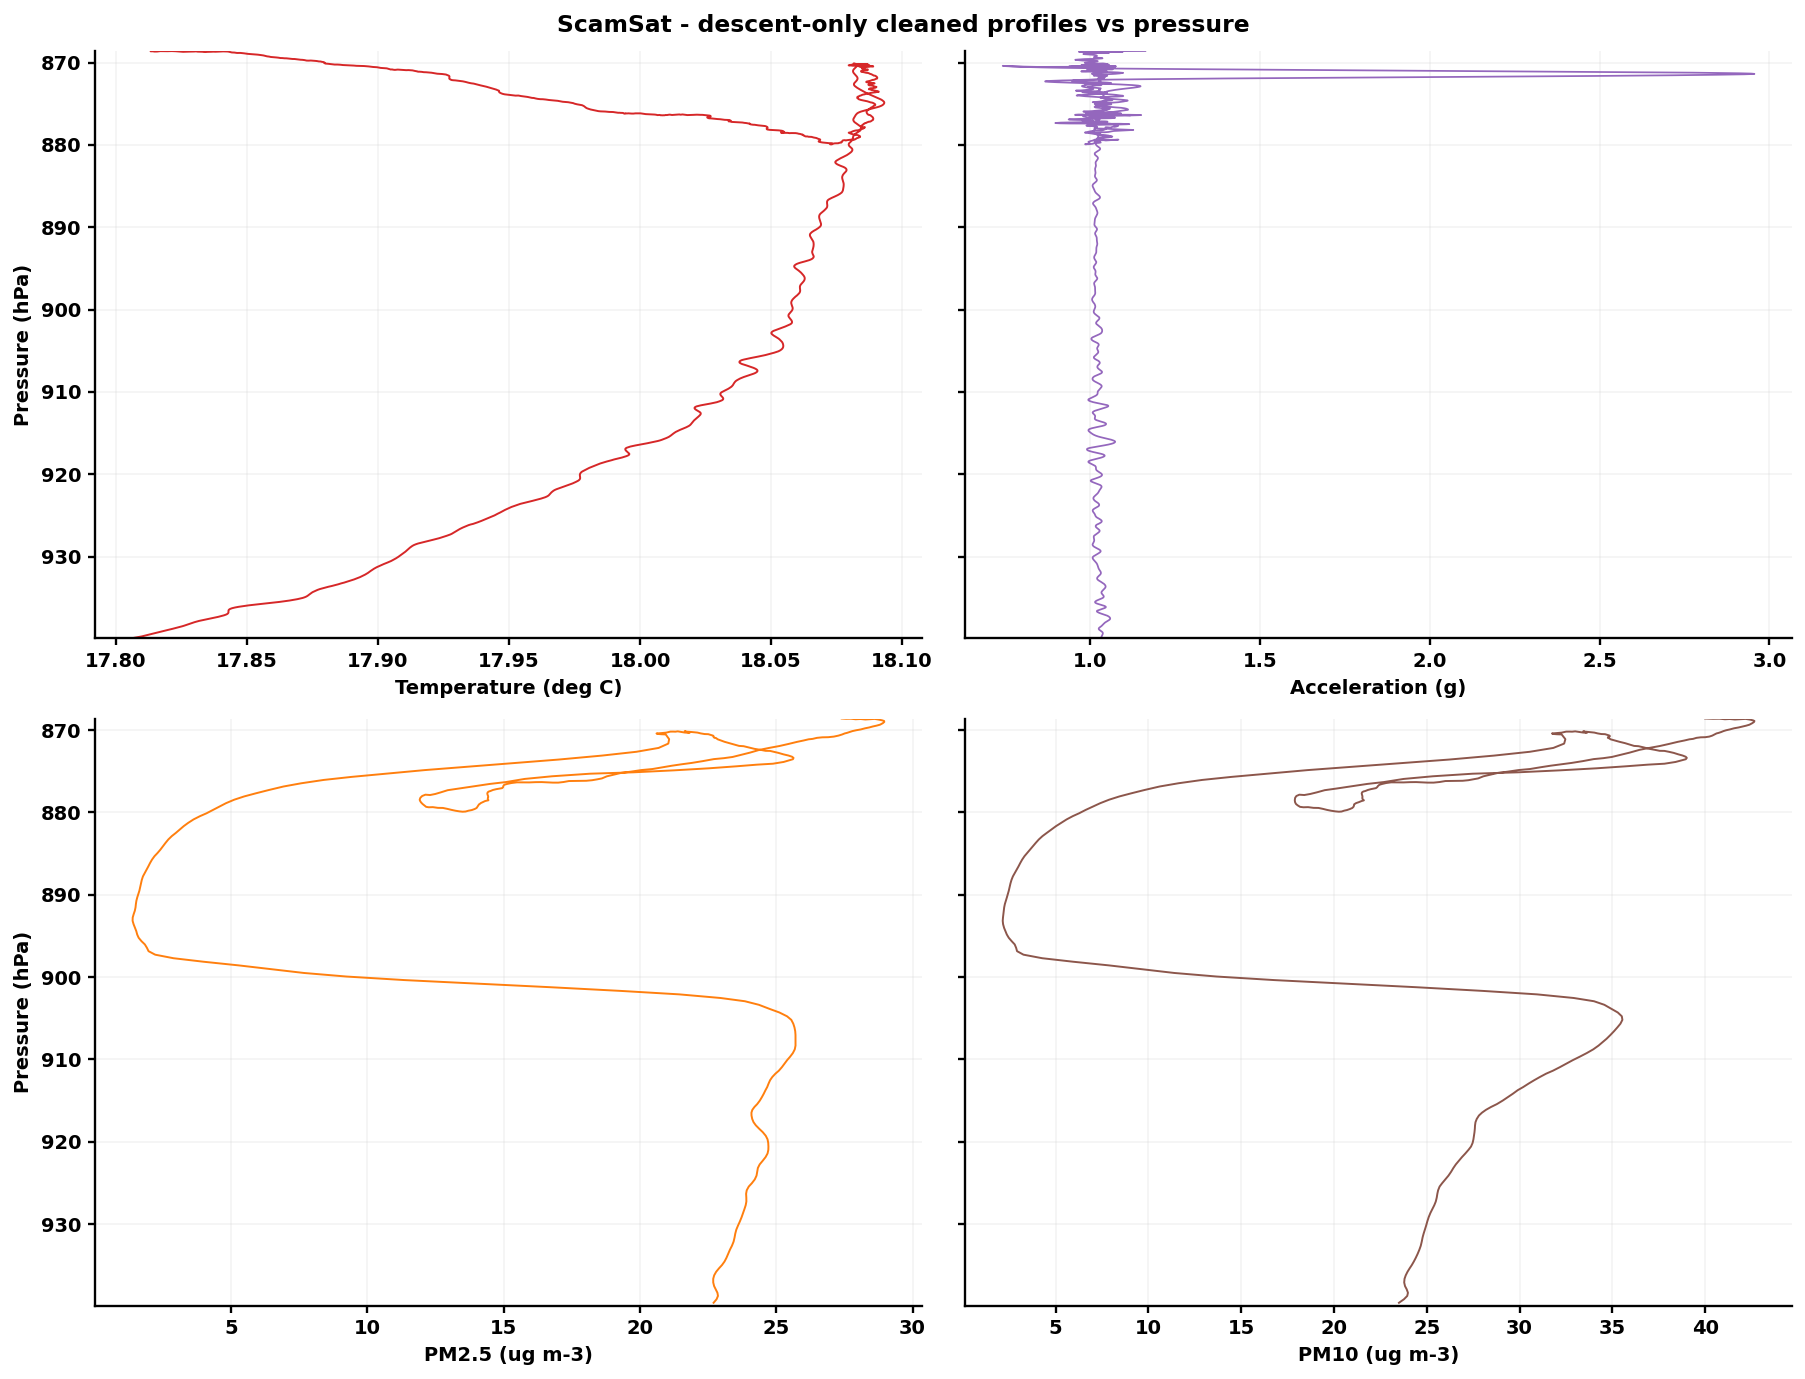

In [ ]:
# 6.3 ScamSat vs pressure
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)
fig.suptitle("ScamSat - descent-only cleaned profiles vs pressure", fontweight="bold")

axes[0, 0].plot(temp_s_clean, p_s_temp_hpa, color="tab:red", lw=1.0)
axes[0, 0].set(xlabel="Temperature (deg C)", ylabel="Pressure (hPa)")

axes[0, 1].plot(accel_s_clean, p_s_accel_hpa, color="tab:purple", lw=0.9)
axes[0, 1].set(xlabel="Acceleration (g)")

axes[1, 0].plot(pm25_clean, p_s_pm25_hpa, color="tab:orange", lw=1.0)
axes[1, 0].set(xlabel="PM2.5 (ug m-3)", ylabel="Pressure (hPa)")

axes[1, 1].plot(pm10_clean, p_s_pm10_hpa, color="tab:brown", lw=1.0)
axes[1, 1].set(xlabel="PM10 (ug m-3)")

# ← imposta limiti Y una volta sola (sharey propaga a tutti)
p_all = np.concatenate([p_s_temp_hpa, p_s_accel_hpa, p_s_pm25_hpa, p_s_pm10_hpa])
axes[0, 0].set_ylim(p_all.max(), p_all.min())

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, "signal_processing/final_scamsat_vs_pressure.png", strip_text=False)
plt.show()

### Short Discussion
- GRASP and OBAMA are intentionally excluded after the raw checks. GRASP is too short and trend-dominated for the requested spectral cleaning workflow; OBAMA has too few useful samples.

- VAMOS and ScamSat are reduced to descent-only windows before any spectral analysis. VAMOS resolves only the lower part of the pendulum band because its sampling rate is about 1 Hz. ScamSat acceleration is the main mechanical check because it samples much faster.

- Spectral candidates are treated conservatively. A small peak is discussed in the printed table, but it is not removed unless it is a clear narrow-band artefact and removing it improves the final profile. The slow VAMOS wind-direction component is kept as an interpretation caveat, because it can mix payload yaw with real wind shear. In this run the final profiles therefore use warm-up removal for CO2 plus low-pass smoothing for pressure-coordinate readability, without forcing a notch filter onto weak or ambiguous spectral features.

- The final scientific view is the pressure-coordinate profile: VAMOS contributes temperature, CO2 and wind; ScamSat contributes temperature, acceleration and particulate matter.


# 7. Comparison with external dataset


### 7.1. Atmospheric Conditions during the day (meteoswiss)

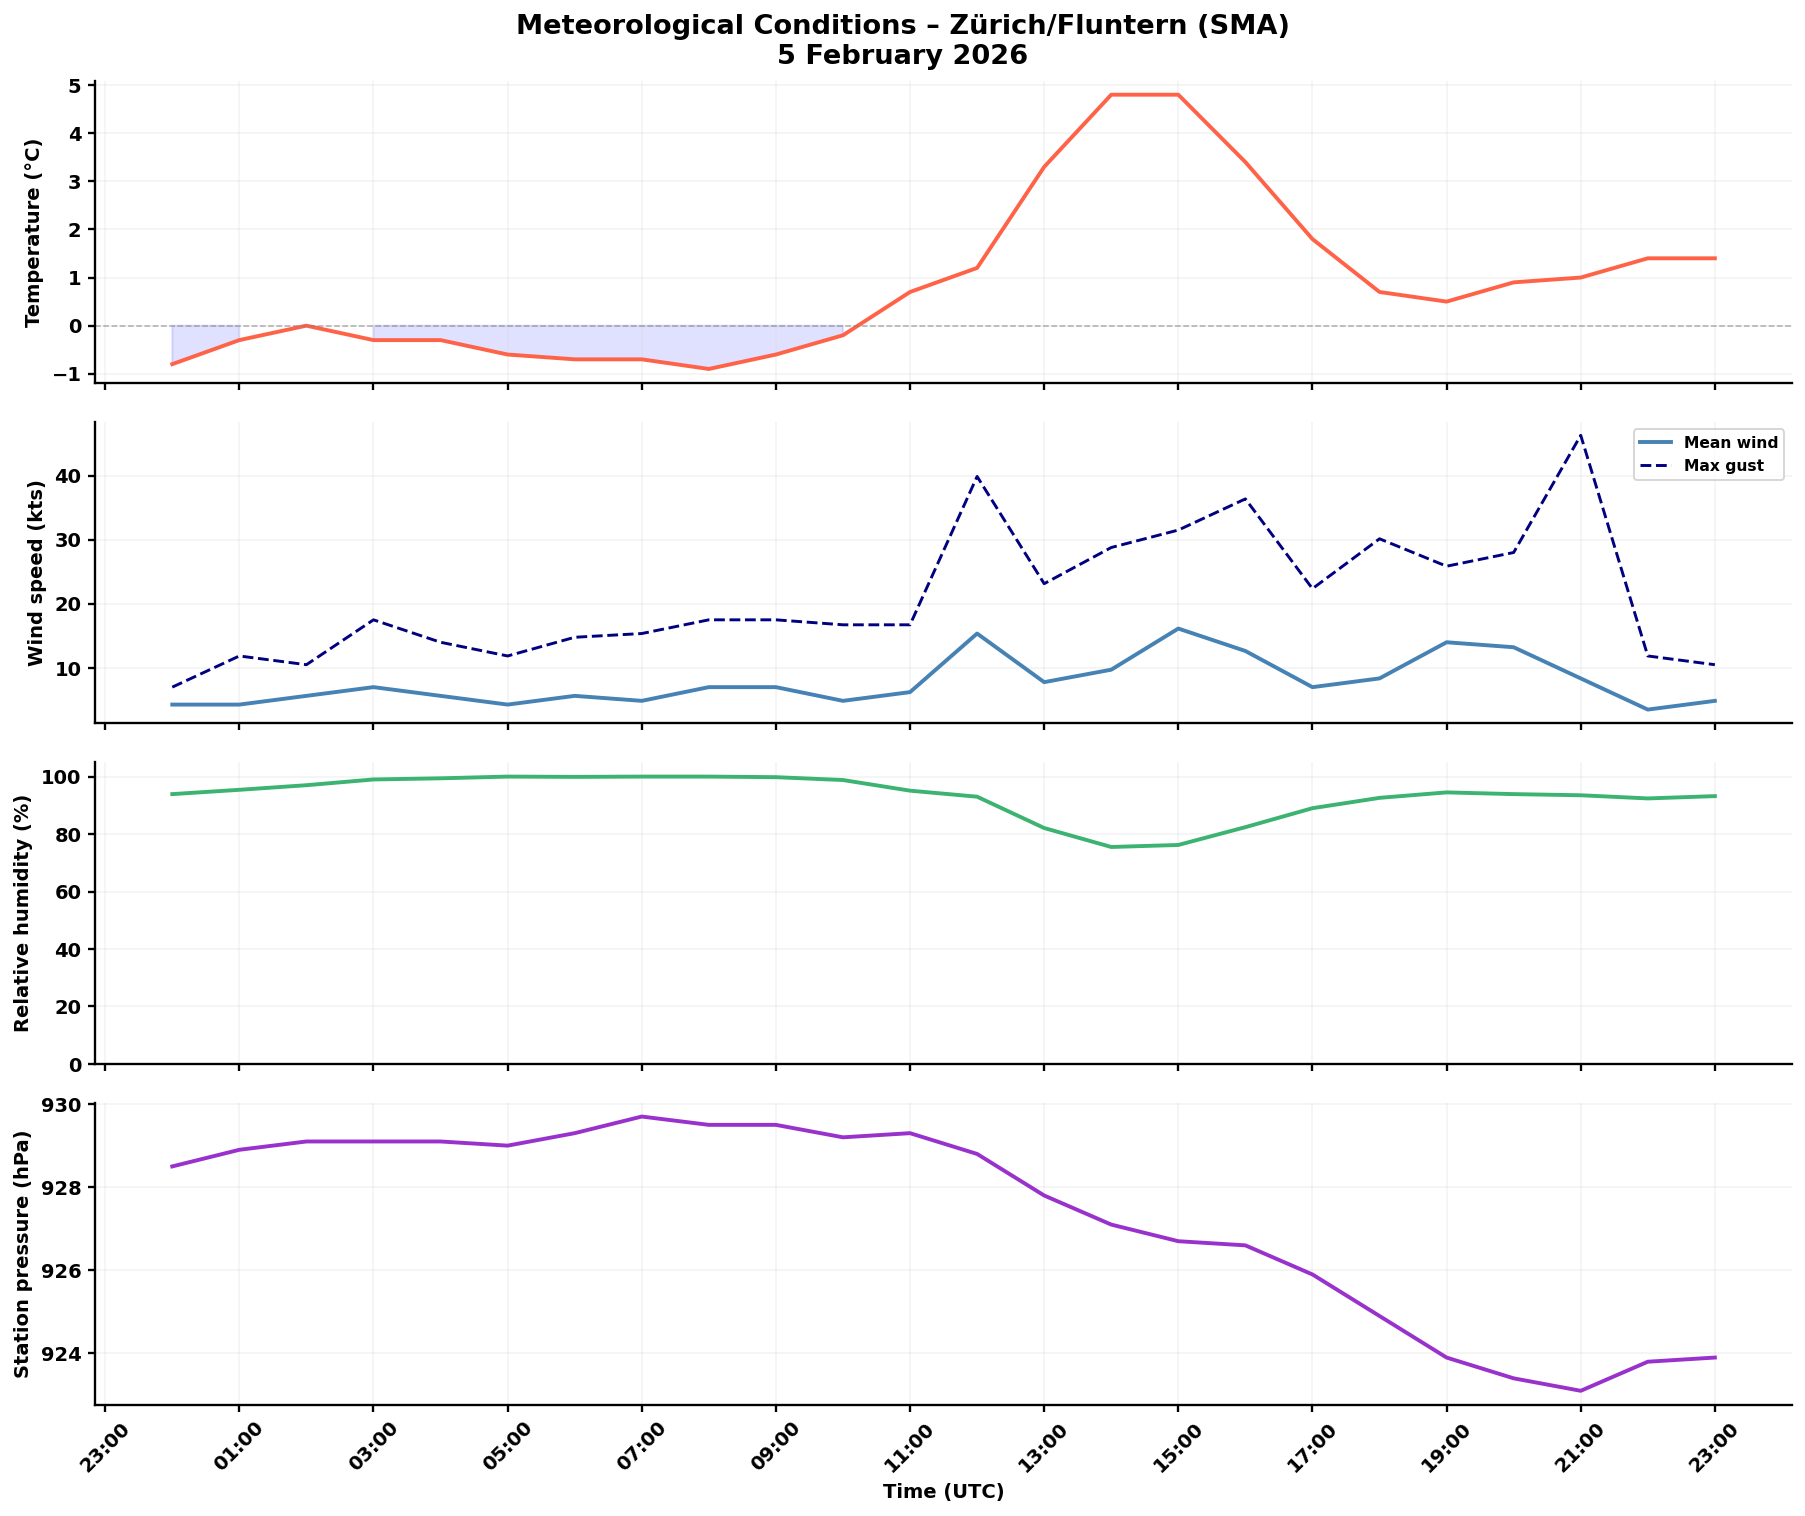

In [ ]:
# Atmospheric Conditions during the day – Zürich/Fluntern (SMA), 5 Feb 2026

METEO_PATH = Path("alice/Meteoswiss/ogd-smn_sma_h_recent.csv")

df_meteo = pd.read_csv(
    METEO_PATH,
    sep=";",
    parse_dates=["reference_timestamp"],
    dayfirst=True,
    low_memory=False,
)
df_meteo.columns = df_meteo.columns.str.strip()

day = df_meteo[
    df_meteo["reference_timestamp"].dt.date == pd.Timestamp("2026-02-05").date()
].copy()

for col in ["tre200h0", "ure200h0", "prestah0", "fu3010h0", "fu3010h1"]:
    day[col] = pd.to_numeric(day[col], errors="coerce")

day["wind_kts"] = day["fu3010h0"] * 1.944
day["gust_kts"] = day["fu3010h1"] * 1.944

t = day["reference_timestamp"]

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
fig.suptitle(
    "Meteorological Conditions – Zürich/Fluntern (SMA)\n5 February 2026",
    fontsize=14, fontweight="bold",
)

axes[0].plot(t, day["tre200h0"], color="tomato", linewidth=2)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(t, day["tre200h0"], 0, where=day["tre200h0"] < 0,
                     alpha=0.12, color="blue")

axes[1].plot(t, day["wind_kts"], color="steelblue", linewidth=2, label="Mean wind")
axes[1].plot(t, day["gust_kts"], color="navy", linewidth=1.5,
             linestyle="--", label="Max gust")
axes[1].set_ylabel("Wind speed (kts)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, day["ure200h0"], color="mediumseagreen", linewidth=2)
axes[2].set_ylabel("Relative humidity (%)")
axes[2].set_ylim(0, 105)
axes[2].grid(True, alpha=0.3)

axes[3].plot(t, day["prestah0"], color="darkorchid", linewidth=2)
axes[3].set_ylabel("Station pressure (hPa)")
axes[3].grid(True, alpha=0.3)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)
plt.xlabel("Time (UTC)")
plt.tight_layout()

save_figure(fig, "cross_dataset/meteo_5feb2026.png", strip_text=False)
plt.show()


### 7.2. Temperature Vertical Profile 

Payerne : 275 levels  (935.9–780.4 hPa)
ERA5    : 7 levels  (950–800 hPa)  [15:00 UTC]
MeteoSwiss SMA : T=1.2 °C  P=928.8 hPa
MeteoSwiss UEB : T=3.8 °C  P=890.5 hPa (estimated)
ScamSat : 14391 samples
VAMOS   : 196 samples


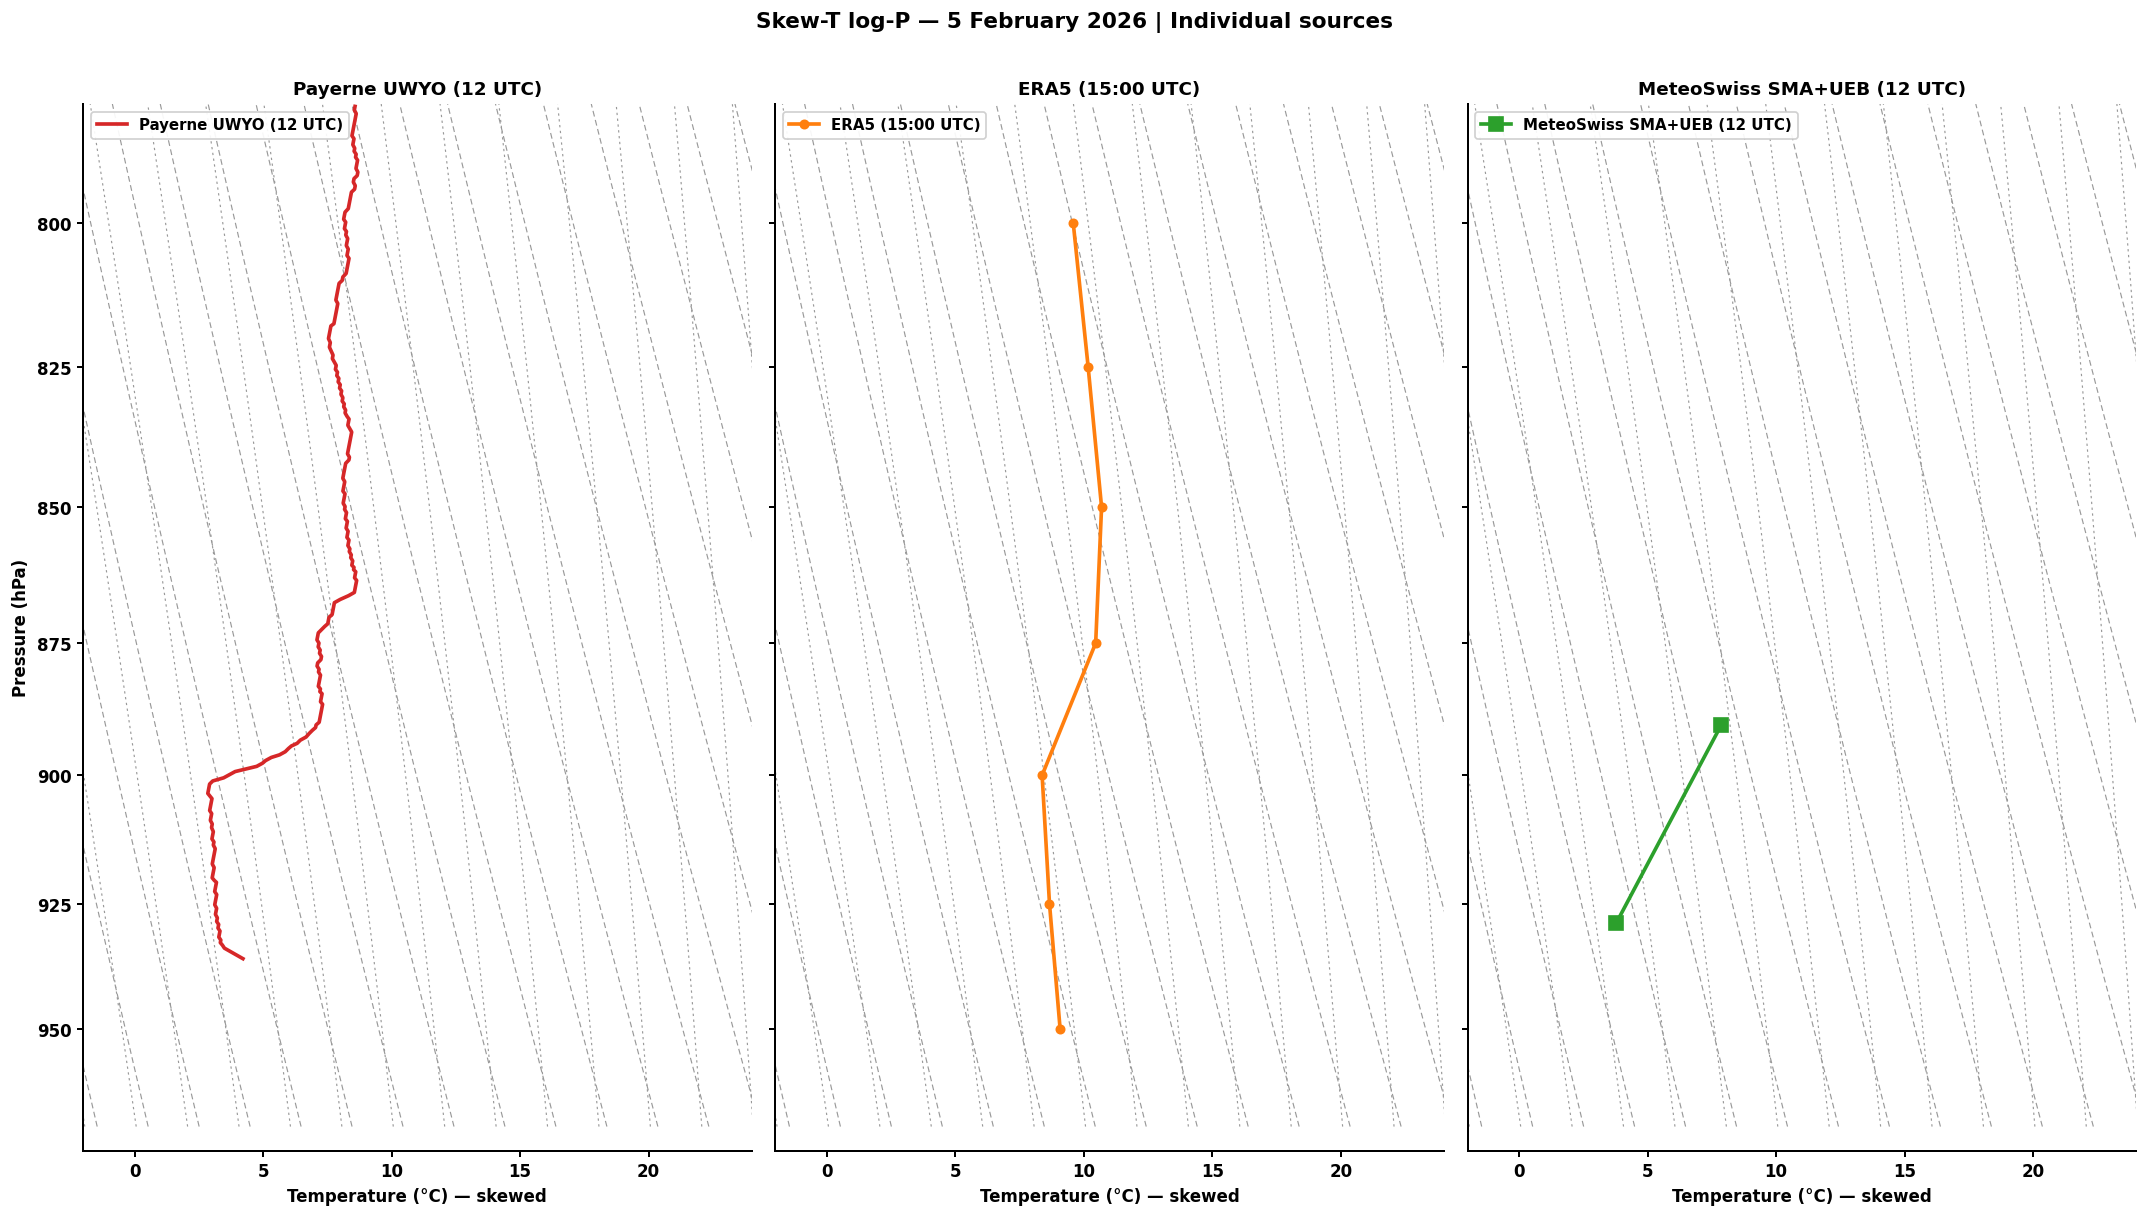

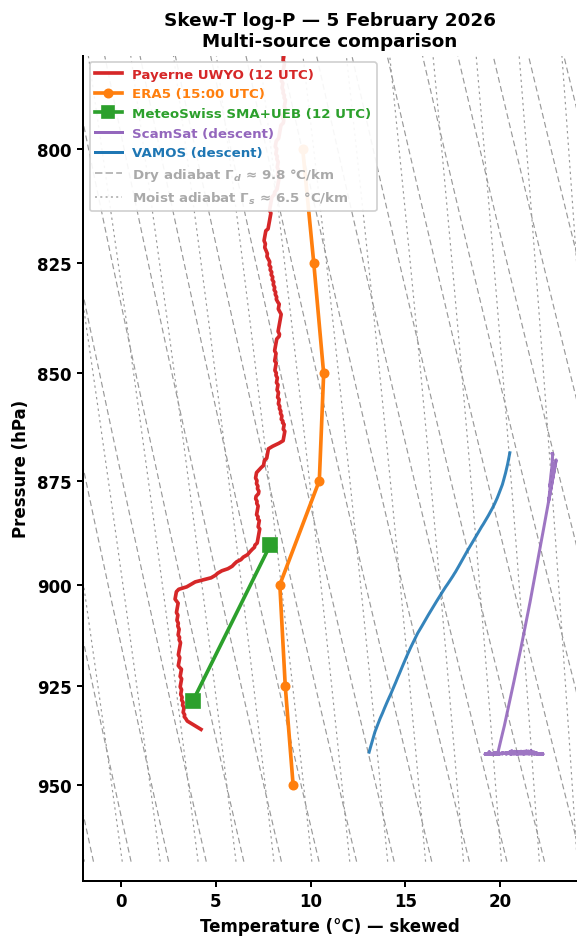

In [ ]:
ROOT_DIR = "/Users/alice/Desktop/Space_Data_2"
DATA_DIR = os.path.join(ROOT_DIR, "alice")

# ── Add root to sys.path and set working directory ────────────────────────────
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
os.chdir(ROOT_DIR)

import utils

# ── Input file paths ──────────────────────────────────────────────────────────
PAYERNE_CSV = os.path.join(DATA_DIR, "Payerne",    "uwyo_06610_2026-02-05_12Z.csv")
ERA5_NC     = os.path.join(DATA_DIR, "ERA5",        "era5_file.nc")
SMA_CSV     = os.path.join(DATA_DIR, "Meteoswiss",  "ogd-smn_sma_h_recent.csv")
UEB_CSV     = os.path.join(DATA_DIR, "Meteoswiss",  "ogd-smn-tower_ueb_h_recent.csv")

Z_SMA = 556.0   # m asl
Z_UEB = 896.0   # m asl

# ── Skew-T constants ──────────────────────────────────────────────────────────
SKEW    = 35.0
P_REF   = 1000.0
P_TOP   = 780.0
P_BOT   = 970.0
XLIM    = (-2.0, 24.0)
CP_D    = 1004.0
LV      = 2.5e6
EPSILON = 0.622
RV      = 461.5

plt.rcParams["figure.dpi"] = 120

# =============================================================================
# Skew-T helper functions
# =============================================================================

def sx(T, P):
    """Apply skew-T projection: T_plot = T + SKEW * ln(P_REF / P)"""
    return np.asarray(T, float) + SKEW * np.log(P_REF / np.asarray(P, float))

def dry_adiabat(theta_K, p_hpa):
    """Temperature (°C) along a dry adiabat with potential temperature theta_K."""
    return theta_K * (np.asarray(p_hpa, float) / P_REF) ** (utils.RD / CP_D) - 273.15

def sat_vapor_hpa(T_c):
    """Saturation vapour pressure (hPa) via Bolton formula."""
    tc = np.asarray(T_c, float)
    return 6.112 * np.exp(17.67 * tc / (tc + 243.5))

def moist_adiabat(T0_c, p_hpa):
    """Temperature (°C) along a moist adiabat starting at T0_c @ P_REF hPa."""
    p  = np.asarray(p_hpa, float)
    Tk = np.empty_like(p)
    Tk[0] = T0_c + 273.15
    for i in range(1, len(p)):
        pp    = p[i - 1]
        dp    = (p[i] - pp) * 100.0        # hPa → Pa
        e     = sat_vapor_hpa(Tk[i - 1] - 273.15)
        w     = EPSILON * e / max(pp - e, 1e-6)
        num   = utils.G * (1.0 + LV * w / (utils.RD * Tk[i - 1]))
        den   = CP_D + (LV**2 * w * EPSILON) / (RV * Tk[i - 1]**2)
        gamma = num / den
        vT    = Tk[i - 1] * (1.0 + 0.61 * w)
        Tk[i] = Tk[i - 1] + gamma * utils.RD * vT / (pp * 100.0 * utils.G) * dp
    return Tk - 273.15

def draw_skewt_background(ax, p_grid, p_moist):
    """Draw dry (dashed) and moist (dotted) adiabats as background lines."""
    for theta_K in np.arange(255, 355, 2):
        T_da = dry_adiabat(theta_K, p_grid)
        x_da = sx(T_da, p_grid)
        mask = (x_da >= XLIM[0] - 2) & (x_da <= XLIM[1] + 2)
        if mask.sum() > 2:
            ax.plot(x_da[mask], p_grid[mask],
                    color="#999999", lw=0.7, ls="--", dashes=(5, 3), zorder=1)
    for T0 in np.arange(-25, 45, 2):
        T_ma = moist_adiabat(T0, p_moist)
        x_ma = sx(T_ma, p_moist)
        mask = (x_ma >= XLIM[0] - 2) & (x_ma <= XLIM[1] + 2)
        if mask.sum() > 2:
            ax.plot(x_ma[mask], p_moist[mask],
                    color="#999999", lw=0.7, ls=":", dashes=(2, 3), zorder=1)

def format_skewt_ax(ax, title, show_ylabel=False):
    """Apply common axis formatting to a Skew-T panel."""
    ax.set_yscale("log")
    ax.set_ylim(P_BOT + 5, P_TOP)
    ax.set_xlim(*XLIM)
    std_levels = [p for p in [800, 825, 850, 875, 900, 925, 950]
                  if P_TOP <= p <= P_BOT]
    ax.yaxis.set_major_locator(ticker.FixedLocator(std_levels))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):d}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel("Temperature (°C) - skewed", fontsize=10)
    if show_ylabel:
        ax.set_ylabel("Pressure (hPa)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(False)
    ax.set_facecolor("white")

# =============================================================================
# 1. PAYERNE (UWYO radiosonde, 12 UTC)
# =============================================================================
df_pay = pd.read_csv(PAYERNE_CSV)
df_pay.columns = df_pay.columns.str.strip()
df_pay = df_pay.rename(columns={"pressure_hPa": "pres", "temperature_C": "temp"})
df_pay["pres"] = pd.to_numeric(df_pay["pres"], errors="coerce")
df_pay["temp"] = pd.to_numeric(df_pay["temp"], errors="coerce")
df_pay = df_pay.dropna(subset=["pres", "temp"])
df_pay = df_pay[(df_pay["pres"] >= P_TOP) & (df_pay["pres"] <= P_BOT)]
df_pay = df_pay.sort_values("pres", ascending=False).reset_index(drop=True)
print(f"Payerne : {len(df_pay)} levels  "
      f"({df_pay['pres'].max():.1f}–{df_pay['pres'].min():.1f} hPa)")

# =============================================================================
# 2. ERA5 (15 UTC)
# =============================================================================
ds          = xr.open_dataset(ERA5_NC)
time_coord  = "valid_time" if "valid_time" in ds.coords else "time"
target_time = np.datetime64("2026-02-05T15:00:00")
ds_t        = ds.sel({time_coord: target_time}, method="nearest")
selected_time = pd.to_datetime(ds_t[time_coord].values).strftime("%H:%M UTC")
ds_prof   = ds_t.where(
    (ds_t["pressure_level"] >= P_TOP) & (ds_t["pressure_level"] <= P_BOT), drop=True
)
era5_pres = ds_prof["pressure_level"].values.astype(float)
era5_temp = ds_prof["t"].mean(dim=("latitude", "longitude")).values - 273.15
order     = np.argsort(era5_pres)[::-1]
era5_pres, era5_temp = era5_pres[order], era5_temp[order]
print(f"ERA5    : {len(era5_pres)} levels  "
      f"({era5_pres.max():.0f}–{era5_pres.min():.0f} hPa)  [{selected_time}]")

# =============================================================================
# 3. METEOSWISS (SMA 2 m + UEB tower, 12 UTC)
# =============================================================================
sma = pd.read_csv(SMA_CSV, sep=";", parse_dates=["reference_timestamp"],
                  dayfirst=True, low_memory=False)
ueb = pd.read_csv(UEB_CSV, sep=";", parse_dates=["reference_timestamp"],
                  dayfirst=True, low_memory=False)
sma.columns = sma.columns.str.strip()
ueb.columns = ueb.columns.str.strip()
target_date = pd.Timestamp("2026-02-05").date()
sma_day = sma[sma["reference_timestamp"].dt.date == target_date].copy()
ueb_day = ueb[ueb["reference_timestamp"].dt.date == target_date].copy()
for col in ["tre200h0", "prestah0"]:
    sma_day[col] = pd.to_numeric(sma_day[col], errors="coerce")
ueb_day["ta1towh0"] = pd.to_numeric(ueb_day["ta1towh0"], errors="coerce")
sma_12 = sma_day[sma_day["reference_timestamp"].dt.hour == 12].dropna(
    subset=["tre200h0", "prestah0"])
ueb_12 = ueb_day[ueb_day["reference_timestamp"].dt.hour == 12].dropna(
    subset=["ta1towh0"])
meteo_pres = np.array([])
meteo_temp = np.array([])
if not sma_12.empty and not ueb_12.empty:
    t_sma    = float(sma_12["tre200h0"].iloc[0])
    p_sma    = float(sma_12["prestah0"].iloc[0])
    t_ueb    = float(ueb_12["ta1towh0"].iloc[0])
    T_mean_K = (t_sma + t_ueb) / 2.0 + 273.15
    p_ueb    = p_sma * np.exp(-utils.G * (Z_UEB - Z_SMA) / (utils.RD * T_mean_K))
    meteo_pres = np.array([p_sma, p_ueb])
    meteo_temp = np.array([t_sma, t_ueb])
    print(f"MeteoSwiss SMA : T={t_sma:.1f} °C  P={p_sma:.1f} hPa")
    print(f"MeteoSwiss UEB : T={t_ueb:.1f} °C  P={p_ueb:.1f} hPa (estimated)")
else:
    print("MeteoSwiss: no data at 12 UTC")

# =============================================================================
# 4. SCAMSAT (descent)
# =============================================================================
scamsat      = utils.load_scamsat_bundle()
p_sc_raw     = scamsat["pressure"]["press_Pa"].values / 100.0
t_sc_raw     = scamsat["temperature"]["temp_C"].values
t_sc_time    = scamsat["temperature"]["t_s"].values
p_sc_time    = scamsat["pressure"]["t_s"].values
t_sc_aligned = np.interp(p_sc_time, t_sc_time, t_sc_raw)
p_smooth     = pd.Series(p_sc_raw).rolling(100, center=True, min_periods=1).median().values
min_idx      = int(np.argmin(p_smooth))
p_sc_desc    = p_sc_raw[min_idx:]
t_sc_desc    = t_sc_aligned[min_idx:]
mask_sc      = (np.isfinite(p_sc_desc) & np.isfinite(t_sc_desc)
                & (p_sc_desc > P_TOP - 5) & (p_sc_desc < P_BOT))
p_sc_desc    = p_sc_desc[mask_sc]
t_sc_desc    = t_sc_desc[mask_sc]
if len(t_sc_desc) > 20:
    t_sc_desc = pd.Series(t_sc_desc).rolling(30, center=True, min_periods=1).mean().values
print(f"ScamSat : {len(p_sc_desc)} samples" if len(p_sc_desc) else "ScamSat: no data")

# =============================================================================
# 5. VAMOS (descent)
# =============================================================================
vamos      = utils.load_vamos_science()
vamos_drop = utils.detect_vamos_drop(vamos)
drop_mask  = vamos_drop["drop_mask"]
p_va       = vamos.loc[drop_mask, "press_hPa"].values
t_va       = vamos.loc[drop_mask, "temp_C"].values
mask_va    = np.isfinite(p_va) & np.isfinite(t_va)
p_va, t_va = p_va[mask_va], t_va[mask_va]
if len(t_va) > 20:
    t_va = pd.Series(t_va).rolling(30, center=True, min_periods=1).mean().values
print(f"VAMOS   : {len(p_va)} samples" if len(p_va) else "VAMOS: no data")

# ── Pressure grids (shared by both figures) ───────────────────────────────────
p_grid  = np.geomspace(P_BOT, P_TOP, 300)
p_moist = np.geomspace(P_BOT, P_TOP, 200)

# =============================================================================
# FIGURE 1 - Three individual Skew-T subplots (Payerne | ERA5 | MeteoSwiss)
# =============================================================================
fig1, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
fig1.patch.set_facecolor("white")

# --- Payerne ---
ax1 = axes[0]
draw_skewt_background(ax1, p_grid, p_moist)
ax1.plot(sx(df_pay["temp"], df_pay["pres"]), df_pay["pres"],
         color="#d62728", lw=2.2, zorder=5, label="Payerne UWYO (12 UTC)")
format_skewt_ax(ax1, "Payerne UWYO (12 UTC)", show_ylabel=True)
ax1.legend(fontsize=9, loc="upper left", framealpha=0.92)

# --- ERA5 ---
ax2 = axes[1]
draw_skewt_background(ax2, p_grid, p_moist)
ax2.plot(sx(era5_temp, era5_pres), era5_pres,
         color="#ff7f0e", lw=2.2, marker="o", markersize=5, zorder=4,
         label=f"ERA5 ({selected_time})")
format_skewt_ax(ax2, f"ERA5 ({selected_time})")
ax2.legend(fontsize=9, loc="upper left", framealpha=0.92)

# --- MeteoSwiss ---
ax3 = axes[2]
draw_skewt_background(ax3, p_grid, p_moist)
if len(meteo_pres):
    ax3.plot(sx(meteo_temp, meteo_pres), meteo_pres,
             color="#2ca02c", lw=2.2, marker="s", markersize=8, zorder=5,
             label="MeteoSwiss SMA+UEB (12 UTC)")
format_skewt_ax(ax3, "MeteoSwiss SMA+UEB (12 UTC)")
ax3.legend(fontsize=9, loc="upper left", framealpha=0.92)

fig1.suptitle("Skew-T log-P - 5 February 2026 | Individual sources",
              fontsize=13, fontweight="bold", y=1.01)
fig1.tight_layout()
utils.save_figure(fig1, "cross_dataset/skewt_individual.png", strip_text=False)
plt.show()

# =============================================================================
# FIGURE 2 - Full multi-source Skew-T (original layout)
# =============================================================================
fig2, ax = plt.subplots(figsize=(5, 8))
ax.set_facecolor("white")
fig2.patch.set_facecolor("white")

draw_skewt_background(ax, p_grid, p_moist)

ax.plot(sx(df_pay["temp"], df_pay["pres"]), df_pay["pres"],
        color="#d62728", lw=2.2, zorder=5)
ax.plot(sx(era5_temp, era5_pres), era5_pres,
        color="#ff7f0e", lw=2.2, marker="o", markersize=5, zorder=4)
if len(meteo_pres):
    ax.plot(sx(meteo_temp, meteo_pres), meteo_pres,
            color="#2ca02c", lw=2.2, marker="s", markersize=8, zorder=5)
if len(p_sc_desc):
    ax.plot(sx(t_sc_desc, p_sc_desc), p_sc_desc,
            color="#9467bd", lw=1.8, alpha=0.9, zorder=3)
if len(p_va):
    ax.plot(sx(t_va, p_va), p_va,
            color="#1f77b4", lw=1.8, alpha=0.9, zorder=3)

ax.set_yscale("log")
ax.set_ylim(P_BOT + 5, P_TOP)
ax.set_xlim(*XLIM)
std_levels = [p for p in [800, 825, 850, 875, 900, 925, 950] if P_TOP <= p <= P_BOT]
ax.yaxis.set_major_locator(ticker.FixedLocator(std_levels))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):d}"))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xlabel("Temperature (°C) - skewed", fontsize=10)
ax.set_ylabel("Pressure (hPa)", fontsize=10)
ax.set_title("Skew-T log-P - 5 February 2026\nMulti-source comparison",
             fontsize=11, fontweight="bold")
ax.grid(False)

legend_handles = [
    Line2D([0], [0], color="#d62728", lw=2.2, label="Payerne UWYO (12 UTC)"),
    Line2D([0], [0], color="#ff7f0e", lw=2.2, marker="o", markersize=5,
           label=f"ERA5 ({selected_time})"),
    Line2D([0], [0], color="#2ca02c", lw=2.2, marker="s", markersize=7,
           label="MeteoSwiss SMA+UEB (12 UTC)"),
    Line2D([0], [0], color="#9467bd", lw=1.8, label="ScamSat (descent)"),
    Line2D([0], [0], color="#1f77b4", lw=1.8, label="VAMOS (descent)"),
    Line2D([0], [0], color="#bbbbbb", lw=1.2, ls="--",
           label=r"Dry adiabat $\Gamma_d$ ≈ 9.8 °C/km"),
    Line2D([0], [0], color="#bbbbbb", lw=1.2, ls=":",
           label=r"Moist adiabat $\Gamma_s$ ≈ 6.5 °C/km"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper left",
          framealpha=0.92, edgecolor="#cccccc",
          labelcolor=["#d62728", "#ff7f0e", "#2ca02c", "#9467bd", "#1f77b4",
                      "#aaaaaa", "#aaaaaa"])
fig2.tight_layout()
utils.save_figure(fig2, "cross_dataset/skewt_comparison.png", strip_text=False)
plt.show()


### 7.3. PM and CO2 Vertical Profile 

PosixPath('figures/cross_dataset/co2_pm_who_comparison.png')

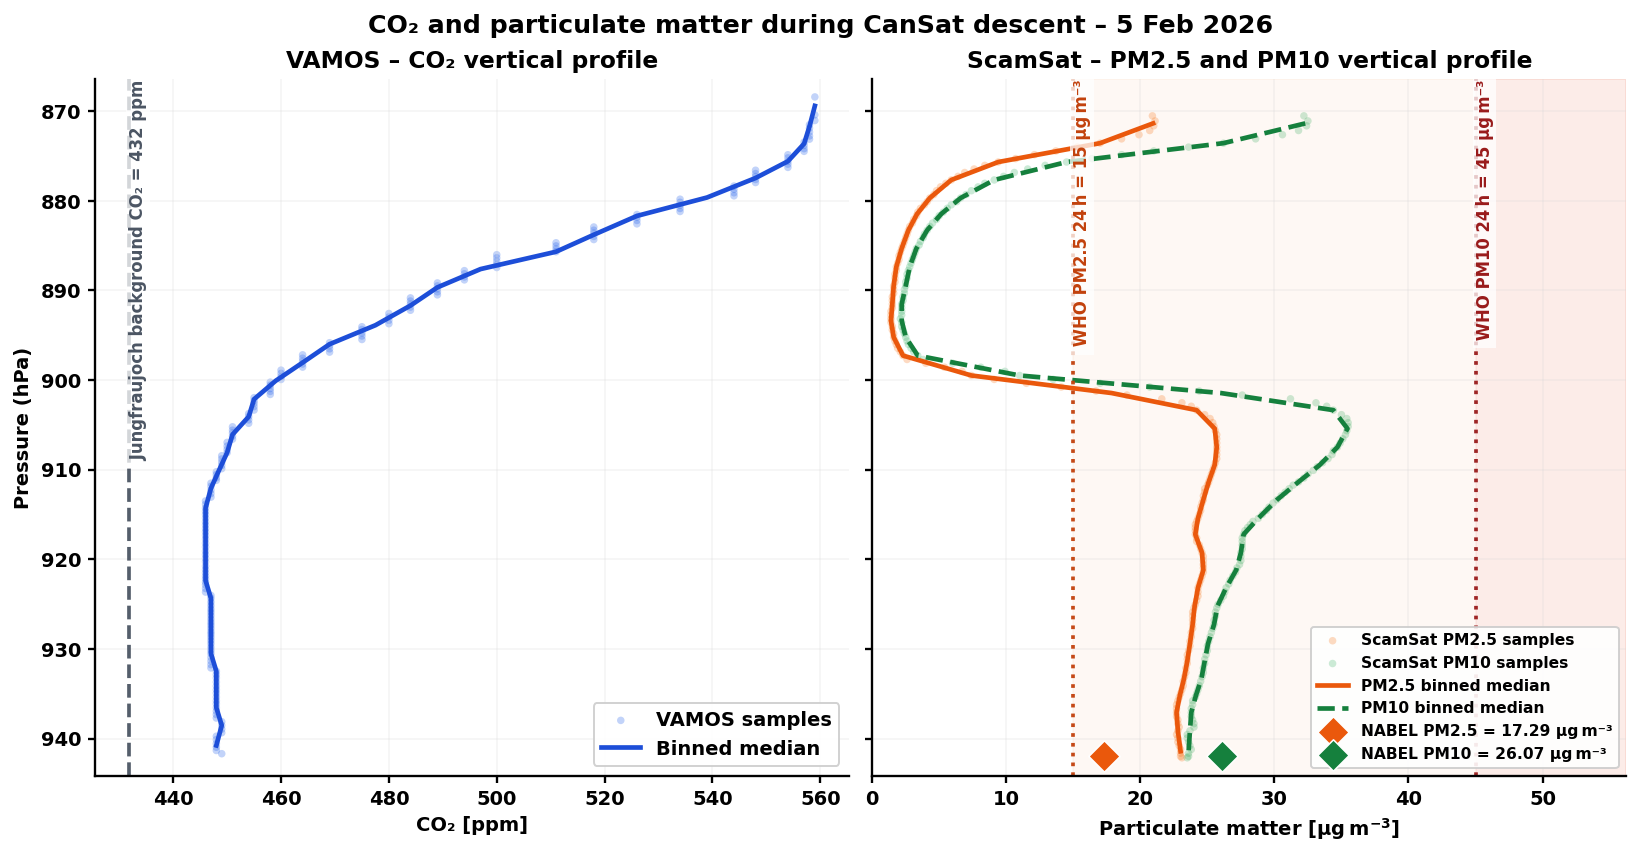

In [ ]:
# 3.3 CO2 and particulate matter vertical profiles

SCAMSAT_DROP_START_S = 828.0
SCAMSAT_DROP_END_S   = 996.0
NABEL_PM25           = 17.29   # µg m⁻³ – Zürich-Kaserne, 14:30 local
NABEL_PM10           = 26.07   # µg m⁻³


def _binned_median(data, value_col, y_col, *, n_bins=36):
    prof = data[[value_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if prof.empty:
        return prof
    y0, y1 = float(prof[y_col].min()), float(prof[y_col].max())
    if np.isclose(y0, y1):
        return prof.sort_values(y_col)
    bins = np.linspace(y0, y1, n_bins + 1)
    prof = prof.assign(_bin=pd.cut(prof[y_col], bins, include_lowest=True))
    return (
        prof.groupby("_bin", observed=True)
        .agg({value_col: "median", y_col: "median"})
        .dropna().reset_index(drop=True).sort_values(y_col)
    )


def _co2_profile():
    drop = detect_vamos_drop(vamos)
    co2 = vamos.loc[drop["drop_mask"], ["co2_ppm", "press_hPa"]].copy()
    co2 = co2.replace([np.inf, -np.inf], np.nan).dropna()
    return co2[co2["co2_ppm"] > 0].reset_index(drop=True)


def _pm_profile(key, value_col):
    frame = scamsat[key].copy()
    mask = frame["t_s"].between(SCAMSAT_DROP_START_S, SCAMSAT_DROP_END_S)
    pm = frame.loc[mask, [value_col, "t_s"]].copy()
    press_frame = scamsat["pressure"]
    pm["press_hPa"] = np.interp(
        pm["t_s"],
        press_frame["t_s"],
        press_frame["press_Pa"] / 100.0,
    )
    pm = pm.drop(columns="t_s").replace([np.inf, -np.inf], np.nan).dropna()
    return pm[pm[value_col] >= 0].reset_index(drop=True)


def _vref(ax, x, label, *, color, ls="--"):
    ax.axvline(x, color=color, linestyle=ls, linewidth=1.9, alpha=0.95)
    y_top = ax.get_ylim()[1]   # min pressure = top of inverted axis
    ax.text(x, y_top, f" {label}", rotation=90, va="top", ha="left",
            color=color, fontsize=8.5, fontweight="bold",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5})


# ── load ──────────────────────────────────────────────────────────────────────
co2  = _co2_profile()
pm25 = _pm_profile("pm25", "pm25")
pm10 = _pm_profile("pm10", "pm10")

co2_med  = _binned_median(co2,  "co2_ppm", "press_hPa")
pm25_med = _binned_median(pm25, "pm25",    "press_hPa")
pm10_med = _binned_median(pm10, "pm10",    "press_hPa")

all_press = pd.concat(
    [co2["press_hPa"], pm25["press_hPa"], pm10["press_hPa"]],
    ignore_index=True,
).dropna()
p_min   = float(all_press.min()) - 2.0
p_max   = float(all_press.max()) + 2.0
p_range = p_max - p_min

# ── plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (ax_co2, ax_pm) = plt.subplots(
    1, 2, figsize=(11.6, 6.0), sharey=True, constrained_layout=True
)

# inverted pressure axis: high pressure (ground) at bottom, low pressure at top
ax_co2.set_ylim(p_max, p_min)

ax_co2.scatter(co2["co2_ppm"], co2["press_hPa"],
               s=15, color="#2563eb", alpha=0.28, edgecolors="none", label="VAMOS samples")
ax_co2.plot(co2_med["co2_ppm"], co2_med["press_hPa"],
            color="#1d4ed8", linewidth=2.4, label="Binned median")
_vref(ax_co2, CO2_BACKGROUND_PPM,
      f"Jungfraujoch background CO₂ = {CO2_BACKGROUND_PPM:.0f} ppm", color="#4b5563")
ax_co2.set_xlabel("CO₂ [ppm]")
ax_co2.set_ylabel("Pressure (hPa)")
ax_co2.set_title("VAMOS – CO₂ vertical profile")
ax_co2.legend(loc="lower right", frameon=True, framealpha=0.9)

ax_pm.scatter(pm25["pm25"], pm25["press_hPa"],
              s=15, color="#f97316", alpha=0.26, edgecolors="none", label="ScamSat PM2.5 samples")
ax_pm.scatter(pm10["pm10"], pm10["press_hPa"],
              s=15, color="#16a34a", alpha=0.22, edgecolors="none", label="ScamSat PM10 samples")
ax_pm.plot(pm25_med["pm25"], pm25_med["press_hPa"],
           color="#ea580c", linewidth=2.4, label="PM2.5 binned median")
ax_pm.plot(pm10_med["pm10"], pm10_med["press_hPa"],
           color="#15803d", linewidth=2.4, linestyle="--", label="PM10 binned median")

pm_max = float(pd.concat([pm25["pm25"], pm10["pm10"]]).max())
ax_pm.set_xlim(left=0, right=max(pm_max * 1.12, WHO_PM10_24H * 1.25))
ax_pm.axvspan(WHO_PM25_24H, ax_pm.get_xlim()[1], color="#f97316", alpha=0.045)
ax_pm.axvspan(WHO_PM10_24H, ax_pm.get_xlim()[1], color="#dc2626", alpha=0.055)
_vref(ax_pm, WHO_PM25_24H, f"WHO PM2.5 24 h = {WHO_PM25_24H:g} μg m⁻³", color="#c2410c", ls=":")
_vref(ax_pm, WHO_PM10_24H, f"WHO PM10 24 h = {WHO_PM10_24H:g} μg m⁻³",  color="#991b1b", ls=":")

# NABEL ground reference at 942 hPa – Zürich-Kaserne, 14:30 local
NABEL_PRESS = 942.0

ax_pm.scatter([NABEL_PM25], [NABEL_PRESS], s=130, color="#ea580c", marker="D",
              zorder=6, edgecolors="white", linewidths=0.8,
              label=f"NABEL PM2.5 = {NABEL_PM25} μg m⁻³")
ax_pm.scatter([NABEL_PM10], [NABEL_PRESS], s=130, color="#15803d", marker="D",
              zorder=6, edgecolors="white", linewidths=0.8,
              label=f"NABEL PM10 = {NABEL_PM10} μg m⁻³")

ax_pm.set_xlabel("Particulate matter [μg m$^{-3}$]")
ax_pm.set_title("ScamSat – PM2.5 and PM10 vertical profile")
ax_pm.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=8)

fig.suptitle("CO₂ and particulate matter during CanSat descent – 5 Feb 2026",
             fontsize=13, fontweight="bold")
save_figure(fig, "cross_dataset/co2_pm_who_comparison.png", strip_text=False)


### 7.4. Wind speed and direction: compass rose and hodograpg


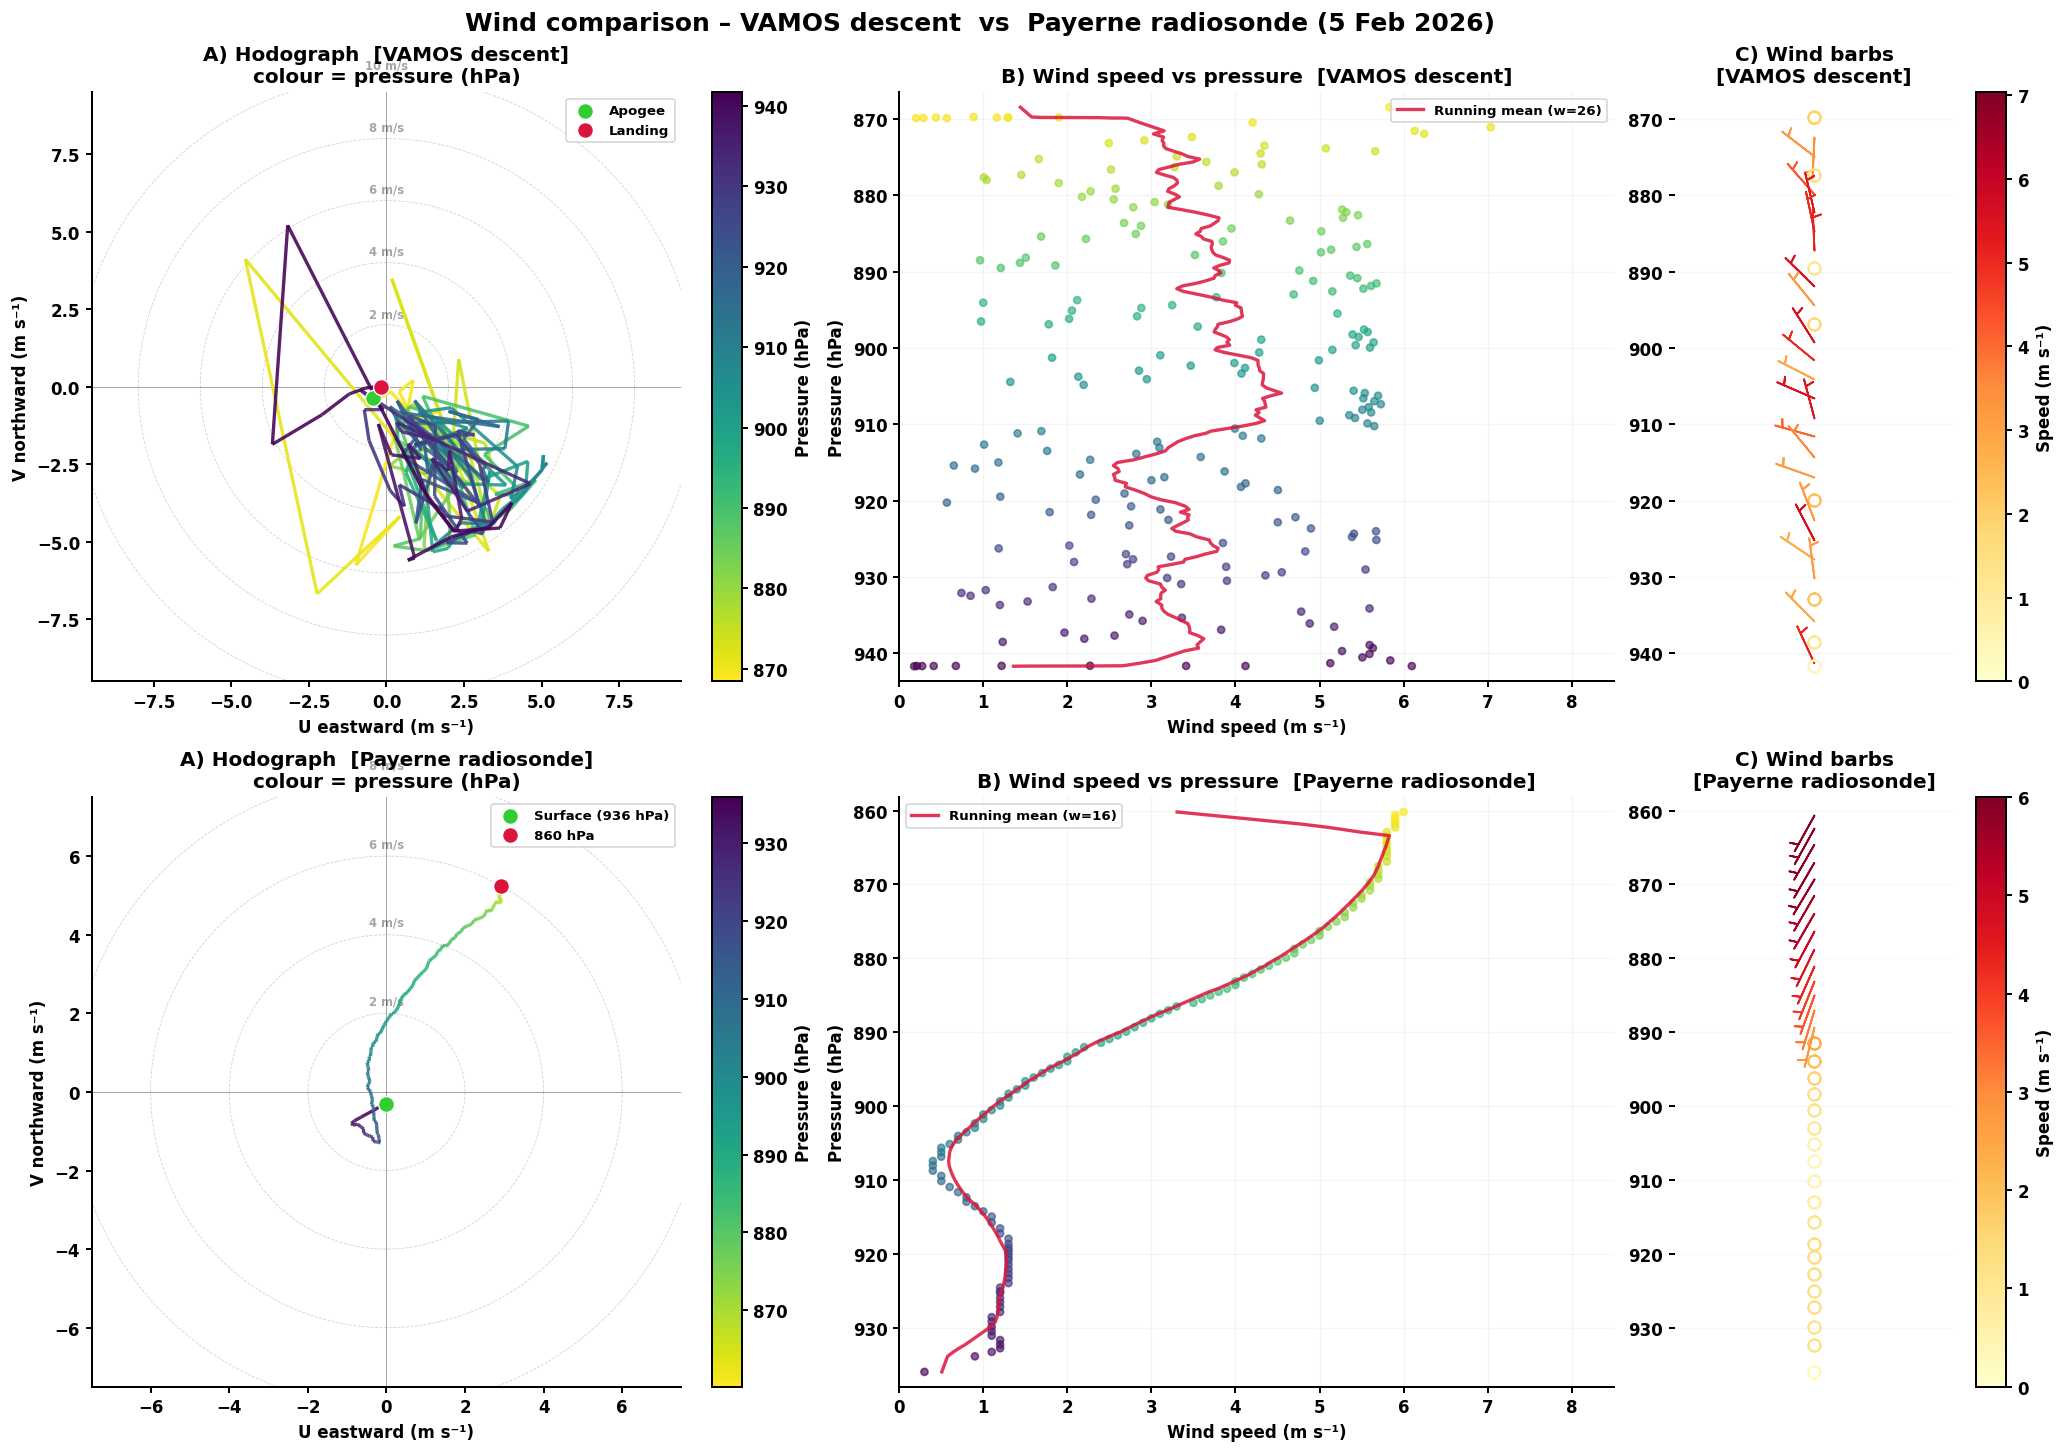


Dataset                              U(E)    V(N)    bearing   mean spd  max spd   P range
-----------------------------------------------------------------------------------------------
VAMOS (descent)                      U=+1.77  V=-2.50  bearing=324.7°  mean=3.45  max=7.04 m/s  P range=941.7–868.4 hPa
Payerne (sfc – 860 hPa)              U=+0.75  V=+1.81  bearing=202.5°  mean=2.73  max=6.00 m/s  P range=935.9–860.2 hPa


In [ ]:
PAYERNE_CSV = os.path.join(
    "/Users/alice/Desktop/Space_Data_2/alice/Payerne",
    "uwyo_06610_2026-02-05_12Z.csv"
)
P_MIN = 860.0   # hPa – upper pressure limit for Payerne

# ─────────────────────────────────────────────────────────────────────────────
# A) VAMOS – same extraction as section 6.2.2
#    pressure is interpolated from the science dataframe
# ─────────────────────────────────────────────────────────────────────────────
vamos_drop = utils.detect_vamos_drop(vamos)
t_apo, t_land = vamos_drop["t_apogee_s"], vamos_drop["t_landing_s"]
wind_raw = utils.load_vamos_wind()
wind_raw["wind_dir_unwrapped"], wind_raw["yaw_rate_deg_s"] = \
    utils.apparent_yaw_from_wind_direction(
        wind_raw["t_rel"].values, wind_raw["wind_dir"].values, smooth_window=5
    )

_drop_w  = wind_raw[wind_raw["t_s"].between(t_apo - 10, t_land + 10)].copy()

# interpolate pressure (hPa) from the science frame onto wind timestamps
Va_pres = np.interp(
    _drop_w["t_s"].values,
    vamos["t_s"].values,
    vamos["press_hPa"].values,
)

Va_u   = _drop_w["x_mps"].values
Va_v   = _drop_w["y_mps"].values
Va_spd = _drop_w["wind_spd_vec"].values

# ─────────────────────────────────────────────────────────────────────────────
# B) Payerne – radiosonde, surface → 860 hPa
# ─────────────────────────────────────────────────────────────────────────────
df_pay = pd.read_csv(PAYERNE_CSV)
df_pay.columns = df_pay.columns.str.strip()
df_pay = df_pay.rename(columns={
    "pressure_hPa":          "pres_hPa",
    "geopotential height_m": "height_m",
    "wind direction_degree": "wind_dir_deg",
    "wind speed_m/s":        "wind_spd_ms",
})
for col in ["pres_hPa", "height_m", "wind_dir_deg", "wind_spd_ms"]:
    df_pay[col] = pd.to_numeric(df_pay[col], errors="coerce")
df_pay = df_pay.dropna(subset=["pres_hPa", "wind_dir_deg", "wind_spd_ms"])
df_pay = df_pay[df_pay["pres_hPa"] >= P_MIN]
df_pay = df_pay.sort_values("pres_hPa", ascending=False).reset_index(drop=True)

_wdir_rad = np.deg2rad(df_pay["wind_dir_deg"].values)
Pa_spd  = df_pay["wind_spd_ms"].values
Pa_pres = df_pay["pres_hPa"].values
Pa_u    = -Pa_spd * np.sin(_wdir_rad)
Pa_v    = -Pa_spd * np.cos(_wdir_rad)

# ─────────────────────────────────────────────────────────────────────────────
# C) Shared speed axis limit
# ─────────────────────────────────────────────────────────────────────────────
spd_max_shared = float(np.ceil(max(Va_spd.max(), Pa_spd.max()))) + 0.5

# ─────────────────────────────────────────────────────────────────────────────
# D) Helper: build one row of panels  (Y = pressure, inverted)
# ─────────────────────────────────────────────────────────────────────────────
def _wind_row(axes, u, v, spd, pres, *,
              row_title, start_label, end_label, spd_xlim=None):

    ax_h, ax_spd, ax_barb = axes

    p_bot = pres.max()   # highest pressure = bottom of axis
    p_top = pres.min()   # lowest pressure  = top of axis

    # colour maps keyed on pressure (low p = bright = high altitude)
    norm_p  = mcolors.Normalize(vmin=p_top, vmax=p_bot)
    cmap_p  = cm.get_cmap("viridis_r")      # low pressure = bright yellow
    norm_sp = mcolors.Normalize(vmin=0, vmax=max(spd.max(), 1))
    cmap_sp = cm.get_cmap("YlOrRd")

    # ── Panel A: Hodograph ────────────────────────────────────────────────────
    ax_h.set_aspect("equal")
    points = np.column_stack([u, v]).reshape(-1, 1, 2)
    segs   = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap_p, norm=norm_p,
                        linewidth=2.0, alpha=0.88, zorder=3)
    lc.set_array(0.5 * (pres[:-1] + pres[1:]))
    ax_h.add_collection(lc)

    rmax = float(np.ceil(np.hypot(u, v).max() / 2) * 2) + 1.5
    for r in np.arange(2, rmax + 2, 2):
        theta = np.linspace(0, 2 * np.pi, 360)
        ax_h.plot(r * np.cos(theta), r * np.sin(theta),
                  color="gray", lw=0.5, ls="--", alpha=0.35, zorder=1)
        ax_h.text(0, r + 0.15, f"{r:.0f} m/s",
                  fontsize=7, color="gray", ha="center", va="bottom",
                  alpha=0.7, zorder=2)
    ax_h.axhline(0, color="k", lw=0.6, alpha=0.35)
    ax_h.axvline(0, color="k", lw=0.6, alpha=0.35)
    ax_h.scatter(u[0],  v[0],  s=90, color="limegreen", zorder=5,
                 edgecolors="white", linewidths=0.8, label=start_label)
    ax_h.scatter(u[-1], v[-1], s=90, color="crimson",   zorder=5,
                 edgecolors="white", linewidths=0.8, label=end_label)
    ax_h.set_xlim(-rmax, rmax); ax_h.set_ylim(-rmax, rmax)
    ax_h.set_xlabel("U eastward (m s⁻¹)")
    ax_h.set_ylabel("V northward (m s⁻¹)")
    ax_h.set_title(f"A) Hodograph  [{row_title}]\ncolour = pressure (hPa)",
                   fontweight="bold")
    ax_h.legend(fontsize=8, loc="upper right")
    ax_h.grid(False)
    sm_h = cm.ScalarMappable(cmap=cmap_p, norm=norm_p); sm_h.set_array([])
    cb_h = ax_h.get_figure().colorbar(sm_h, ax=ax_h, fraction=0.045, pad=0.04)
    cb_h.set_label("Pressure (hPa)")

    # ── Panel B: Speed vs pressure (Y inverted) ───────────────────────────────
    # sort by descending pressure (surface at bottom)
    idx = np.argsort(pres)[::-1]
    ps, ss = pres[idx], spd[idx]
    win = max(5, len(ps) // 8)
    sm_line = np.convolve(ss, np.ones(win) / win, mode="same")

    ax_spd.scatter(spd, pres, c=pres, cmap="viridis_r", s=18,
                   alpha=0.65, norm=norm_p, zorder=2)
    ax_spd.plot(sm_line, ps, color="crimson", lw=2.0, alpha=0.85,
                label=f"Running mean (w={win})", zorder=3)
    ax_spd.set_xlabel("Wind speed (m s⁻¹)")
    ax_spd.set_ylabel("Pressure (hPa)")
    ax_spd.set_ylim(p_bot + 2, p_top - 2)   # inverted: high P at bottom
    ax_spd.set_title(f"B) Wind speed vs pressure  [{row_title}]",
                     fontweight="bold")
    ax_spd.legend(fontsize=8)
    ax_spd.grid(True, alpha=0.25)
    if spd_xlim is not None:
        ax_spd.set_xlim(0, spd_xlim)

    # ── Panel C: Wind barbs (Y = pressure, inverted) ──────────────────────────
    N_BARB = max(1, len(pres) // 30)
    pb, ub, vb, spdb = pres[::N_BARB], u[::N_BARB], v[::N_BARB], spd[::N_BARB]
    for i in range(len(pb)):
        col = cmap_sp(norm_sp(spdb[i]))
        ax_barb.barbs(0, pb[i], ub[i], vb[i],
                      length=7, linewidth=1.1,
                      barbcolor=col, flagcolor=col, zorder=3)
    ax_barb.set_xlim(-1.5, 1.5)
    ax_barb.set_ylim(ax_spd.get_ylim())     # same inverted pressure axis
    ax_barb.set_title(f"C) Wind barbs\n[{row_title}]", fontweight="bold")
    ax_barb.set_xticks([]); ax_barb.set_xlabel(""); ax_barb.set_ylabel("")
    ax_barb.grid(True, axis="y", alpha=0.2)
    for s in ["top", "bottom", "left"]:
        ax_barb.spines[s].set_visible(False)
    sm_sb = cm.ScalarMappable(cmap=cmap_sp, norm=norm_sp); sm_sb.set_array([])
    cb_sb = ax_barb.get_figure().colorbar(sm_sb, ax=ax_barb,
                                          fraction=0.22, pad=0.08)
    cb_sb.set_label("Speed (m s⁻¹)")

# ─────────────────────────────────────────────────────────────────────────────
# E) Build the 2 × 3 figure
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 3, figsize=(18, 12),
    gridspec_kw={"width_ratios": [1.25, 1.15, 0.45]},
    constrained_layout=True,
)

# Row 0 – VAMOS
_wind_row(
    axes[0],
    Va_u, Va_v, Va_spd, Va_pres,
    row_title   = "VAMOS descent",
    start_label = "Apogee",
    end_label   = "Landing",
    spd_xlim    = spd_max_shared,
)

# Row 1 – Payerne
_wind_row(
    axes[1],
    Pa_u, Pa_v, Pa_spd, Pa_pres,
    row_title   = "Payerne radiosonde",
    start_label = f"Surface ({Pa_pres[0]:.0f} hPa)",
    end_label   = f"{P_MIN:.0f} hPa",
    spd_xlim    = spd_max_shared,
)

save_figure(fig, "flight_dynamics/wind_comparison_vamos_payerne.png",
            strip_text=False)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# F) Summary stats
# ─────────────────────────────────────────────────────────────────────────────
def _stats(u, v, spd, pres, name):
    bearing = np.rad2deg(np.arctan2(-u.mean(), -v.mean())) % 360
    print(f"{name:35s}  U={u.mean():+.2f}  V={v.mean():+.2f}  "
          f"bearing={bearing:.1f}°  mean={spd.mean():.2f}  "
          f"max={spd.max():.2f} m/s  "
          f"P range={pres.max():.1f}–{pres.min():.1f} hPa")

print(f"\n{'Dataset':35s}  U(E)    V(N)    bearing   mean spd  max spd   P range")
print("-" * 95)
_stats(Va_u, Va_v, Va_spd, Va_pres, "VAMOS (descent)")
_stats(Pa_u, Pa_v, Pa_spd, Pa_pres, f"Payerne (sfc – {P_MIN:.0f} hPa)")